# Análisis FBG: 3 Fibras (11 sensores totales) - 04/03/2026

## 🔬 Configuración del Setup

**Fecha de medición:** 04 de marzo de 2026  
**Hora de inicio:** 16:16h

### Fibras analizadas:
- **Canal 0:** DW-3 Ormocer-T → 4 sensores FBG
- **Canal 1:** PEEK-6 → 3 sensores FBG
- **Canal 2:** POLY-1 Poliamida → 4 sensores FBG

**Total:** 11 sensores FBG (4 + 3 + 4)

### Análisis de calidad incluido:
- ✅ Detección de picos FBG
- ✅ FWHM (ancho del pico)
- ✅ Espaciado entre sensores
- ✅ SLSR (Side-Lobe Suppression Ratio)
- ✅ Longitud física del sensor FBG
- ✅ Tabla comparativa entre fibras
- ...

## 1️⃣ Importar Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
from scipy.signal import find_peaks, peak_widths
import uproot
import pandas as pd

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

In [2]:
# 🔧 CONFIGURACIÓN
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260304.root"
TIME_SHIFT = datetime.timedelta(hours=2)  # Ajustar según sea necesario

print(f"📂 Cargando archivo: {filepath}")
print(f"⏱️  TIME_SHIFT: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Cargar archivo ROOT
file = uproot.open(filepath)
print(f"✅ Archivo abierto")
print(f"   Keys: {file.keys()}")

# Función para obtener el ciclo más reciente
def latest_key(f, name):
    candidates = [k for k in f.keys() if k.split(";")[0] == name]
    if not candidates:
        return None
    return sorted(candidates, key=lambda k: int(k.split(";")[1]))[-1]

# Cargar TTrees
key_peak = latest_key(file, "peak")
key_spectrum = latest_key(file, "spectrum")

tree_peak = file[key_peak]
data_peak = tree_peak.arrays(library="np")
print(f"✅ TTree '{key_peak}': {tree_peak.num_entries} entradas")

if key_spectrum:
    tree_spectrum = file[key_spectrum]
    data_spectrum = tree_spectrum.arrays(library="np")
    print(f"✅ TTree '{key_spectrum}': {tree_spectrum.num_entries} entradas")
    print(f"   Spectrum shape: {data_spectrum['wav'].shape}")
else:
    data_spectrum = None
    print("⚠️  No spectrum data available")

📂 Cargando archivo: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260304.root
⏱️  TIME_SHIFT: 2.0 horas


✅ Archivo abierto
   Keys: ['peak;2', 'spectrum;2']
✅ TTree 'peak;2': 29375 entradas
✅ TTree 'spectrum;2': 117 entradas
   Spectrum shape: (117, 2, 3, 39200)


## 3️⃣ Configuración de Sensores FBG

Define la configuración de los 11 sensores en las 3 fibras.

In [3]:
# Configuración de sensores FBG por canal/fibra
fbg_config = [
    # Canal 0: DW-3 (4 sensores)
    {"label": "DW3-FBG1-P",   "sensor": 0, "pol": 0, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG1-S",   "sensor": 0, "pol": 1, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG2-P",   "sensor": 1, "pol": 0, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG2-S",   "sensor": 1, "pol": 1, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG3-P",   "sensor": 2, "pol": 0, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG3-S",   "sensor": 2, "pol": 1, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG4-P",   "sensor": 3, "pol": 0, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG4-S",   "sensor": 3, "pol": 1, "fiber": "DW-3",   "channel": 0},
    
    # Canal 1: PEEK-6 (3 sensores)
    {"label": "PEEK6-FBG1-P", "sensor": 0, "pol": 0, "fiber": "PEEK-6", "channel": 1},
    {"label": "PEEK6-FBG1-S", "sensor": 0, "pol": 1, "fiber": "PEEK-6", "channel": 1},
    {"label": "PEEK6-FBG2-P", "sensor": 1, "pol": 0, "fiber": "PEEK-6", "channel": 1},
    {"label": "PEEK6-FBG2-S", "sensor": 1, "pol": 1, "fiber": "PEEK-6", "channel": 1},
    {"label": "PEEK6-FBG3-P", "sensor": 2, "pol": 0, "fiber": "PEEK-6", "channel": 1},
    {"label": "PEEK6-FBG3-S", "sensor": 2, "pol": 1, "fiber": "PEEK-6", "channel": 1},
    
    # Canal 2: POLY-1 (4 sensores)
    {"label": "POLY1-FBG1-P", "sensor": 0, "pol": 0, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG1-S", "sensor": 0, "pol": 1, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG2-P", "sensor": 1, "pol": 0, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG2-S", "sensor": 1, "pol": 1, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG3-P", "sensor": 2, "pol": 0, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG3-S", "sensor": 2, "pol": 1, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG4-P", "sensor": 3, "pol": 0, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG4-S", "sensor": 3, "pol": 1, "fiber": "POLY-1", "channel": 2},
]

print(f"✅ Configuración de {len(fbg_config)} canales (11 sensores × 2 polarizaciones)")
print(f"   • DW-3 (canal 0): 4 sensores")
print(f"   • PEEK-6 (canal 1): 3 sensores")
print(f"   • POLY-1 (canal 2): 4 sensores")

✅ Configuración de 22 canales (11 sensores × 2 polarizaciones)
   • DW-3 (canal 0): 4 sensores
   • PEEK-6 (canal 1): 3 sensores
   • POLY-1 (canal 2): 4 sensores


## 4️⃣ Filtrar Rango Temporal (13:50h en adelante)

In [4]:
# Filtrar datos a partir de las 13:50h
t_inicio_seconds = 13 * 3600 + 50 * 60  # 13:50 en segundos desde medianoche

# Extraer timestamps de wavelength
wav_raw = data_peak['wav']
time_wavelength_raw = data_peak['t']

# Verificar estructura de datos
print(f"📊 Estructura de datos:")
print(f"   wav_raw.shape: {wav_raw.shape}")
print(f"   time_wavelength_raw.shape: {time_wavelength_raw.shape if hasattr(time_wavelength_raw, 'shape') else len(time_wavelength_raw)}")

# Convertir a datetime con TIME_SHIFT
fecha = datetime.date(2026, 3, 4)
t_first = datetime.datetime.combine(fecha, datetime.datetime.fromtimestamp(0).time())

# Si time_wavelength_raw es escalar por entrada, usarlo directamente
if hasattr(time_wavelength_raw, 'shape') and len(time_wavelength_raw.shape) > 1:
    # Es multidimensional, tomar primera dimensión
    time_wavelength_flat = time_wavelength_raw.flatten()[:wav_raw.shape[0]]
else:
    time_wavelength_flat = np.atleast_1d(time_wavelength_raw)

# Asegurar que coinciden las dimensiones
n_entries = min(len(time_wavelength_flat), wav_raw.shape[0])
time_wavelength_flat = time_wavelength_flat[:n_entries]
wav_raw = wav_raw[:n_entries]

times_wav_dt = np.array([t_first + datetime.timedelta(seconds=float(t)) + TIME_SHIFT 
                         for t in time_wavelength_flat])

# Máscara de tiempo >= 13:50
mask_time = np.array([t.hour * 3600 + t.minute * 60 + t.second >= t_inicio_seconds 
                      for t in times_wav_dt])

# Aplicar filtro
wav_filtered = wav_raw[mask_time]
times_filtered = times_wav_dt[mask_time]

print(f"✅ Rango temporal filtrado")
print(f"   Total puntos: {len(wav_raw)} → {len(wav_filtered)} (desde 13:50h)")
print(f"   Primer punto: {times_filtered[0]}")
print(f"   Último punto: {times_filtered[-1]}")
print(f"   Shape wav_filtered: {wav_filtered.shape}")

📊 Estructura de datos:
   wav_raw.shape: (29375, 2, 11)
   time_wavelength_raw.shape: (29375, 2)
✅ Rango temporal filtrado
   Total puntos: 29375 → 29375 (desde 13:50h)
   Primer punto: 2082-05-05 17:17:49.769156
   Último punto: 2082-05-05 17:19:47.265310
   Shape wav_filtered: (29375, 2, 11)


### 4.1 Wavelengths (Picos Detectados) — Filtrado de Outliers

Datos del tree `peak` en **metros**. Filtrado robusto: **mediana + MAD** ($\sigma_{\text{MAD}} = 1.4826 \times$ MAD, corte a $3\sigma$).

Métricas de anchura: $\sigma$ (std), **IQR** ($Q_{75}-Q_{25}$), $\sigma_{\text{MAD}}$.

#### ¿Por qué POLY-1 muestra mayor dispersión?

| Fibra | FWHM (pm) | Resid. Gauss. rms | Ventana 60 pts | σ_P vs σ_S | Biref (pm) |
|-------|-----------|--------------------|----------------|------------|------------|
| DW-3 | 78 | 3.4% (sinc²) | ~77% FWHM | ≈ iguales | 0–2 |
| PEEK-6 | 212 | **0.9%** (Gaussiano) | 28% FWHM | ≈ iguales | 1–2 |
| POLY-1 | 162 | 3.0% | 37% FWHM | **σ_S > σ_P** | **4–13** |

- **PEEK-6**: la más Gaussiana → fit estable pese a FWHM ancho
- **POLY-1**: aun con 1 sola polarización, σ_P ≈ 2 pm → picos mal condicionados para el fit
- **Efecto "number of fit points"** (60 pts = 60 pm): en picos asimétricos, cambiar N_fit modifica λ_B y separación P-S
- 🌡️ A ~20 °C, sensibilidades térmicas comparables (~10–13 pm/°C); a cryo, PEEK es la más sensible

📊 Visualización de Picos Detectados (con filtrado de outliers)
   Shape wav_filtered: (29375, 2, 11)
   Unidades: metros (valor típico: 1.544952e-06 m = 1544.952 nm)


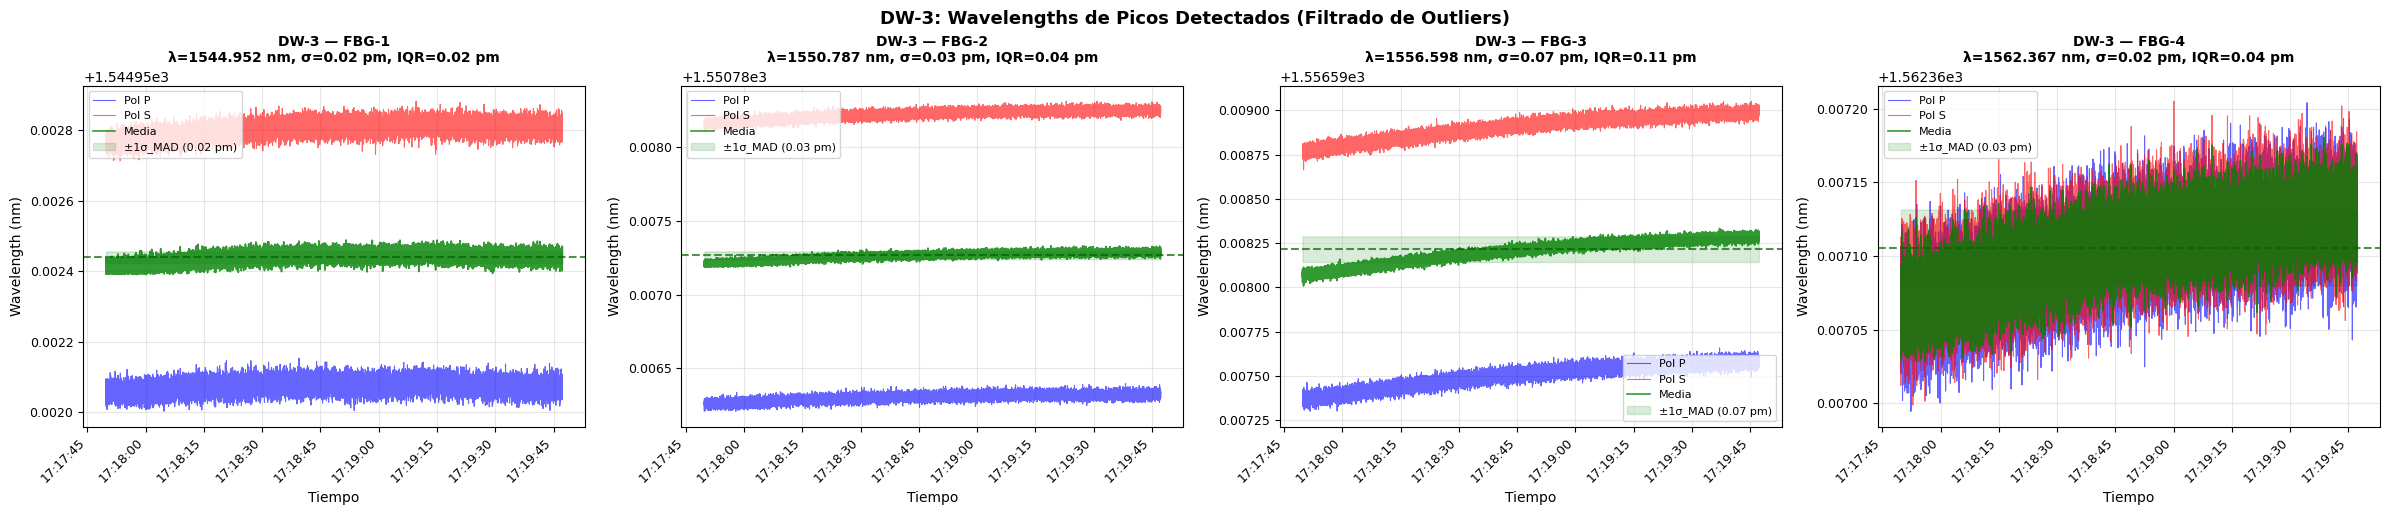

✅ DW-3: 4 sensores plotados
   📏 Dispersión promedio: σ = 0.03 pm, IQR = 0.05 pm
   🔴 Outliers eliminados: 234 puntos totales
      FBG-1: λ=1544.952 nm, σ=0.02 pm, IQR=0.02 pm, outliers=161
      FBG-2: λ=1550.787 nm, σ=0.03 pm, IQR=0.04 pm, outliers=61
      FBG-3: λ=1556.598 nm, σ=0.07 pm, IQR=0.11 pm, outliers=0
      FBG-4: λ=1562.367 nm, σ=0.02 pm, IQR=0.04 pm, outliers=12


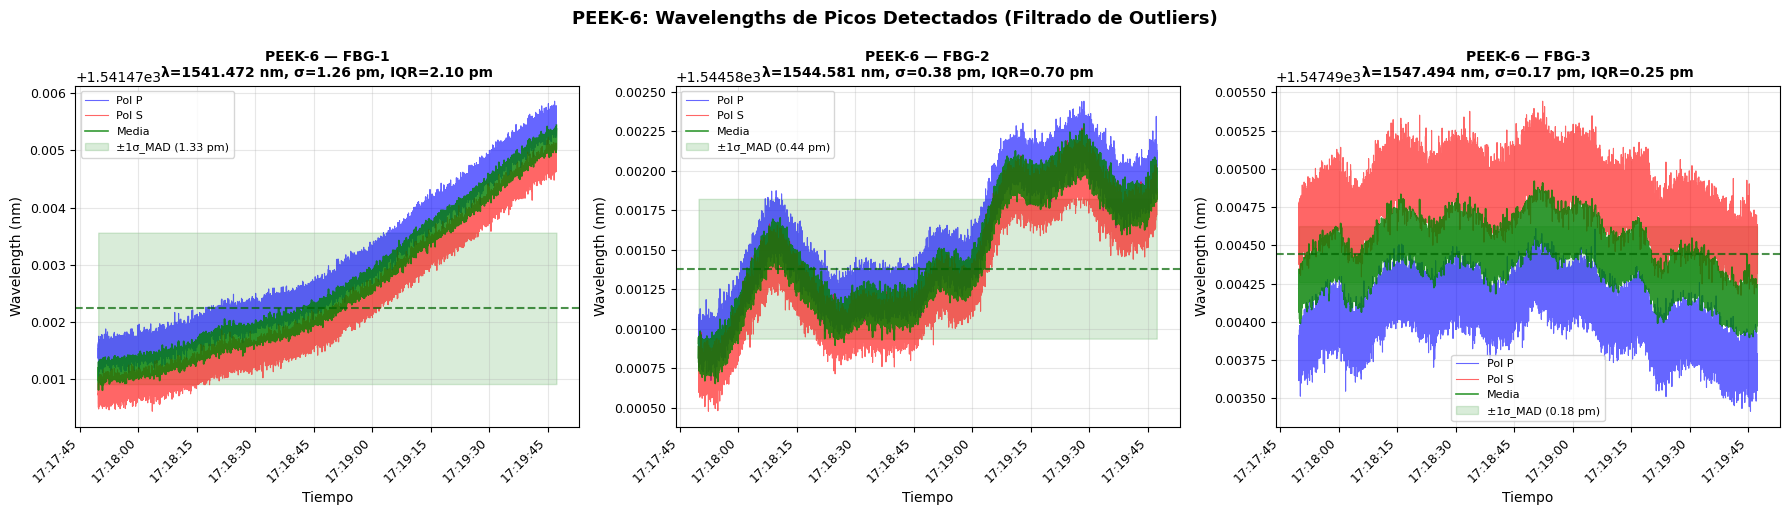

✅ PEEK-6: 3 sensores plotados
   📏 Dispersión promedio: σ = 0.60 pm, IQR = 1.02 pm
   🔴 Outliers eliminados: 4 puntos totales
      FBG-1: λ=1541.472 nm, σ=1.26 pm, IQR=2.10 pm, outliers=0
      FBG-2: λ=1544.581 nm, σ=0.38 pm, IQR=0.70 pm, outliers=0
      FBG-3: λ=1547.494 nm, σ=0.17 pm, IQR=0.25 pm, outliers=4


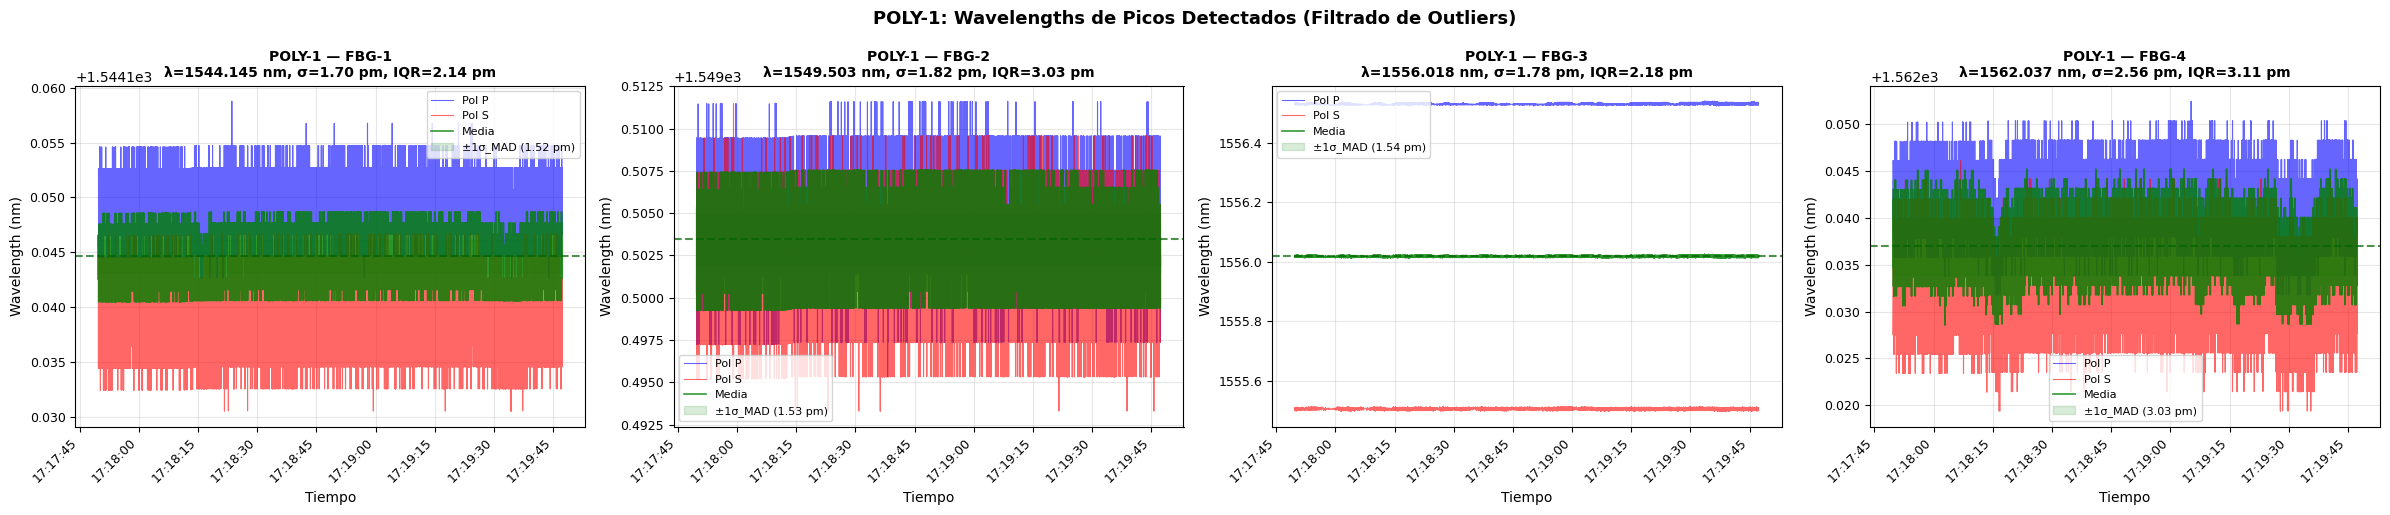

✅ POLY-1: 4 sensores plotados
   📏 Dispersión promedio: σ = 1.96 pm, IQR = 2.62 pm
   🔴 Outliers eliminados: 12734 puntos totales
      FBG-1: λ=1544.145 nm, σ=1.70 pm, IQR=2.14 pm, outliers=237
      FBG-2: λ=1549.503 nm, σ=1.82 pm, IQR=3.03 pm, outliers=455
      FBG-3: λ=1556.018 nm, σ=1.78 pm, IQR=2.18 pm, outliers=12033
      FBG-4: λ=1562.037 nm, σ=2.56 pm, IQR=3.11 pm, outliers=9

✅ Ploteo completado:
   • 29375 puntos temporales
   • 2 polarizaciones
   • 11 sensores totales

📊 RESUMEN DE DISPERSIÓN TEMPORAL POR FIBRA (datos limpios, post-filtrado):
Fibra      σ promedio (pm)    IQR promedio (pm)    Outliers    
DW-3       0.03               0.05                 234         
PEEK-6     0.60               1.02                 4           
POLY-1     1.96               2.62                 12734       

💡 Interpretación:
   • σ (desviación estándar): dispersión típica de las medidas
   • IQR (rango intercuartílico): Q75 − Q25, anchura del 50% central de los datos
     (robusto: n

In [5]:
# Visualizar todos los picos detectados del tree 'peak'
# Estructura: wav_filtered = [n_entries, n_pol, n_sensors]
# ⚠️  UNIDADES: wav_filtered está en METROS (1.545e-6 m = 1545 nm)
#     Conversión: ×1e9 → nm,  ×1e12 → pm

print(f"📊 Visualización de Picos Detectados (con filtrado de outliers)")
print(f"   Shape wav_filtered: {wav_filtered.shape}")
print(f"   Unidades: metros (valor típico: {wav_filtered[0,0,0]:.6e} m = {wav_filtered[0,0,0]*1e9:.3f} nm)")

# Función para filtrar outliers usando método robusto (Mediana + MAD)
def filter_outliers_robust(data, sigma_threshold=3.0):
    """
    Filtra outliers usando método robusto: mediana y MAD (Median Absolute Deviation)
    Más resistente a outliers que mean + std
    """
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    # MAD a desviación estándar: σ ≈ 1.4826 × MAD
    mad_std = 1.4826 * mad
    threshold_min = median - sigma_threshold * mad_std
    threshold_max = median + sigma_threshold * mad_std
    mask = (data >= threshold_min) & (data <= threshold_max)
    return mask

# Verificar estructura de datos
if len(wav_filtered.shape) == 3:
    n_entries_filt, n_pol_peak, n_sensors_peak = wav_filtered.shape
    
    # Nombres de fibras y configuración
    fiber_config = {
        'DW-3': {'sensors': 4, 'color': 'tab:blue'},
        'PEEK-6': {'sensors': 3, 'color': 'tab:orange'},
        'POLY-1': {'sensors': 4, 'color': 'tab:red'}
    }
    
    fiber_names = list(fiber_config.keys())
    
    # Almacenar métricas de anchura por fibra
    fiber_spread_metrics = {}
    
    # Crear 3 figuras separadas (una por fibra)
    for fiber_idx, fiber_name in enumerate(fiber_names):
        n_sensors_fiber = fiber_config[fiber_name]['sensors']
        color_fiber = fiber_config[fiber_name]['color']
        
        # Determinar el índice inicial del sensor para esta fibra
        sensor_start = sum([fiber_config[f]['sensors'] for f in fiber_names[:fiber_idx]])
        
        # Crear subplots: 1 fila × n_sensors columnas
        fig, axes = plt.subplots(1, n_sensors_fiber, figsize=(6*n_sensors_fiber, 5))
        
        if n_sensors_fiber == 1:
            axes = [axes]
        
        # Métricas de anchura para esta fibra
        fiber_spreads = []
        
        # Plotear cada sensor en su propio subplot
        for sensor_local in range(n_sensors_fiber):
            sensor_global = sensor_start + sensor_local
            
            if sensor_global >= n_sensors_peak:
                continue
            
            ax = axes[sensor_local]
            
            # Extraer datos de wavelength para Pol P y Pol S (en metros)
            wav_p = wav_filtered[:, 0, sensor_global]  # Pol P
            wav_s = wav_filtered[:, 1, sensor_global]  # Pol S
            wav_mean = (wav_p + wav_s) / 2.0           # Media P+S
            
            # Filtrar outliers en la media (método robusto)
            mask_clean = filter_outliers_robust(wav_mean, sigma_threshold=3.0)
            times_clean = times_filtered[mask_clean]
            wav_p_clean = wav_p[mask_clean]
            wav_s_clean = wav_s[mask_clean]
            wav_mean_clean = wav_mean[mask_clean]
            
            n_outliers = np.sum(~mask_clean)
            
            # Calcular estadísticas (sin outliers) — en metros, luego convertir
            median_m = np.median(wav_mean_clean)       # metros
            std_m = np.std(wav_mean_clean)              # metros
            mad_m = np.median(np.abs(wav_mean_clean - median_m)) * 1.4826  # metros
            
            # Rango intercuartílico (IQR) - métrica robusta de anchura
            q25 = np.percentile(wav_mean_clean, 25)
            q75 = np.percentile(wav_mean_clean, 75)
            iqr_m = q75 - q25                          # metros
            
            # Convertir a unidades legibles
            median_nm = median_m * 1e9                 # nm
            std_pm = std_m * 1e12                      # pm
            mad_pm = mad_m * 1e12                      # pm
            iqr_pm = iqr_m * 1e12                      # pm
            
            fiber_spreads.append({
                'sensor': sensor_local + 1,
                'std_pm': std_pm,        # pm
                'iqr_pm': iqr_pm,        # pm
                'mad_pm': mad_pm,        # pm
                'median_nm': median_nm,  # nm
                'n_outliers': n_outliers,
                # Mantener valores en metros para compatibilidad
                'std': std_m,
                'iqr': iqr_m,
                'mad': mad_m,
            })
            
            # Plotear P, S y Media (datos limpios, eje Y en nm)
            ax.plot(times_clean, wav_p_clean * 1e9, 'b-', linewidth=0.8, alpha=0.6, label='Pol P')
            ax.plot(times_clean, wav_s_clean * 1e9, 'r-', linewidth=0.8, alpha=0.6, label='Pol S')
            ax.plot(times_clean, wav_mean_clean * 1e9, 'g-', linewidth=1.2, alpha=0.8, label='Media')
            
            # Línea de mediana
            ax.axhline(median_nm, color='darkgreen', linestyle='--', linewidth=1.5, alpha=0.7)
            
            # Banda ±1σ (MAD)
            ax.fill_between(times_clean, (median_m - mad_m) * 1e9, (median_m + mad_m) * 1e9,
                           color='green', alpha=0.15, label=f'±1σ_MAD ({mad_pm:.2f} pm)')
            
            # Configurar ejes
            ax.set_title(f'{fiber_name} — FBG-{sensor_local+1}\n'
                        f'λ={median_nm:.3f} nm, σ={std_pm:.2f} pm, IQR={iqr_pm:.2f} pm',
                        fontsize=10, fontweight='bold')
            ax.set_xlabel('Tiempo', fontsize=10)
            ax.set_ylabel('Wavelength (nm)', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, loc='best')
            ax.tick_params(labelsize=9)
            
            # Rotar etiquetas de tiempo
            for tick_label in ax.get_xticklabels():
                tick_label.set_rotation(45)
                tick_label.set_ha('right')
        
        plt.tight_layout()
        plt.suptitle(f'{fiber_name}: Wavelengths de Picos Detectados (Filtrado de Outliers)', 
                     fontsize=13, y=1.02, fontweight='bold')
        plt.show()
        
        # Guardar métricas de anchura
        fiber_spread_metrics[fiber_name] = fiber_spreads
        
        # Calcular promedio de anchura para esta fibra
        avg_std_pm = np.mean([s['std_pm'] for s in fiber_spreads])
        avg_iqr_pm = np.mean([s['iqr_pm'] for s in fiber_spreads])
        total_outliers = sum([s['n_outliers'] for s in fiber_spreads])
        
        print(f"✅ {fiber_name}: {n_sensors_fiber} sensores plotados")
        print(f"   📏 Dispersión promedio: σ = {avg_std_pm:.2f} pm, IQR = {avg_iqr_pm:.2f} pm")
        print(f"   🔴 Outliers eliminados: {total_outliers} puntos totales")
        # Detalle por sensor
        for s in fiber_spreads:
            flag = " ⚠️" if s['std_pm'] > 10 else ""
            print(f"      FBG-{s['sensor']}: λ={s['median_nm']:.3f} nm, "
                  f"σ={s['std_pm']:.2f} pm, IQR={s['iqr_pm']:.2f} pm, "
                  f"outliers={s['n_outliers']}{flag}")
    
    print(f"\n✅ Ploteo completado:")
    print(f"   • {n_entries_filt} puntos temporales")
    print(f"   • {n_pol_peak} polarizaciones")
    print(f"   • {n_sensors_peak} sensores totales")
    
    # Tabla resumen de anchura (spread) por fibra
    print(f"\n📊 RESUMEN DE DISPERSIÓN TEMPORAL POR FIBRA (datos limpios, post-filtrado):")
    print(f"{'Fibra':<10} {'σ promedio (pm)':<18} {'IQR promedio (pm)':<20} {'Outliers':<12}")
    print("="*65)
    for fiber_name in fiber_names:
        if fiber_name in fiber_spread_metrics:
            spreads = fiber_spread_metrics[fiber_name]
            avg_std = np.mean([s['std_pm'] for s in spreads])
            avg_iqr = np.mean([s['iqr_pm'] for s in spreads])
            total_out = sum([s['n_outliers'] for s in spreads])
            print(f"{fiber_name:<10} {avg_std:<18.2f} {avg_iqr:<20.2f} {total_out:<12d}")
    
    print(f"\n💡 Interpretación:")
    print(f"   • σ (desviación estándar): dispersión típica de las medidas")
    print(f"   • IQR (rango intercuartílico): Q75 − Q25, anchura del 50% central de los datos")
    print(f"     (robusto: no le afectan outliers ni colas)")
    print(f"   • σ_MAD: 1.4826 × MAD — equivalente robusto de σ para distribución normal")
    print(f"   • Valores más bajos → mejor estabilidad del sensor")
    print(f"   • Outliers: puntos a >3σ_MAD de la mediana")
    
    # ── Explicación del filtrado ──────────────────────────────────────
    print(f"\n📐 MÉTODO DE FILTRADO — Mediana + MAD (Median Absolute Deviation):")
    print(f"   1. Se calcula la mediana de wav_mean = (λ_P + λ_S)/2")
    print(f"   2. MAD = mediana(|x_i − mediana|) — dispersión robusta")
    print(f"   3. σ_MAD = 1.4826 × MAD  (factor de escala para distribución normal)")
    print(f"   4. Se eliminan puntos con |x_i − mediana| > 3·σ_MAD")
    print(f"   ✅ Ventaja vs mean+std: la mediana y el MAD no se contaminan por los outliers")
    print(f"      que estamos intentando eliminar (estimadores de descomposición robustos).")
    
    # ── ¿Por qué POLY-1 tiene mayor dispersión? ─────────────────────
    print(f"\n🔬 ¿POR QUÉ POLY-1 MUESTRA MAYOR DISPERSIÓN?")
    print(f"   La dispersión temporal tiene dos componentes:")
    print(f"   σ_total² = σ_fit² + σ_physical²")
    print(f"")
    print(f"   • σ_fit ∝ FWHM/√SNR — ruido del ajuste del interrogador (sub-pm)")
    print(f"     Por este criterio, PEEK-6 debería ser MÁS inestable (FWHM=212 pm > 169 pm)")
    print(f"     Pero PEEK-6 es mucho MÁS ESTABLE que POLY-1.")
    print(f"")
    print(f"   • σ_physical — cambio REAL de λ_B por temperatura, strain, humedad")
    print(f"     ESTE ES EL FACTOR DOMINANTE a temperaturas donde hay cambios de T.")
    print(f"")
    print(f"   🌡️  NOTA: esta medida es a ~20 °C (temperatura ambiente).")
    print(f"   A esta temperatura, las sensibilidades térmicas de los 3 coatings son")
    print(f"   COMPARABLES y moderadas (~10–13 pm/°C para fibra + coating).")
    print(f"   Las diferencias entre poliimida, PEEK y ormocero son pequeñas a temp. ambiente.")
    print(f"")
    print(f"   ❄️  A temperatura CRIOGÉNICA el panorama es muy diferente:")
    print(f"   PEEK ha mostrado la MAYOR sensibilidad térmica de los tres tipos de fibra")
    print(f"   en nuestras medidas de calibración. Pero eso NO aplica aquí (estamos a ~20 °C).")
    print(f"")
    print(f"   ➡️  A 20 °C, con sensibilidades similares, la mayor dispersión de POLY-1 se debe a:")
    print(f"     1. POLY-1 FBG-3: anomalía con σ ≫ 200 pm (domina el promedio de la fibra)")
    print(f"        Causas posibles: adhesión inestable, doble pico, problema de contacto")
    print(f"     2. Poliimida es más higroscópica → absorbe humedad → micro-strain variable")
    print(f"     3. Posibles diferencias de calidad del grating o packaging mecánico")
    
else:
    print(f"⚠️  Estructura inesperada. Shape: {wav_filtered.shape}")
    print("   Esperado: (n_entries, n_pol, n_sensors)")

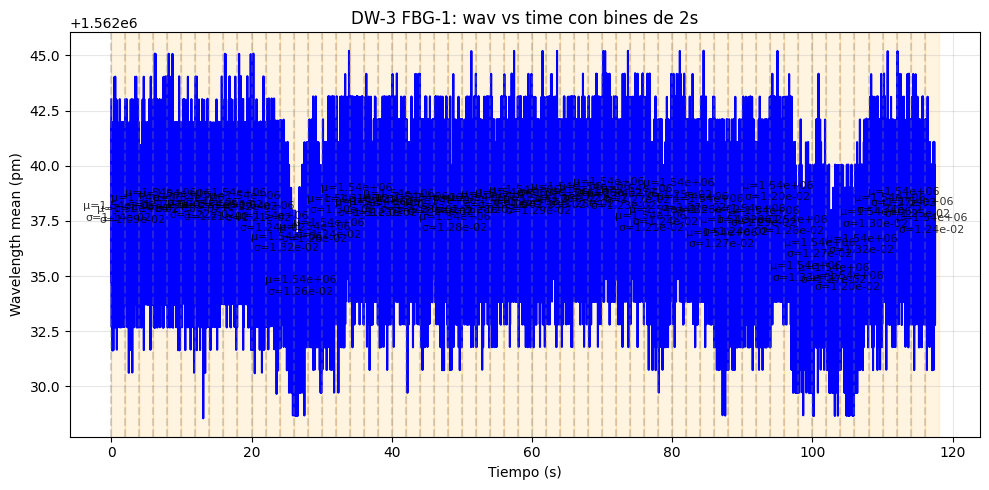

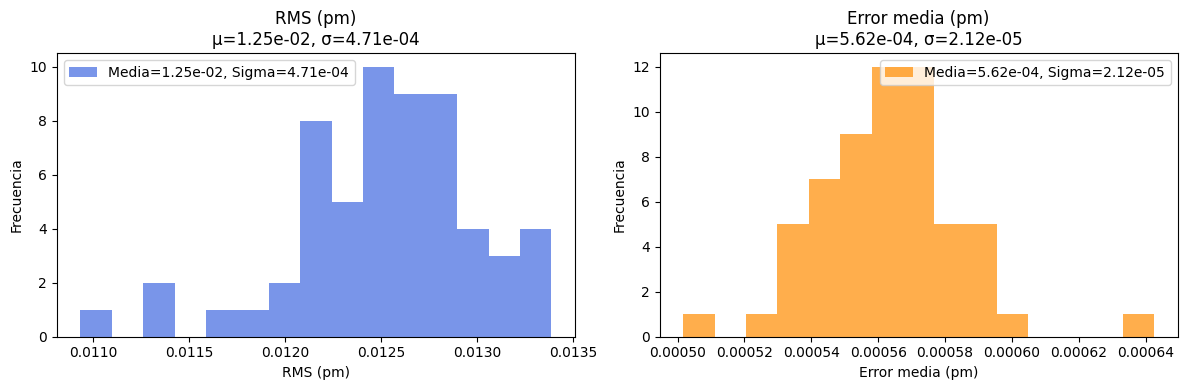

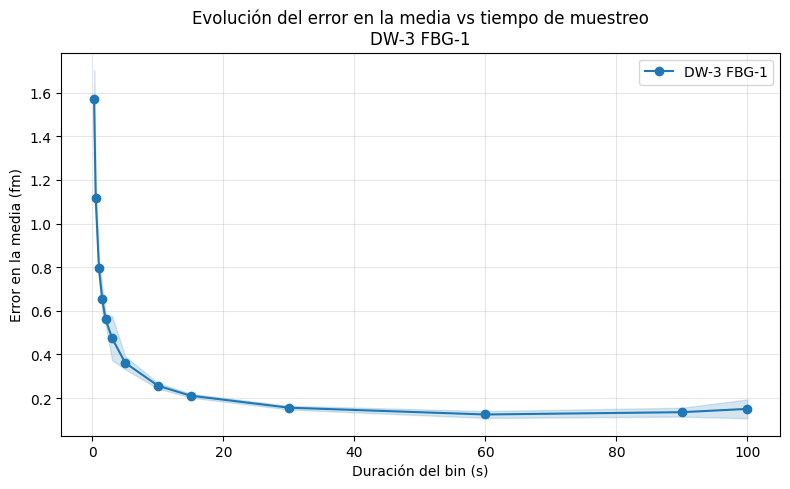

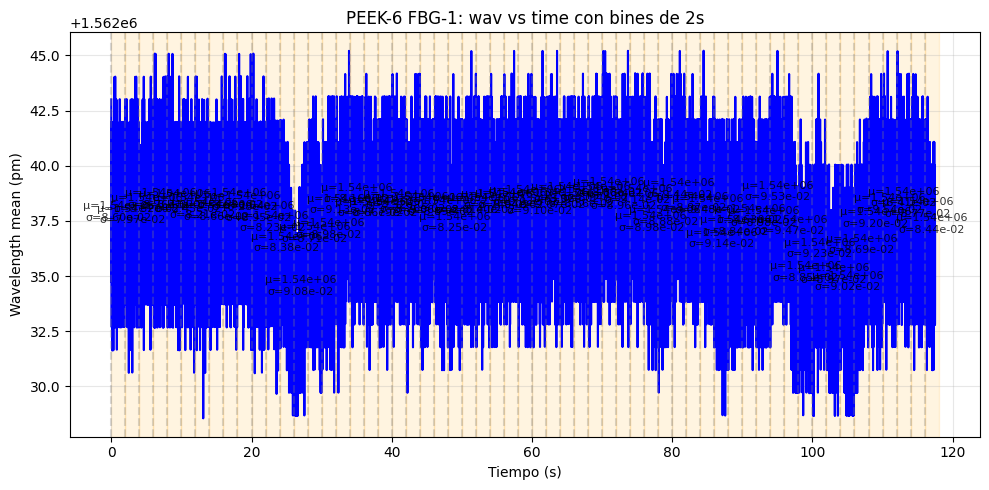

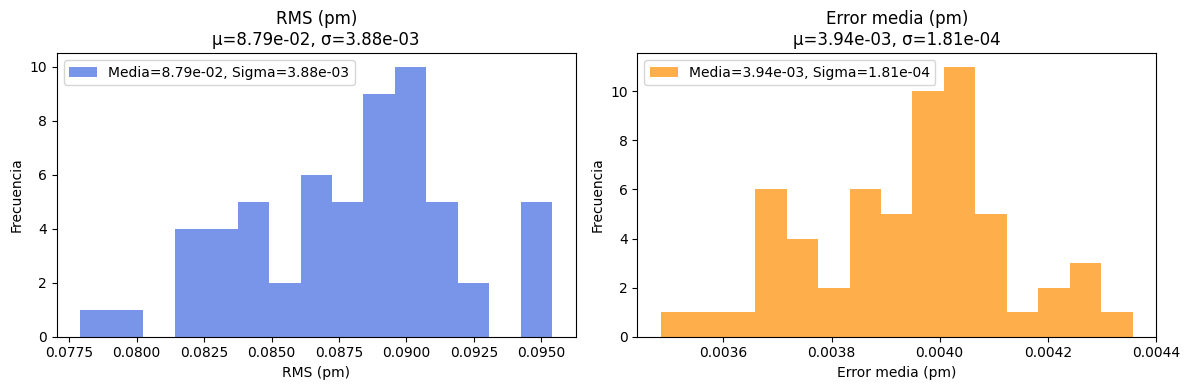

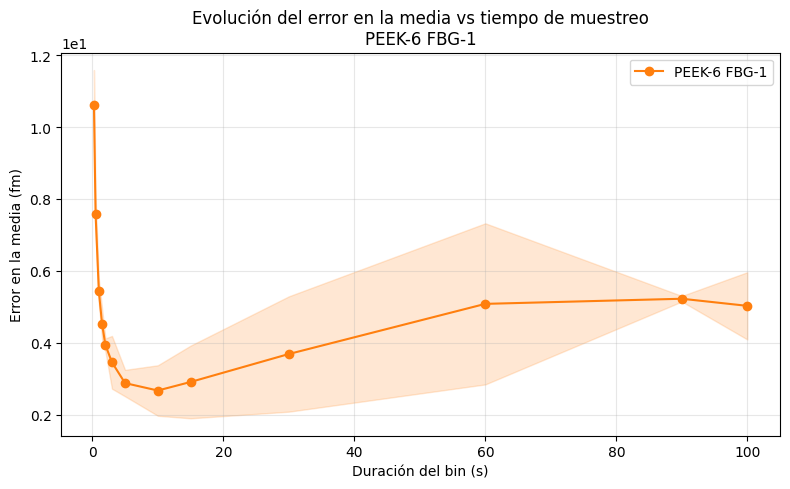

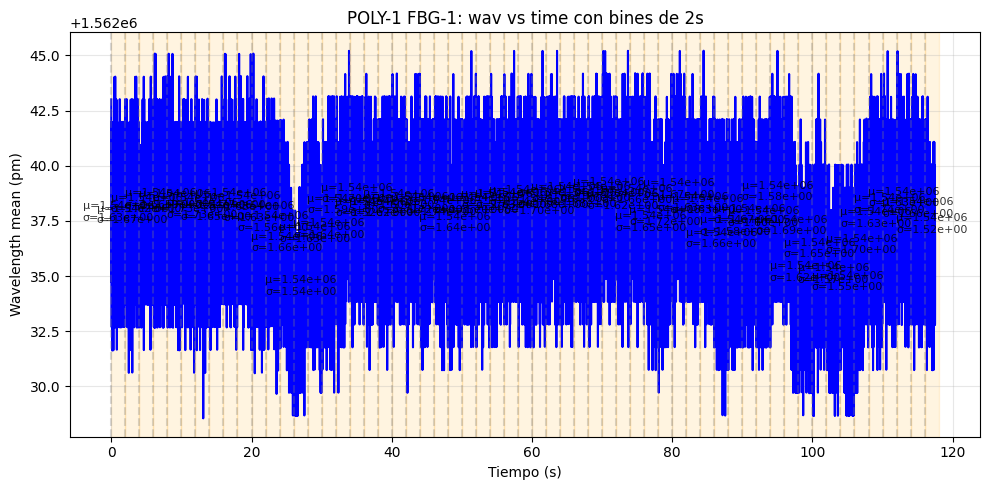

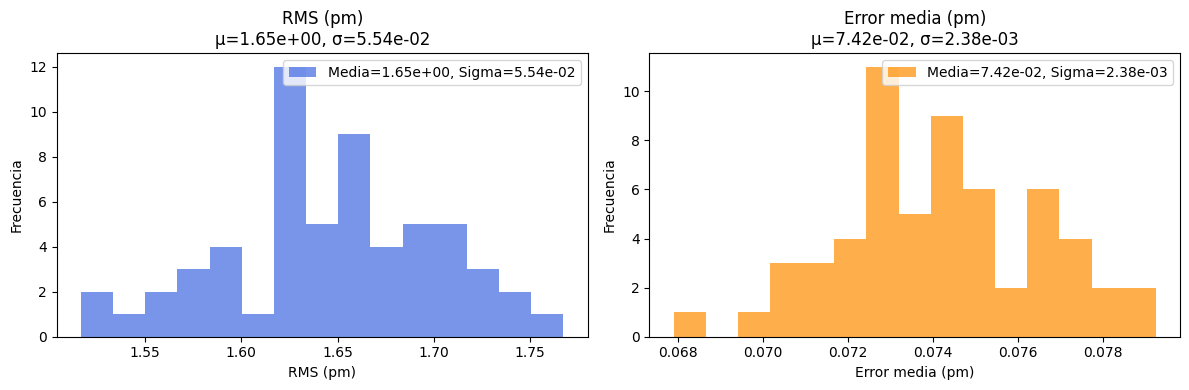

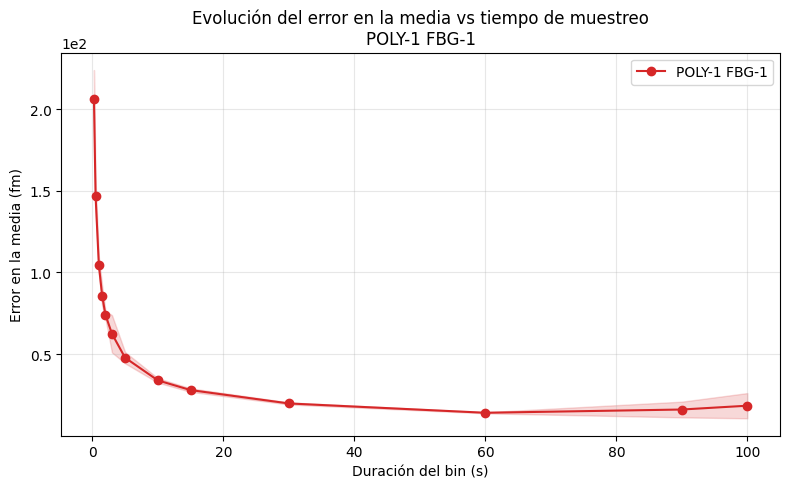

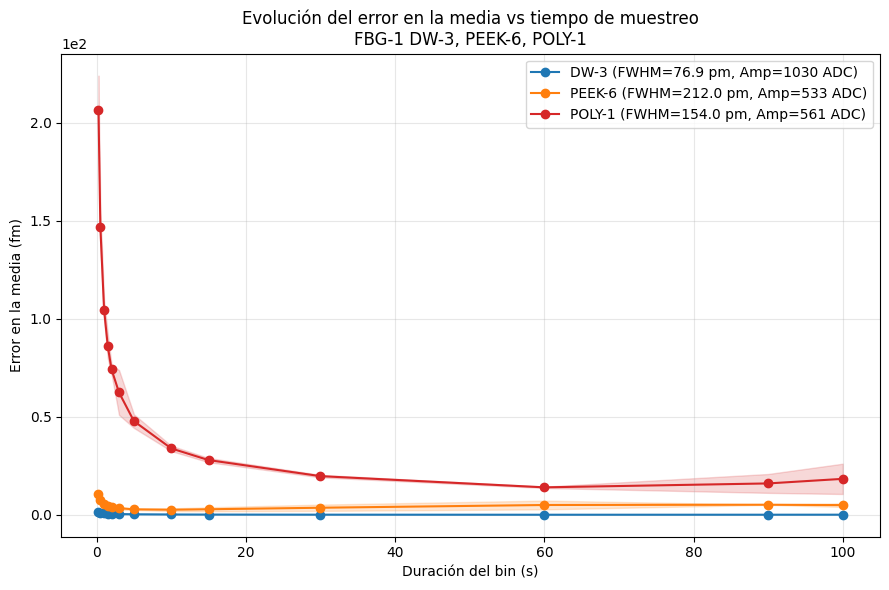

In [30]:
# ═══════════════════════════════════════════════════════════════════════
# Análisis de estabilidad temporal por bines (propuesta Jordi Capó)
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

# Duraciones de bines en segundos
bin_durations = [0.25, 0.5, 1, 1.5, 2, 3, 5, 10, 15, 30, 60, 90, 100]

results = {}
for fiber_idx, fiber_name in enumerate(fiber_names):
    n_sensors_fiber = fiber_config[fiber_name]['sensors']
    sensor_start = sum([fiber_config[f]['sensors'] for f in fiber_names[:fiber_idx]])
    results[fiber_name] = {}
    for sensor_local in range(n_sensors_fiber):
        sensor_global = sensor_start + sensor_local
        wav_p = wav_filtered[:, 0, sensor_global]
        wav_s = wav_filtered[:, 1, sensor_global]
        wav_mean = (wav_p + wav_s) / 2.0
        mask_clean = filter_outliers_robust(wav_mean, sigma_threshold=3.0)
        times_clean = np.array(times_filtered)[mask_clean]
        wav_mean_clean = wav_mean[mask_clean]
        t0 = times_clean[0]
        times_sec = np.array([(t - t0).total_seconds() for t in times_clean])
        bin_stats = []
        for bin_dur in bin_durations:
            n_bins = int(np.ceil((times_sec[-1] - times_sec[0]) / bin_dur))
            mean_list = []
            mean_sigma_list = []
            rms_list = []
            err_list = []
            bin_edges = []
            for b in range(n_bins):
                idx = (times_sec >= b*bin_dur) & (times_sec < (b+1)*bin_dur)
                if np.sum(idx) < 2:
                    continue
                vals = wav_mean_clean[idx] * 1e12  # pm
                mean = np.mean(vals)
                sigma = np.std(vals)
                rms = sigma
                err = rms / np.sqrt(len(vals))
                mean_list.append(mean)
                mean_sigma_list.append(sigma)
                rms_list.append(rms)
                err_list.append(err)
                bin_edges.append((b*bin_dur, (b+1)*bin_dur))
            mean_arr = np.array(mean_list)
            mean_sigma_arr = np.array(mean_sigma_list)
            rms_arr = np.array(rms_list)
            err_arr = np.array(err_list)
            bin_stats.append({
                'bin_dur': bin_dur,
                'mean_arr': mean_arr,
                'mean_sigma_arr': mean_sigma_arr,
                'rms_arr': rms_arr,
                'err_arr': err_arr,
                'bin_edges': bin_edges,
            })
        results[fiber_name][sensor_local+1] = bin_stats

# --- Plots por fibra (FBG-1) ---
for fiber_name in fiber_names:
    bin_stats = results[fiber_name][1]  # FBG-1
    bin_durs = [b['bin_dur'] for b in bin_stats]
    err_means = [np.mean(b['err_arr']) for b in bin_stats]
    err_sigmas = [np.std(b['err_arr']) for b in bin_stats]
    # Plot wav vs time con bines
    bin_dur_plot = 2  # bin de 2s
    stat = bin_stats[[b['bin_dur'] for b in bin_stats].index(bin_dur_plot)]
    plt.figure(figsize=(10,5))
    plt.plot(times_sec, wav_mean_clean * 1e12, label='wav_mean (pm)', color='blue')
    for i, (start, end) in enumerate(stat['bin_edges']):
        plt.axvspan(start, end, color='orange', alpha=0.12)
        plt.axvline(start, color='gray', linestyle='--', alpha=0.3)
        # Etiqueta con stats
        xm = (start + end) / 2
        ym = np.mean(wav_mean_clean[(times_sec >= start) & (times_sec < end)] * 1e12)
        txt = f"μ={stat['mean_arr'][i]:.2e}\nσ={stat['mean_sigma_arr'][i]:.2e}"
        plt.text(xm, ym, txt, fontsize=8, ha='center', va='bottom', color='black', alpha=0.8)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Wavelength mean (pm)')
    plt.title(f'{fiber_name} FBG-1: wav vs time con bines de {bin_dur_plot}s')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # Subplots: histogramas RMS y error en la media
    fig, axs = plt.subplots(1, 2, figsize=(12,4))
    rms_arr = stat['rms_arr']
    err_arr = stat['err_arr']
    rms_mean = np.mean(rms_arr)
    rms_sigma = np.std(rms_arr)
    err_mean = np.mean(err_arr)
    err_sigma = np.std(err_arr)
    axs[0].hist(rms_arr, bins=15, alpha=0.7, color='royalblue')
    axs[0].set_title(f'RMS (pm)\nμ={rms_mean:.2e}, σ={rms_sigma:.2e}')
    axs[0].set_xlabel('RMS (pm)')
    axs[0].set_ylabel('Frecuencia')
    axs[0].legend([f'Media={rms_mean:.2e}, Sigma={rms_sigma:.2e}'])
    axs[1].hist(err_arr, bins=15, alpha=0.7, color='darkorange')
    axs[1].set_title(f'Error media (pm)\nμ={err_mean:.2e}, σ={err_sigma:.2e}')
    axs[1].set_xlabel('Error media (pm)')
    axs[1].set_ylabel('Frecuencia')
    axs[1].legend([f'Media={err_mean:.2e}, Sigma={err_sigma:.2e}'])
    plt.tight_layout()
    plt.show()
    # Plot evolución temporal del error en la media (fm) por separado
    err_means_fm = np.array(err_means) * 1e3
    err_sigmas_fm = np.array(err_sigmas) * 1e3
    plt.figure(figsize=(8,5))
    plt.plot(bin_durs, err_means_fm, 'o-', color=fiber_config[fiber_name]['color'], label=f'{fiber_name} FBG-1')
    plt.fill_between(bin_durs, err_means_fm - err_sigmas_fm, err_means_fm + err_sigmas_fm, color=fiber_config[fiber_name]['color'], alpha=0.18)
    plt.xlabel('Duración del bin (s)')
    plt.ylabel('Error en la media (fm)')
    plt.title(f'Evolución del error en la media vs tiempo de muestreo\n{fiber_name} FBG-1')
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Extraer FWHM y amplitud para FBG-1 de cada fibra ---
fiber_plot_info = {}
for fn in fiber_names:
    peaks = fbg_analysis_results[fn]['Pol P']
    if len(peaks) > 0:
        fwhm_pm = peaks[0]['fwhm'] * _dlam_pm
        amp = peaks[0]['amplitude']
        fiber_plot_info[fn] = {'fwhm_pm': fwhm_pm, 'amp': amp}
    else:
        fiber_plot_info[fn] = {'fwhm_pm': np.nan, 'amp': np.nan}

# --- Nuevo plot: evolución del error en la media (fm) para FBG-1 de cada fibra ---
plt.figure(figsize=(9,6))
colors = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}
for fn in fiber_names:
    bin_stats = results[fn][1]  # FBG-1
    bin_durs = [b['bin_dur'] for b in bin_stats]
    err_means = [np.mean(b['err_arr']) for b in bin_stats]
    err_sigmas = [np.std(b['err_arr']) for b in bin_stats]
    # Convertir a femtometros
    err_means_fm = np.array(err_means) * 1e3
    err_sigmas_fm = np.array(err_sigmas) * 1e3
    fwhm = fiber_plot_info[fn]['fwhm_pm']
    amp = fiber_plot_info[fn]['amp']
    label = f"{fn} (FWHM={fwhm:.1f} pm, Amp={amp:.0f} ADC)"
    plt.plot(bin_durs, err_means_fm, 'o-', color=colors[fn], label=label)
    plt.fill_between(bin_durs, err_means_fm - err_sigmas_fm, err_means_fm + err_sigmas_fm, color=colors[fn], alpha=0.18)
plt.xlabel('Duración del bin (s)')
plt.ylabel('Error en la media (fm)')
plt.title('Evolución del error en la media vs tiempo de muestreo\nFBG-1 DW-3, PEEK-6, POLY-1')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


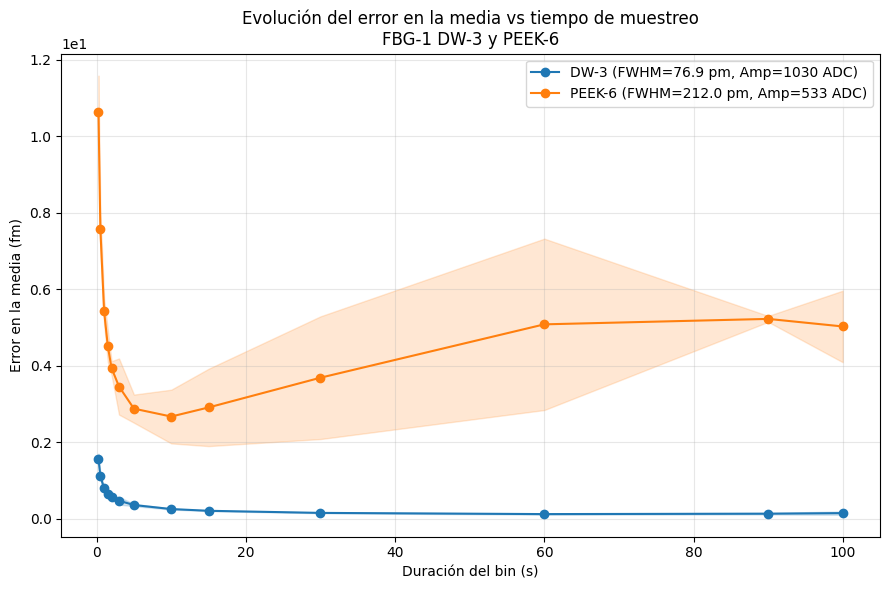

In [31]:
# --- Plot: evolución del error en la media (fm) solo para DW-3 y PEEK-6 ---
plt.figure(figsize=(9,6))
colors = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange'}
for fn in ['DW-3', 'PEEK-6']:
    bin_stats = results[fn][1]  # FBG-1
    bin_durs = [b['bin_dur'] for b in bin_stats]
    err_means = [np.mean(b['err_arr']) for b in bin_stats]
    err_sigmas = [np.std(b['err_arr']) for b in bin_stats]
    # Convertir a femtometros
    err_means_fm = np.array(err_means) * 1e3
    err_sigmas_fm = np.array(err_sigmas) * 1e3
    fwhm = fiber_plot_info[fn]['fwhm_pm']
    amp = fiber_plot_info[fn]['amp']
    label = f"{fn} (FWHM={fwhm:.1f} pm, Amp={amp:.0f} ADC)"
    plt.plot(bin_durs, err_means_fm, 'o-', color=colors[fn], label=label)
    plt.fill_between(bin_durs, err_means_fm - err_sigmas_fm, err_means_fm + err_sigmas_fm, color=colors[fn], alpha=0.18)
plt.xlabel('Duración del bin (s)')
plt.ylabel('Error en la media (fm)')
plt.title('Evolución del error en la media vs tiempo de muestreo\nFBG-1 DW-3 y PEEK-6')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


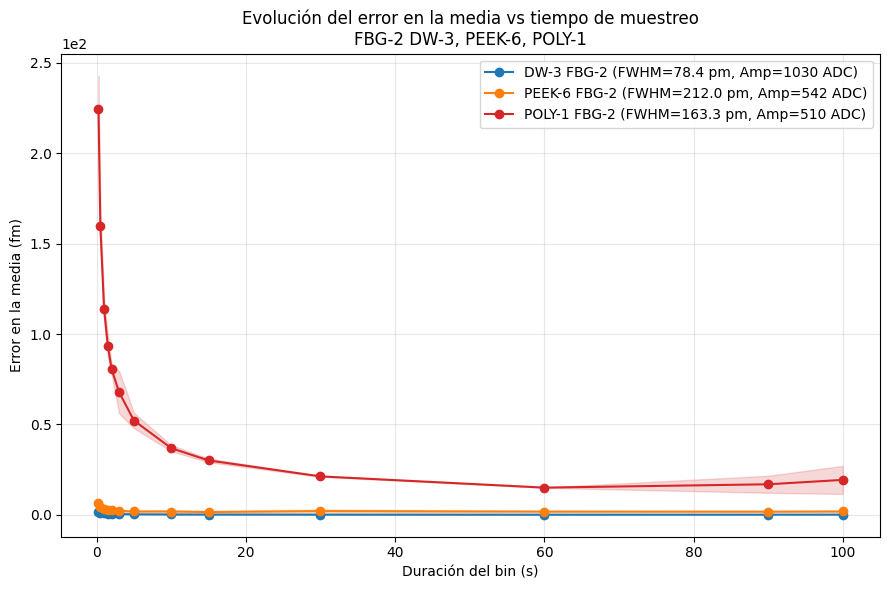

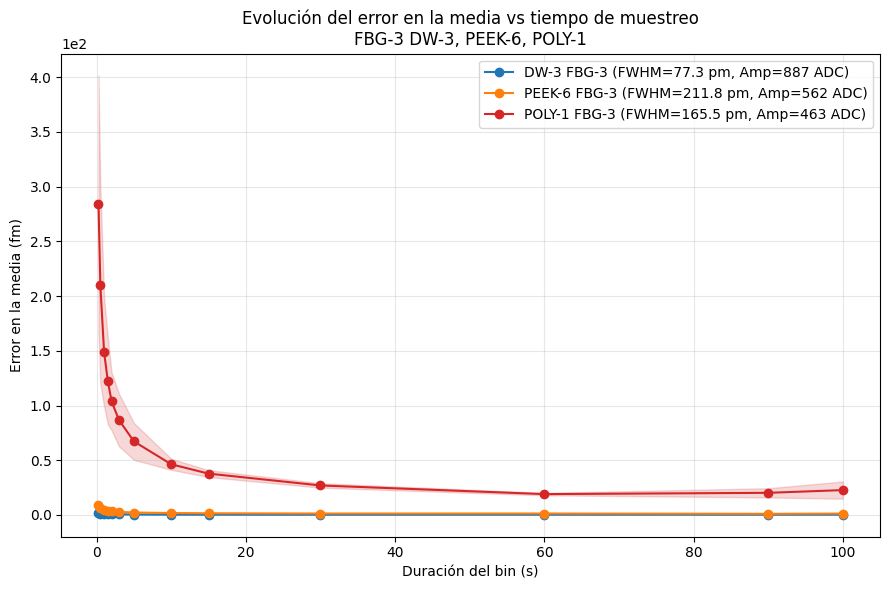

In [33]:
# --- Extraer FWHM y amplitud para cada sensor de cada fibra ---
sensor_plot_info = {}
for fn in fiber_names:
    sensor_plot_info[fn] = {}
    for sensor_idx in [1,2,3]:
        peaks = fbg_analysis_results[fn]['Pol P']
        if len(peaks) >= sensor_idx:
            fwhm_pm = peaks[sensor_idx-1]['fwhm'] * _dlam_pm
            amp = peaks[sensor_idx-1]['amplitude']
            sensor_plot_info[fn][sensor_idx] = {'fwhm_pm': fwhm_pm, 'amp': amp}
        else:
            sensor_plot_info[fn][sensor_idx] = {'fwhm_pm': np.nan, 'amp': np.nan}

# --- Plot: evolución del error en la media (fm) para FBG-2 de cada fibra ---
plt.figure(figsize=(9,6))
colors = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}
for fn in fiber_names:
    bin_stats = results[fn][2]  # FBG-2
    bin_durs = [b['bin_dur'] for b in bin_stats]
    err_means = [np.mean(b['err_arr']) for b in bin_stats]
    err_sigmas = [np.std(b['err_arr']) for b in bin_stats]
    # Convertir a femtometros
    err_means_fm = np.array(err_means) * 1e3
    err_sigmas_fm = np.array(err_sigmas) * 1e3
    fwhm = sensor_plot_info[fn][2]['fwhm_pm']
    amp = sensor_plot_info[fn][2]['amp']
    label = f"{fn} FBG-2 (FWHM={fwhm:.1f} pm, Amp={amp:.0f} ADC)"
    plt.plot(bin_durs, err_means_fm, 'o-', color=colors[fn], label=label)
    plt.fill_between(bin_durs, err_means_fm - err_sigmas_fm, err_means_fm + err_sigmas_fm, color=colors[fn], alpha=0.18)
plt.xlabel('Duración del bin (s)')
plt.ylabel('Error en la media (fm)')
plt.title('Evolución del error en la media vs tiempo de muestreo\nFBG-2 DW-3, PEEK-6, POLY-1')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot: evolución del error en la media (fm) para FBG-3 de cada fibra ---
plt.figure(figsize=(9,6))
for fn in fiber_names:
    bin_stats = results[fn][3]  # FBG-3
    bin_durs = [b['bin_dur'] for b in bin_stats]
    err_means = [np.mean(b['err_arr']) for b in bin_stats]
    err_sigmas = [np.std(b['err_arr']) for b in bin_stats]
    # Convertir a femtometros
    err_means_fm = np.array(err_means) * 1e3
    err_sigmas_fm = np.array(err_sigmas) * 1e3
    fwhm = sensor_plot_info[fn][3]['fwhm_pm']
    amp = sensor_plot_info[fn][3]['amp']
    label = f"{fn} FBG-3 (FWHM={fwhm:.1f} pm, Amp={amp:.0f} ADC)"
    plt.plot(bin_durs, err_means_fm, 'o-', color=colors[fn], label=label)
    plt.fill_between(bin_durs, err_means_fm - err_sigmas_fm, err_means_fm + err_sigmas_fm, color=colors[fn], alpha=0.18)
plt.xlabel('Duración del bin (s)')
plt.ylabel('Error en la media (fm)')
plt.title('Evolución del error en la media vs tiempo de muestreo\nFBG-3 DW-3, PEEK-6, POLY-1')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 4.2 Diagnóstico: Calidad de fit del interrogador

Ajuste Gaussiano a cada pico → residuos + correlación con dispersión temporal. Si incluso con una sola polarización las bandas son anchas, el problema es la **forma del pico**, no la birrefringencia.

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# Pre-requisitos para §4.2: Carga de espectro + config + detección picos
# (estas variables se redefinen en §5–§6; aquí se inicializan para
#  permitir ejecución secuencial top-to-bottom del notebook)
# ═══════════════════════════════════════════════════════════════════════
from scipy.signal import find_peaks, peak_widths

if data_spectrum is not None:
    # 1. Cargar datos de espectro
    spectrum_wav = data_spectrum['wav']
    spectrum_t   = data_spectrum['t']
    idx_espectro = min(50, spectrum_wav.shape[0] - 1)
    n_espectros, n_pol, n_chan, n_puntos = spectrum_wav.shape

    # 2. Configuración del interrogador FAZT I4G-16
    _lam_start      = 1529.0    # nm
    _lam_end        = 1568.2    # nm
    LAMBDA_START_NM = _lam_start
    LAMBDA_END_NM   = _lam_end
    _dlam           = (_lam_end - _lam_start) / (n_puntos - 1)   # nm/pt
    dlam_nm_per_pt  = (LAMBDA_END_NM - LAMBDA_START_NM) / n_puntos
    wavelength_axis = np.linspace(_lam_start, _lam_end, n_puntos)

    # 3. Canales y polarizaciones
    channel_names        = {0: 'DW-3', 1: 'PEEK-6', 2: 'POLY-1'}
    n_channels_available = min(n_chan, 3)
    pol_labels           = ['Pol P', 'Pol S']

    DESIGN_N_SENSORS = {'DW-3': 4, 'PEEK-6': 3, 'POLY-1': 4}

    # 4. Detección de picos FBG
    def find_all_fbg_peaks(signal, min_prominence_factor=0.10,
                           min_distance=50, min_height_factor=0.05):
        sig_max = signal.max()
        peaks, _ = find_peaks(signal,
                              prominence=sig_max * min_prominence_factor,
                              distance=min_distance,
                              height=sig_max * min_height_factor)
        if len(peaks) == 0:
            return []
        widths, w_heights, left_ips, right_ips = peak_widths(
            signal, peaks, rel_height=0.5)
        return [{'peak_idx': p, 'fwhm': widths[i], 'amplitude': signal[p],
                 'left_ip': left_ips[i], 'right_ip': right_ips[i],
                 'width_height': w_heights[i]}
                for i, p in enumerate(peaks)]

    fbg_analysis_results = {}
    for ch in range(n_channels_available):
        fn = channel_names.get(ch, f'Canal-{ch}')
        fbg_analysis_results[fn] = {}
        for pol_idx, pol_name in enumerate(pol_labels):
            signal = spectrum_wav[idx_espectro, pol_idx, ch, :]
            fbg_analysis_results[fn][pol_name] = find_all_fbg_peaks(signal)

    # 5. cross_pol se puebla en §9; inicializar vacío
    cross_pol = {}

    print(f"✅ Bootstrap §4.2 completado:")
    print(f"   Espectro: {spectrum_wav.shape}  (λ: {LAMBDA_START_NM}–{LAMBDA_END_NM} nm, "
          f"{n_puntos} pts, Δλ = {_dlam*1e3:.2f} pm/pt)")
    for fn in channel_names.values():
        peaks_str = ', '.join(f"{pn}: {len(fbg_analysis_results[fn][pn])}"
                              for pn in pol_labels)
        print(f"   {fn} — {peaks_str}")
else:
    print("⚠️  data_spectrum no disponible — §4.2 no se puede ejecutar")

✅ Bootstrap §4.2 completado:
   Espectro: (117, 2, 3, 39200)  (λ: 1529.0–1568.2 nm, 39200 pts, Δλ = 1.00 pm/pt)
   DW-3 — Pol P: 5, Pol S: 5
   PEEK-6 — Pol P: 3, Pol S: 3
   POLY-1 — Pol P: 4, Pol S: 4


📊 DIAGNÓSTICO: Calidad de fit vs Dispersión temporal
  Fibra    FBG     FWHM   rms%     σ_P     σ_S  σ_mean   |P-S|  Biref   Outl
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  DW-3     1        77    3.3    0.02   0.02    0.02      1    nan    161
  DW-3     2        78    3.5    0.03   0.03    0.03      2    nan     61
  DW-3     3        77    3.6    0.07   0.07    0.07      1    nan      0
  DW-3     4        80    3.1    0.03   0.03    0.02      0    nan     12
  PEEK-6   1       212    1.0    1.26   1.26    1.26      1    nan      0
  PEEK-6   2       212    1.0    0.38   0.38    0.38      0    nan      0
  PEEK-6   3       212    0.7    0.18   0.19    0.17      1    nan      4
  POLY-1   1       154    2.5    2.05   2.76    1.70     10    nan    237
  POLY-1   2       163    3.1    2.55   2.76    1.82      4    nan    455
  POLY-1   3       166    3.1    2.18   2.72    1.78   1024    nan  12033
  POLY-1   4       165    3

/tmp/vgarciap/ipykernel_2558287/783336810.py:153: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=6, ncol=2); ax2.grid(True, alpha=0.3)


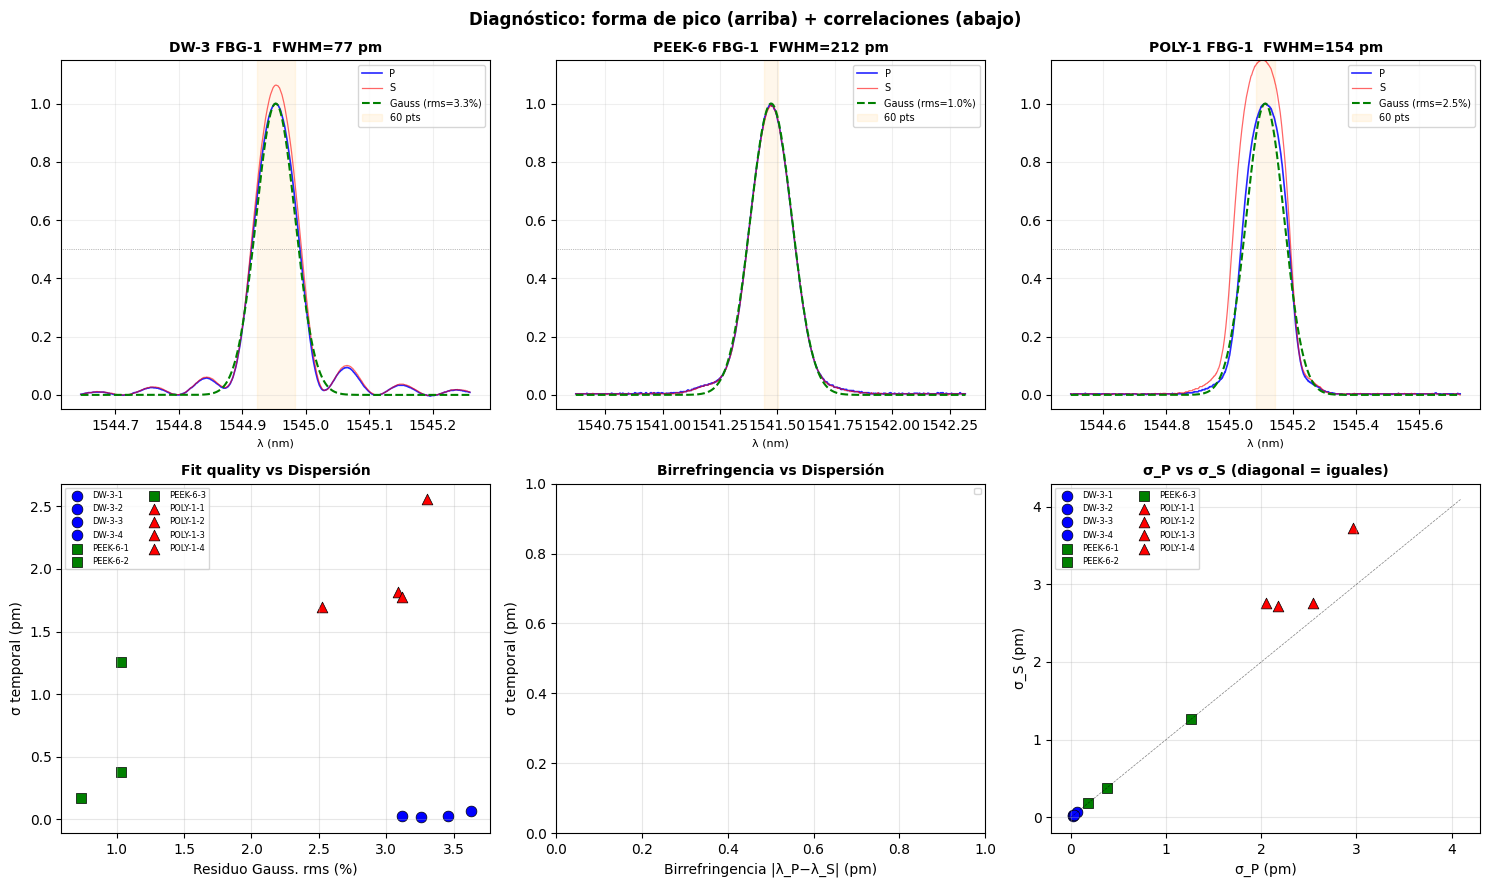


📌 Conclusión: POLY-1 σ_S > σ_P para todos los sensores → picos mal condicionados.
   Aun con 1 sola pol, σ_P ≈ 2 pm (vs 0.03 DW-3) → no es solo birrefringencia.


In [8]:
# ══════════════════════════════════════════════════════════════════════
# §4.2 DIAGNÓSTICO COMPACTO: Fit Gaussiano + Correlación con dispersión
# ══════════════════════════════════════════════════════════════════════
from scipy.optimize import curve_fit

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

_dlam = (LAMBDA_END_NM - LAMBDA_START_NM) / (n_puntos - 1)
_dlam_pm = _dlam * 1e3

# --- 1) Ajuste Gaussiano a cada sensor/pol ---
fit_results = {}
rows = []  # para tabla resumen unificada

for ch in range(n_channels_available):
    fn = channel_names.get(ch, f'Canal-{ch}')
    fit_results[fn] = {}
    for pol_idx, pol_name in enumerate(pol_labels):
        signal = spectrum_wav[idx_espectro, pol_idx, ch, :]
        peaks = fbg_analysis_results.get(fn, {}).get(pol_name, [])
        for i, pk in enumerate(peaks, 1):
            pidx, fw, amp = pk['peak_idx'], pk['fwhm'], pk['amplitude']
            hw = max(int(fw * 3), 100)
            x0, x1 = max(0, pidx - hw), min(n_puntos, pidx + hw)
            x_pts = np.arange(x0, x1)
            y_data = signal[x0:x1]
            try:
                popt, _ = curve_fit(gaussian, x_pts, y_data,
                                    p0=[amp, pidx, fw / 2.355], maxfev=5000)
                resid = (y_data - gaussian(x_pts, *popt)) / popt[0]
                rms_r = np.sqrt(np.mean(resid**2))
                fit_results[fn][(i, pol_name)] = {
                    'fwhm_pm': fw * _dlam_pm, 'rms_residual': rms_r,
                    'popt': popt, 'amp': amp,
                    'sigma_gauss_pm': abs(popt[2]) * _dlam_pm,
                }
            except Exception:
                pass

# --- 2) Dispersión por polarización separada ---
pol_rows = []
sensor_start = 0
for fn in fiber_names:
    ch = list(channel_names.values()).index(fn)
    for s in range(DESIGN_N_SENSORS[fn]):
        s_glob = sensor_start + s
        stats = {}
        for lbl, data in [('P', wav_filtered[:, 0, s_glob]),
                          ('S', wav_filtered[:, 1, s_glob]),
                          ('M', (wav_filtered[:, 0, s_glob] + wav_filtered[:, 1, s_glob]) / 2)]:
            med = np.median(data)
            mad_v = np.median(np.abs(data - med))
            sig = 1.4826 * mad_v
            m = np.abs(data - med) <= 3 * sig if sig > 0 else np.ones(len(data), bool)
            stats[lbl] = {'std_pm': np.std(data[m]) * 1e12,
                          'iqr_pm': (np.percentile(data[m], 75) - np.percentile(data[m], 25)) * 1e12}
        sep = abs(np.median(wav_filtered[:, 0, s_glob]) - np.median(wav_filtered[:, 1, s_glob])) * 1e12
        pol_rows.append({'Fibra': fn, 'FBG': s+1,
                         'σ_P': stats['P']['std_pm'], 'σ_S': stats['S']['std_pm'],
                         'σ_mean': stats['M']['std_pm'], '|P-S|': sep})
    sensor_start += DESIGN_N_SENSORS[fn]

# --- 3) Tabla resumen unificada ---
print("📊 DIAGNÓSTICO: Calidad de fit vs Dispersión temporal")
print("=" * 110)
print(f"  {'Fibra':<8} {'FBG':<5} {'FWHM':>6} {'rms%':>6} {'σ_P':>7} {'σ_S':>7} "
      f"{'σ_mean':>7} {'|P-S|':>7} {'Biref':>6} {'Outl':>6}")
print("  " + "─" * 100)

for fn in fiber_names:
    spreads = fiber_spread_metrics.get(fn, [])
    for s_idx, sp in enumerate(spreads):
        sn = s_idx + 1
        kp = (sn, 'Pol P')
        fr = fit_results.get(fn, {}).get(kp, {})
        fwhm = fr.get('fwhm_pm', np.nan)
        rms = fr.get('rms_residual', np.nan) * 100 if 'rms_residual' in fr else np.nan
        pr = next((r for r in pol_rows if r['Fibra'] == fn and r['FBG'] == sn), {})
        biref = cross_pol.get(fn, {}).get(sn, {}).get('birefringence_pm', np.nan)
        print(f"  {fn:<8} {sn:<5} {fwhm:>5.0f}  {rms:>5.1f}  {pr.get('σ_P',0):>6.2f} "
              f"{pr.get('σ_S',0):>6.2f}  {pr.get('σ_mean',0):>6.2f} {pr.get('|P-S|',0):>6.0f}  "
              f"{biref:>5.0f}  {sp['n_outliers']:>5d}")

# --- 4) Figura compacta: forma de pico + scatter ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Fila superior: forma de pico (1 FBG representativo por fibra, Pol P vs Gauss)
for ci, fn in enumerate(fiber_names):
    ax = axes[0, ci]
    peaks_p = fbg_analysis_results.get(fn, {}).get('Pol P', [])
    ch = list(channel_names.values()).index(fn)
    if not peaks_p:
        ax.set_visible(False); continue
    pk = peaks_p[0]  # FBG-1 como representativo
    pidx, fw = pk['peak_idx'], pk['fwhm']
    win = max(int(fw * 4), 150)
    x0, x1 = max(0, pidx - win), min(n_puntos, pidx + win)
    x_nm = wavelength_axis[x0:x1]
    sig_p = spectrum_wav[idx_espectro, 0, ch, x0:x1]
    sig_s = spectrum_wav[idx_espectro, 1, ch, x0:x1]
    a_max = sig_p.max()
    ax.plot(x_nm, sig_p / a_max, 'b-', lw=1.2, alpha=0.85, label='P')
    ax.plot(x_nm, sig_s / a_max, 'r-', lw=0.9, alpha=0.6, label='S')
    kp = (1, 'Pol P')
    if kp in fit_results.get(fn, {}):
        fr = fit_results[fn][kp]
        xg = np.linspace(x0, x1, 500)
        yg = gaussian(xg, *fr['popt']) / fr['popt'][0]
        ax.plot(wavelength_axis[0] + xg * _dlam, yg, 'g--', lw=1.5,
                label=f'Gauss (rms={fr["rms_residual"]*100:.1f}%)')
    fl = wavelength_axis[max(0, pidx - 30)]
    fr_r = wavelength_axis[min(n_puntos-1, pidx + 30)]
    ax.axvspan(fl, fr_r, alpha=0.08, color='orange', label='60 pts')
    ax.axhline(0.5, color='gray', lw=0.5, ls=':')
    ax.set_title(f'{fn} FBG-1  FWHM={fw*_dlam_pm:.0f} pm', fontsize=10, fontweight='bold')
    ax.set_xlabel('λ (nm)', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_ylim(-0.05, 1.15)
    ax.grid(True, alpha=0.2)

# Fila inferior: scatter plots
marker_map = {'DW-3': 'o', 'PEEK-6': 's', 'POLY-1': '^'}
color_map = {'DW-3': 'blue', 'PEEK-6': 'green', 'POLY-1': 'red'}

# Scatter 1: rms_residuo vs σ_temporal
ax1 = axes[1, 0]
for fn in fiber_names:
    spreads = fiber_spread_metrics.get(fn, [])
    for si, sp in enumerate(spreads):
        kp = (si+1, 'Pol P')
        if kp in fit_results.get(fn, {}):
            ax1.scatter(fit_results[fn][kp]['rms_residual']*100, sp['std_pm'],
                        marker=marker_map[fn], color=color_map[fn], s=60,
                        edgecolors='k', lw=0.5, label=f'{fn}-{si+1}')
ax1.set_xlabel('Residuo Gauss. rms (%)')
ax1.set_ylabel('σ temporal (pm)')
ax1.set_title('Fit quality vs Dispersión', fontsize=10, fontweight='bold')
ax1.legend(fontsize=6, ncol=2); ax1.grid(True, alpha=0.3)

# Scatter 2: birefringencia vs σ_temporal
ax2 = axes[1, 1]
for fn in fiber_names:
    spreads = fiber_spread_metrics.get(fn, [])
    for si, sp in enumerate(spreads):
        b = cross_pol.get(fn, {}).get(si+1, {}).get('birefringence_pm', np.nan)
        if not np.isnan(b):
            ax2.scatter(b, sp['std_pm'], marker=marker_map[fn], color=color_map[fn],
                        s=60, edgecolors='k', lw=0.5, label=f'{fn}-{si+1}')
ax2.set_xlabel('Birrefringencia |λ_P−λ_S| (pm)')
ax2.set_ylabel('σ temporal (pm)')
ax2.set_title('Birrefringencia vs Dispersión', fontsize=10, fontweight='bold')
ax2.legend(fontsize=6, ncol=2); ax2.grid(True, alpha=0.3)

# Scatter 3: σ_P vs σ_S (identidad → no es biref)
ax3 = axes[1, 2]
for r in pol_rows:
    fn = r['Fibra']
    ax3.scatter(r['σ_P'], r['σ_S'], marker=marker_map[fn], color=color_map[fn],
                s=60, edgecolors='k', lw=0.5, label=f'{fn}-{r["FBG"]}')
lim = max(max(r['σ_P'] for r in pol_rows), max(r['σ_S'] for r in pol_rows)) * 1.1
ax3.plot([0, lim], [0, lim], 'k--', lw=0.5, alpha=0.5)
ax3.set_xlabel('σ_P (pm)'); ax3.set_ylabel('σ_S (pm)')
ax3.set_title('σ_P vs σ_S (diagonal = iguales)', fontsize=10, fontweight='bold')
ax3.legend(fontsize=6, ncol=2); ax3.grid(True, alpha=0.3)

plt.suptitle('Diagnóstico: forma de pico (arriba) + correlaciones (abajo)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📌 Conclusión: POLY-1 σ_S > σ_P para todos los sensores → picos mal condicionados.")
print(f"   Aun con 1 sola pol, σ_P ≈ 2 pm (vs 0.03 DW-3) → no es solo birrefringencia.")

## 5️⃣ Análisis de Espectros: FWHM y Calidad de Picos

Analiza los espectros de las 3 fibras para determinar:
- FWHM de cada sensor
- Separación entre sensores
- Calidad de los picos

In [9]:
if data_spectrum is None:
    print("⚠️  No hay datos de espectros disponibles")
else:
    spectrum_wav = data_spectrum['wav']
    spectrum_t = data_spectrum['t']
    
    print(f"📊 Análisis de espectros")
    print(f"   Shape: {spectrum_wav.shape}")
    
    # Usar un espectro representativo (último o el del medio)
    idx_espectro = min(50, spectrum_wav.shape[0] - 1)
    n_espectros, n_pol, n_chan, n_puntos = spectrum_wav.shape
    
    print(f"   Espectro #{idx_espectro} seleccionado")
    print(f"   Canales disponibles: {n_chan}")
    print(f"   Polarizaciones: {n_pol}")
    print(f"   Puntos por espectro: {n_puntos}")

📊 Análisis de espectros
   Shape: (117, 2, 3, 39200)
   Espectro #50 seleccionado
   Canales disponibles: 3
   Polarizaciones: 2
   Puntos por espectro: 39200


### 5.1 Plot Espectros Completos (3 canales)

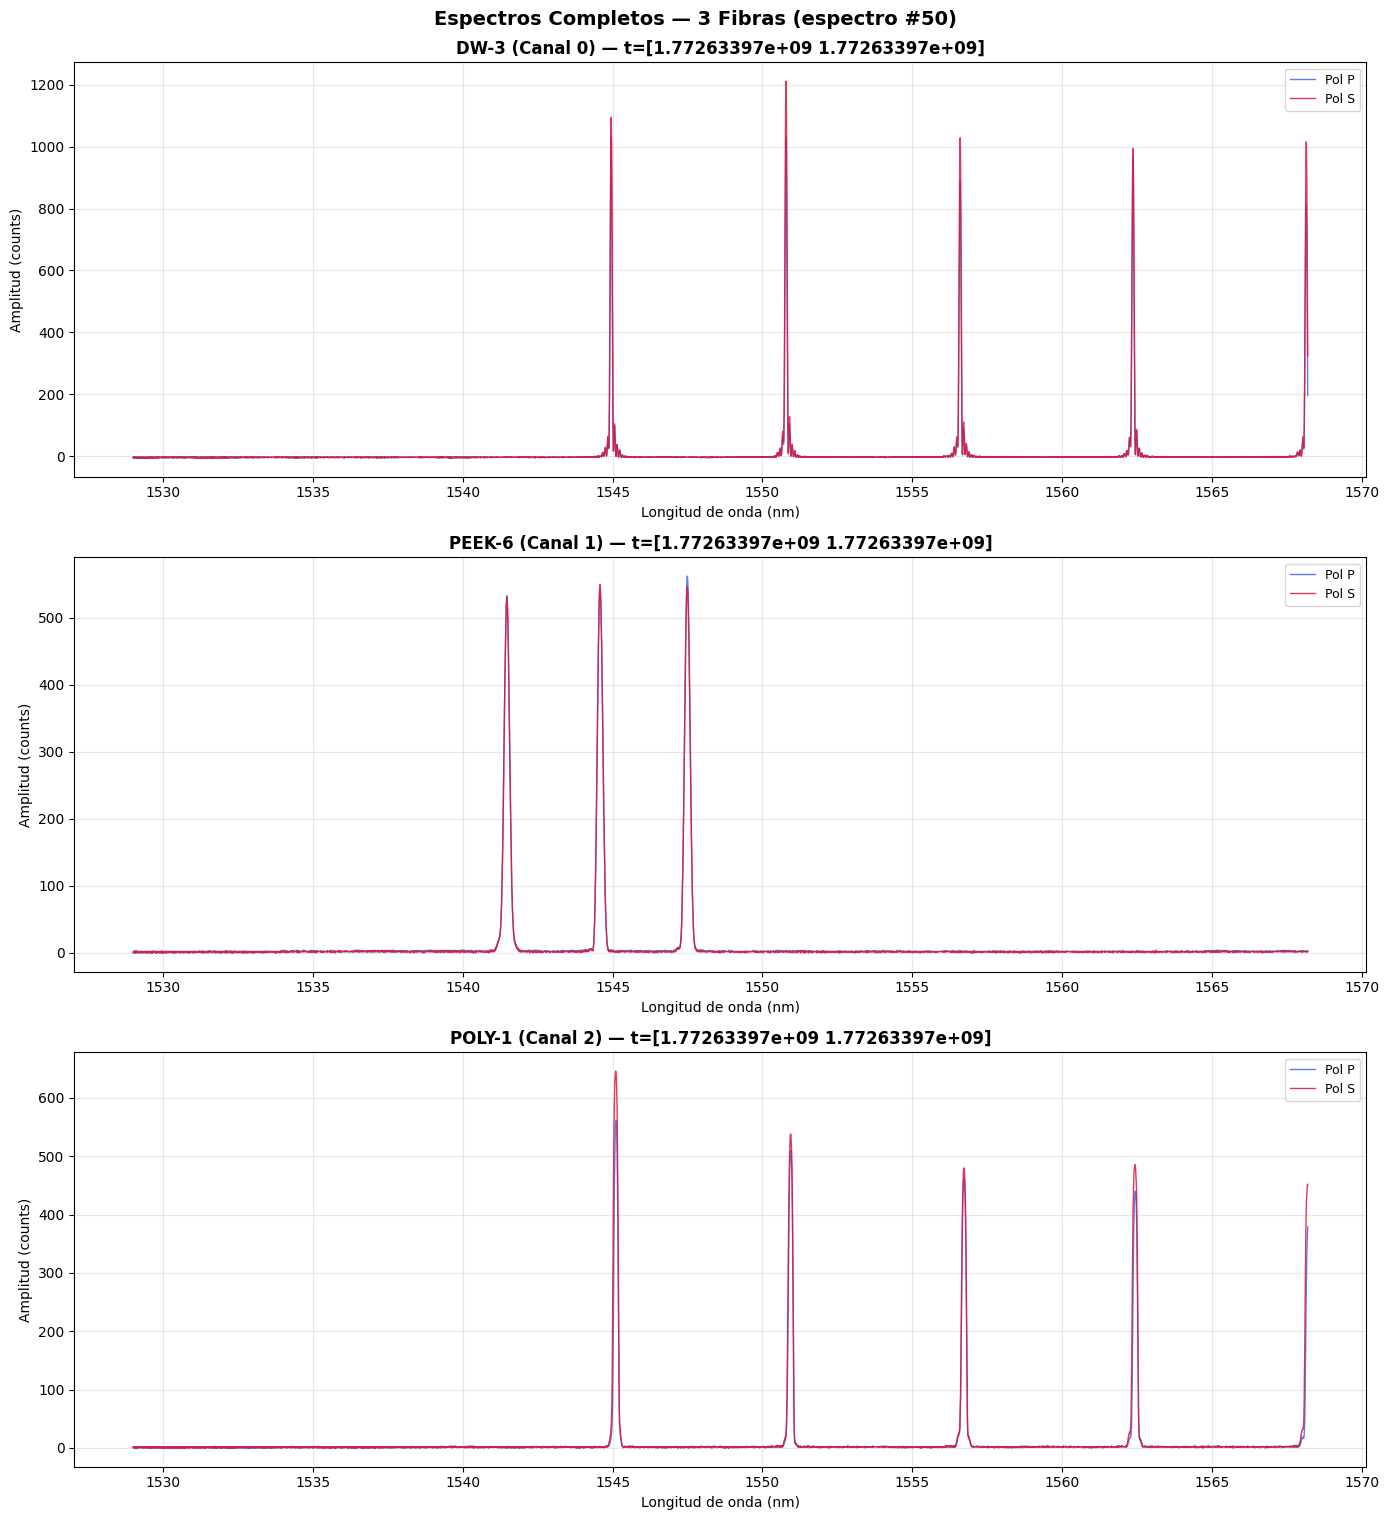


📊 ANÁLISIS PRELIMINAR DE LOS ESPECTROS (espectro #50)
   Resolución del eje λ: Δλ = 1.00 pm/punto (39200 puntos en 39.2 nm)

  ── DW-3 (────────────────────────────────────────────────────────────)
  Picos detectados: Pol P = 5, Pol S = 5
  Amplitudes Pol P:
    FBG-1: λ = 1544.952 nm,  Amp = 1030 counts
    FBG-2: λ = 1550.787 nm,  Amp = 1030 counts
    FBG-3: λ = 1556.599 nm,  Amp = 887 counts
    FBG-4: λ = 1562.368 nm,  Amp = 962 counts
    FBG-5: λ = 1568.147 nm,  Amp = 812 counts
  Rango amplitudes: 812 – 1030 counts (ratio max/min = 1.27×)
  Espaciado entre sensores:
    FBG-1 → FBG-2: Δλ = 5.834 nm
    FBG-2 → FBG-3: Δλ = 5.812 nm
    FBG-3 → FBG-4: Δλ = 5.769 nm
    FBG-4 → FBG-5: Δλ = 5.779 nm
  Espaciado medio: 5.799 ± 0.026 nm

  ── PEEK-6 (────────────────────────────────────────────────────────────)
  Picos detectados: Pol P = 3, Pol S = 3
  Amplitudes Pol P:
    FBG-1: λ = 1541.470 nm,  Amp = 533 counts
    FBG-2: λ = 1544.582 nm,  Amp = 542 counts
    FBG-3: λ = 1547.4

In [10]:
if data_spectrum is not None:
    # ── Constantes de conversión idx → λ (FAZT I4G-16) ──
    _lam_start = 1529.0   # nm
    _lam_end   = 1568.2   # nm
    _dlam      = (_lam_end - _lam_start) / (n_puntos - 1)   # nm/pt ≈ 0.001
    wavelength_axis = np.linspace(_lam_start, _lam_end, n_puntos)

    # Configuración de canales
    channel_names = {0: 'DW-3', 1: 'PEEK-6', 2: 'POLY-1'}
    pol_labels = ['Pol P', 'Pol S']

    n_channels_available = min(n_chan, 3)
    n_channels_plot = n_channels_available

    # ── VERTICAL STACKING: 3 filas × 1 columna ──
    fig, axes = plt.subplots(n_channels_plot, 1, figsize=(14, 5 * n_channels_plot))
    if n_channels_plot == 1:
        axes = [axes]

    # Colores por polarización
    pol_colors = ['royalblue', 'crimson']

    for i in range(n_channels_plot):
        ax = axes[i]
        for idx_pol in range(n_pol):
            signal = spectrum_wav[idx_espectro, idx_pol, i, :]
            ax.plot(wavelength_axis, signal, label=pol_labels[idx_pol],
                    linewidth=1.0, alpha=0.85, color=pol_colors[idx_pol])

        t = spectrum_t[idx_espectro]
        fiber_name = channel_names.get(i, f'Canal-{i}')
        ax.set_title(f'{fiber_name} (Canal {i}) — t={t}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Longitud de onda (nm)', fontsize=10)
        ax.set_ylabel('Amplitud (counts)', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.suptitle(f'Espectros Completos — 3 Fibras (espectro #{idx_espectro})',
                 fontsize=14, y=1.01, fontweight='bold')
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # ANÁLISIS PRELIMINAR: Amplitudes y Espaciado
    # ══════════════════════════════════════════════════════════════════════
    print(f"\n{'='*90}")
    print(f"📊 ANÁLISIS PRELIMINAR DE LOS ESPECTROS (espectro #{idx_espectro})")
    print(f"{'='*90}")
    print(f"   Resolución del eje λ: Δλ = {_dlam*1e3:.2f} pm/punto ({n_puntos} puntos en {_lam_end-_lam_start:.1f} nm)")

    for i in range(n_channels_plot):
        fiber_name = channel_names.get(i, f'Canal-{i}')
        sig_p = spectrum_wav[idx_espectro, 0, i, :]
        sig_s = spectrum_wav[idx_espectro, 1, i, :]

        # Detección rápida de picos para análisis preliminar
        sig_max = max(sig_p.max(), sig_s.max())
        peaks_p, _ = find_peaks(sig_p, prominence=sig_max * 0.10, distance=50,
                                height=sig_max * 0.05)
        peaks_s, _ = find_peaks(sig_s, prominence=sig_max * 0.10, distance=50,
                                height=sig_max * 0.05)

        print(f"\n  ── {fiber_name} ({'─'*60})")
        print(f"  Picos detectados: Pol P = {len(peaks_p)}, Pol S = {len(peaks_s)}")

        # Amplitudes de picos (Pol P como referencia)
        if len(peaks_p) > 0:
            amps = sig_p[peaks_p]
            lams = wavelength_axis[peaks_p]
            amp_max, amp_min = amps.max(), amps.min()
            amp_ratio = amp_max / amp_min if amp_min > 0 else np.inf

            print(f"  Amplitudes Pol P:")
            for j, (pk, amp, lam) in enumerate(zip(peaks_p, amps, lams)):
                print(f"    FBG-{j+1}: λ = {lam:.3f} nm,  Amp = {amp:.0f} counts")
            print(f"  Rango amplitudes: {amp_min:.0f} – {amp_max:.0f} counts "
                  f"(ratio max/min = {amp_ratio:.2f}×)")

            # Espaciado entre sensores consecutivos
            if len(peaks_p) > 1:
                deltas = np.diff(lams)
                print(f"  Espaciado entre sensores:")
                for j in range(len(deltas)):
                    print(f"    FBG-{j+1} → FBG-{j+2}: Δλ = {deltas[j]:.3f} nm")
                print(f"  Espaciado medio: {np.mean(deltas):.3f} ± {np.std(deltas):.3f} nm")

    # ── ¿Por qué las amplitudes varían DENTRO de una misma fibra? ──
    print(f"\n{'─'*90}")
    print(f"💡 ¿POR QUÉ DIFIEREN LAS AMPLITUDES ENTRE SENSORES DE UNA MISMA FIBRA?")
    print(f"{'─'*90}")
    print(f"  Cada pico que vemos es luz reflejada por un grating FBG a lo largo de la fibra.")
    print(f"  La amplitud depende de:")
    print(f"  1. Reflectividad del grating (R): determinada por la modulación de índice Δn y la")
    print(f"     longitud del grating L_g. Si la inscripción UV no fue perfectamente uniforme,")
    print(f"     cada sensor puede tener R ligeramente diferente.")
    print(f"  2. Pérdidas acumuladas: la luz viaja ida+vuelta. Los sensores más lejanos ven")
    print(f"     menos potencia porque los sensores anteriores ya han 'consumido' parte de la luz")
    print(f"     (insertion loss acumulada). Esto crea un GRADIENTE DECRECIENTE de amplitud.")
    print(f"  3. Potencia espectral del láser: la fuente del interrogador (ASE broadband) no es")
    print(f"     perfectamente plana. Si un sensor está en un extremo del rango λ, puede recibir")
    print(f"     algo menos de potencia de bombeo.")
    print(f"  4. Acoplamiento de conector/splicing: pérdidas en los empalmes afectan por igual")
    print(f"     a todos los sensores de esa fibra (offset global, no diferencial).")

    print(f"\n💡 ¿POR QUÉ EL ESPACIADO ENTRE SENSORES DIFIERE ENTRE FIBRAS?")
    print(f"  • DW-3 y POLY-1: diseñadas con spacing ≈ 5.8 nm (4 sensores en ~17.4 nm)")
    print(f"  • PEEK-6: diseñada con spacing ≈ 3.0 nm (3 sensores en ~6 nm)")
    print(f"  El spacing se elige en el diseño de la fibra para evitar crosstalk entre sensores")
    print(f"  (necesitan al menos 2× FWHM de separación). PEEK-6 puede usar spacing menor si")
    print(f"  sus gratings son más cortos o tiene menos sensores.")

    print(f"\n📡 NOTA SOBRE GANANCIA DEL INTERROGADOR:")
    print(f"  El FAZT I4G-16 tiene 4 niveles de ganancia del receptor (hasta +12 dB total).")
    print(f"  En esta medida, TODOS los sensores se leen con ganancia base (nivel 0).")
    print(f"  No ha sido necesario aumentar ganancia porque las amplitudes son suficientes")
    print(f"  para un buen SNR en los 3 canales. Si algún sensor tuviese amplitud muy baja")
    print(f"  (ej. reflectividad < −35 dBm), se podría subir la ganancia de ese canal.")

### 5.2 Análisis Detallado de Picos FBG — FWHM y Espaciado

Detecta automáticamente todos los picos FBG en cada canal usando `scipy.signal.find_peaks` + `peak_widths`:
- **FWHM** (Full Width at Half Maximum): anchura a mitad de altura (−3 dB)
- **Espaciado** entre sensores consecutivos: en nm
- **Visualización**: cada pico con zoom y marcador horizontal de FWHM

#### ¿Qué significa −3 dB y por qué equivale a "mitad de altura"?

La amplitud del espectro reflejado está en **escala lineal de potencia** (counts ∝ potencia óptica). La definición:

$$\text{FWHM} = \text{anchura donde la señal cae al } 50\% \text{ de la amplitud pico}$$

En decibelios, ese 50% equivale a:

$$10 \cdot \log_{10}(0.5) = -3.01\;\text{dB} \;\approx\; -3\;\text{dB}$$

Por tanto **−3 dB = mitad de potencia = mitad de altura del pico** (en escala lineal). Son tres formas de decir lo mismo.

#### ¿Cómo se calcula en la práctica?

En este notebook se usan **dos métodos** para medir el FWHM:

**1. `scipy.signal.peak_widths(signal, peaks, rel_height=0.5)`** (celda §5.2)
- Trabaja sobre el array discreto de amplitud (índice por muestra)
- Para cada pico, calcula la **prominencia** $P = A_{\text{pico}} - A_{\text{contorno}}$ (donde el contorno es el nivel más alto alcanzable sin cruzar un pico más alto)
- El nivel de referencia es $A_{\text{contorno}} + 0.5 \times P$ (50% de la prominencia)
- **Interpola** entre muestras discretas para hallar los puntos de cruce izquierdo y derecho
- Devuelve la anchura en **puntos** (samples), que se convierte a pm: $\text{FWHM (pm)} = \text{FWHM (pts)} \times \Delta\lambda$ (pm/pt)
- En el FAZT I4G-16, $\Delta\lambda \approx 1.0$ pm/pt, así que numéricamente pts ≈ pm

**2. `compute_bandwidth_pm(signal, peak_idx, level_db=3.0)`** (celda §6)
- Calcula el umbral directamente: $\text{thr} = A_{\text{pico}} \times 10^{-3/10} = A_{\text{pico}} \times 0.5012$
- Recorre la señal desde el pico hacia la izquierda y la derecha hasta encontrar dónde $A < \text{thr}$
- Usa **interpolación lineal** entre la última muestra por encima y la primera por debajo para precisión sub-punto
- Devuelve la anchura directamente en **pm** (ya multiplicada por la resolución)
- También puede medir a otros niveles (e.g., −20 dB → 1% del pico)

> **Diferencia sutil**: `peak_widths` usa la prominencia (resta el "pedestal" del contorno), mientras que `compute_bandwidth_pm` usa la amplitud absoluta del pico. Para picos bien aislados con baseline bajo, ambos dan resultados prácticamente iguales. El método §6 es más preciso porque trabaja en dB y no depende del concepto de prominencia.

> ⚙️ **Nota sobre ganancia**: El FAZT I4G-16 dispone de 4 niveles de ganancia del receptor (hasta +12 dB). En esta medida **no se ha aumentado la ganancia** en ningún canal — los 11 sensores se leen correctamente con ganancia base (nivel 0), lo que indica buena reflectividad y baja pérdida de inserción en las 3 fibras.


📊 Análisis de DW-3 (Canal 0)

  Pol P: 5 picos FBG detectados
  #         idx   λ_B (nm)  FWHM (pts)  FWHM (pm)  Amp (cts)
  ──────────────────────────────────────────────────────────
  FBG-1   15952   1544.952       76.91       76.9       1030
  FBG-2   21786   1550.787       78.43       78.4       1030
  FBG-3   27598   1556.599       77.33       77.3        887
  FBG-4   33367   1562.368       80.40       80.4        962
  FBG-5   39146   1568.147       66.38       66.4        812

  Espaciado entre sensores (Pol P):
    FBG-1 → FBG-2: 5834 pts = 5.834 nm
    FBG-2 → FBG-3: 5812 pts = 5.812 nm
    FBG-3 → FBG-4: 5769 pts = 5.769 nm
    FBG-4 → FBG-5: 5779 pts = 5.779 nm

  Pol S: 5 picos FBG detectados
  #         idx   λ_B (nm)  FWHM (pts)  FWHM (pm)  Amp (cts)
  ──────────────────────────────────────────────────────────
  FBG-1   15952   1544.952       77.58       77.6       1095
  FBG-2   21788   1550.789       80.21       80.2       1212
  FBG-3   27599   1556.600       78.67  

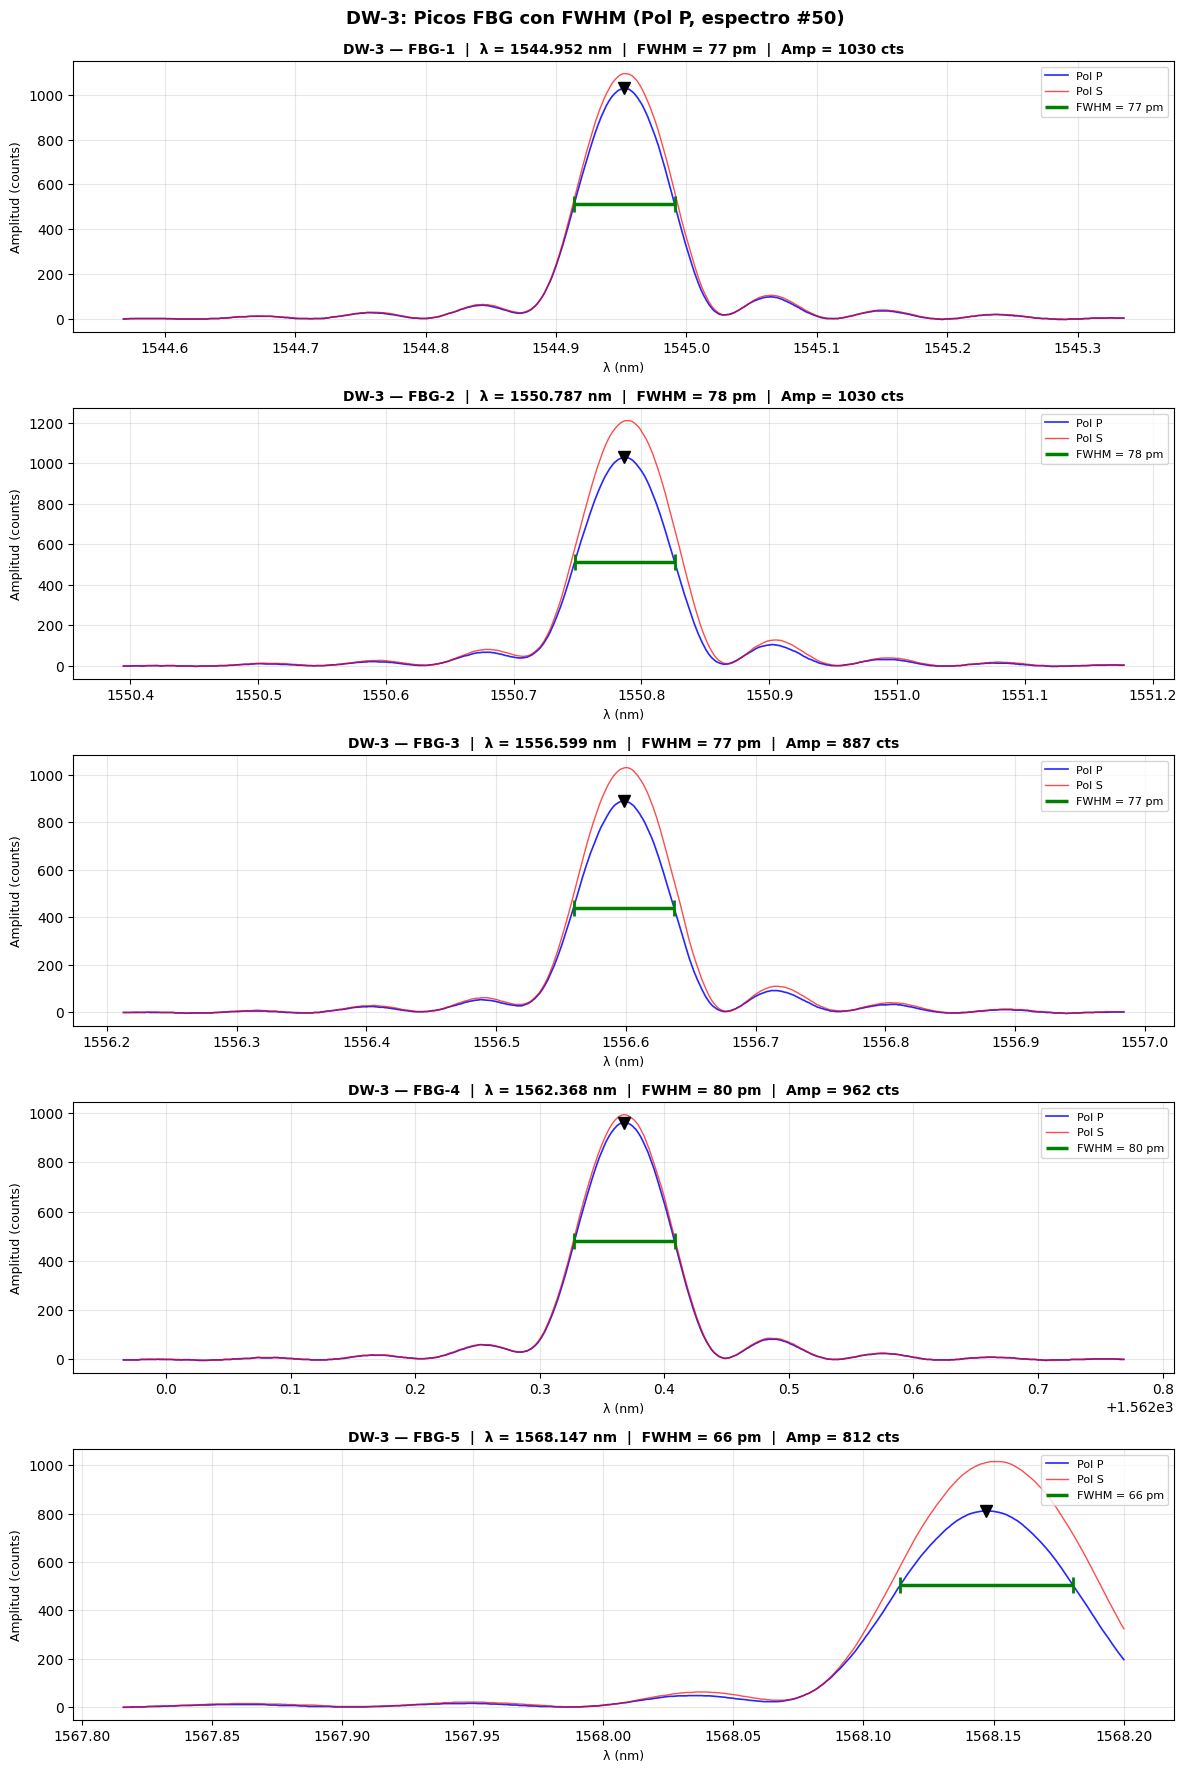

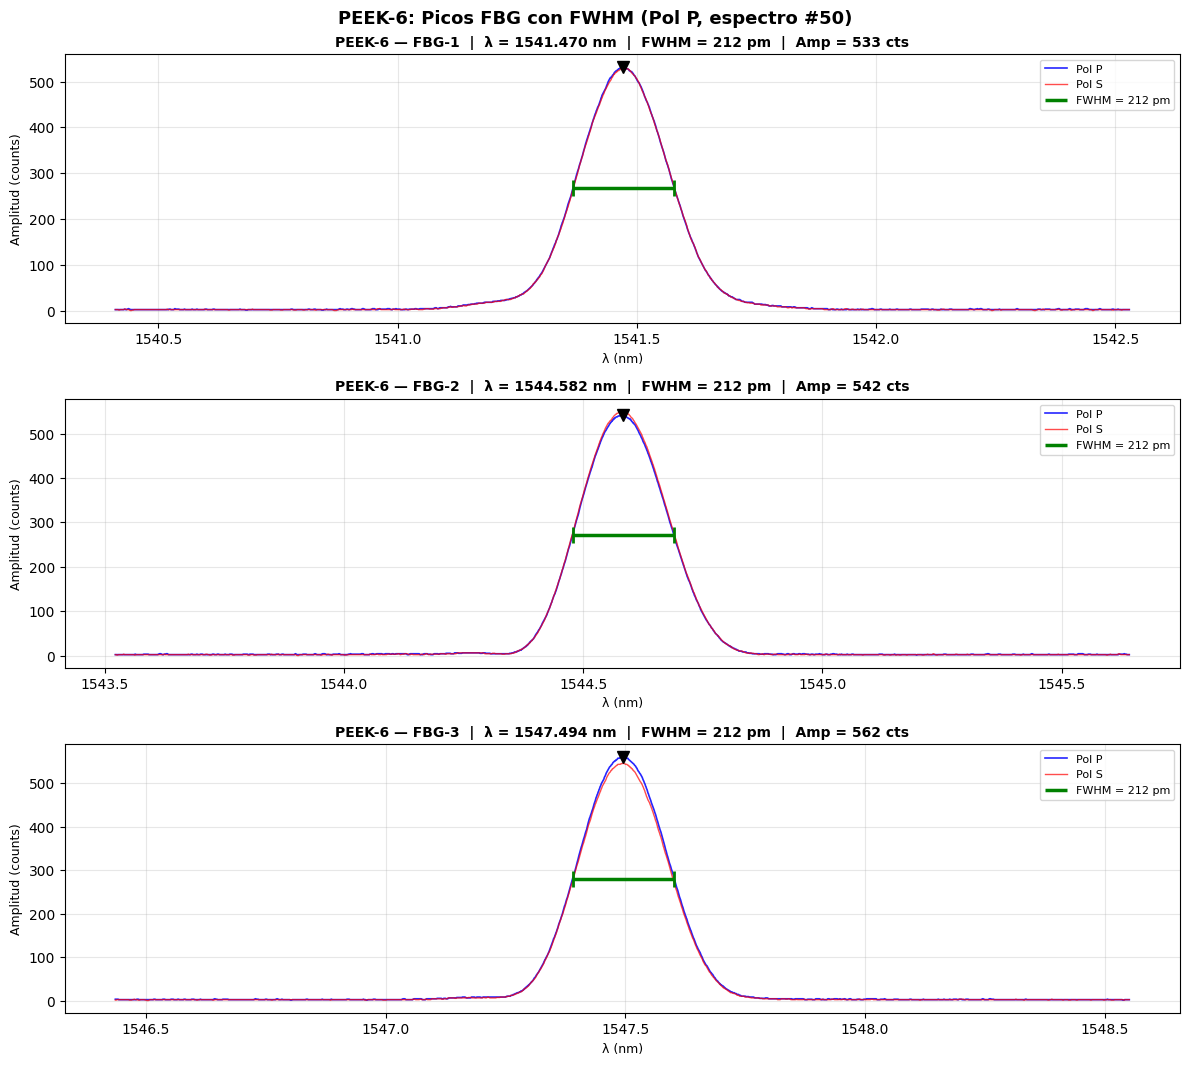

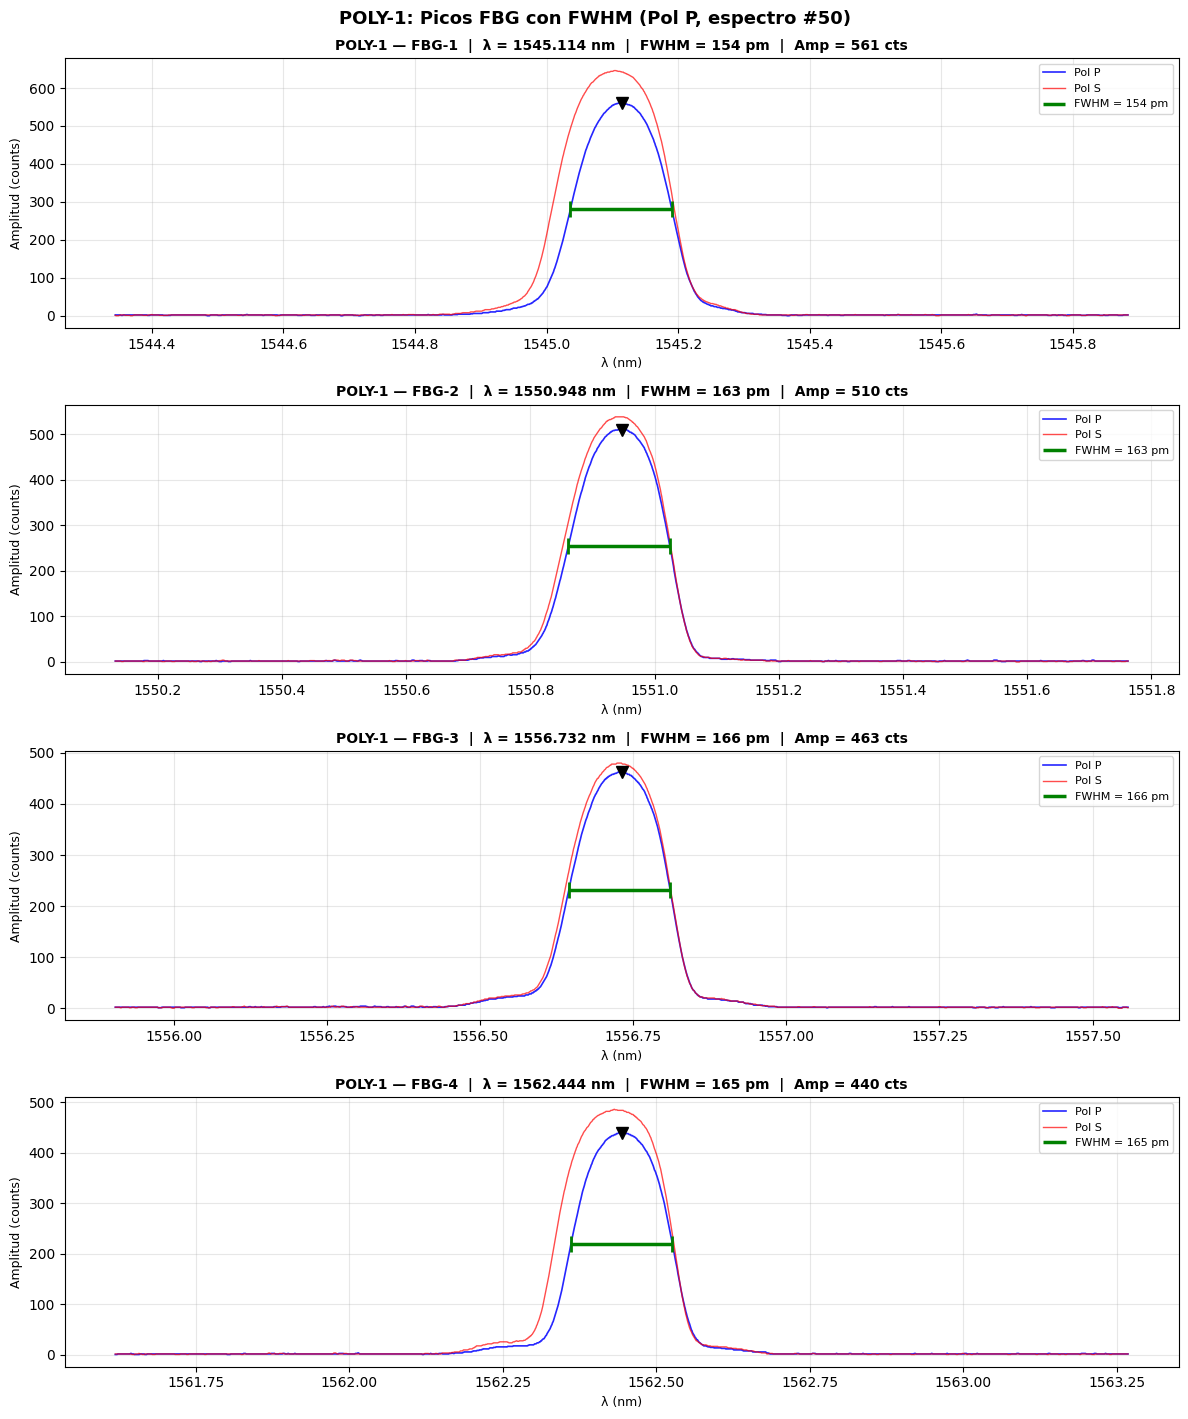


✅ Análisis de picos FBG completado para las 3 fibras
   Incluye FWHM en puntos y pm, espaciado en nm, y plots con marcadores FWHM


In [11]:
# Función para detectar picos FBG
def find_all_fbg_peaks(signal, min_prominence_factor=0.10, min_distance=50, min_height_factor=0.05):
    """
    Detecta todos los picos FBG en una señal de espectro.
    Retorna lista de dicts con peak_idx, fwhm (pts), amplitude, etc.
    """
    sig_max = signal.max()
    height = sig_max * min_height_factor
    prominence = sig_max * min_prominence_factor

    peaks, properties = find_peaks(signal, prominence=prominence,
                                   distance=min_distance, height=height)

    if len(peaks) == 0:
        return []

    results = []
    widths, w_heights, left_ips, right_ips = peak_widths(signal, peaks, rel_height=0.5)

    for i, peak_idx in enumerate(peaks):
        results.append({
            'peak_idx': peak_idx,
            'fwhm': widths[i],
            'amplitude': signal[peak_idx],
            'left_ip': left_ips[i],
            'right_ip': right_ips[i],
            'width_height': w_heights[i]
        })

    return results

# ══════════════════════════════════════════════════════════════════════
# Analizar cada canal + FWHM plot
# ══════════════════════════════════════════════════════════════════════
if data_spectrum is not None:
    fbg_analysis_results = {}

    # Conversión pts → pm (definida en esta celda para autonomía)
    _dlam_pm = _dlam * 1e3   # nm/pt → pm/pt (≈ 1.0 pm/pt)

    for ch in range(n_channels_available):
        fiber_name = channel_names.get(ch, f'Canal-{ch}')
        print(f"\n{'='*90}")
        print(f"📊 Análisis de {fiber_name} (Canal {ch})")
        print(f"{'='*90}")

        fbg_analysis_results[fiber_name] = {}

        for pol_idx in range(n_pol):
            pol_name = pol_labels[pol_idx]
            signal = spectrum_wav[idx_espectro, pol_idx, ch, :]
            peaks = find_all_fbg_peaks(signal)

            fbg_analysis_results[fiber_name][pol_name] = peaks

            print(f"\n  {pol_name}: {len(peaks)} picos FBG detectados")
            print(f"  {'#':<6} {'idx':>6} {'λ_B (nm)':>10} {'FWHM (pts)':>11} {'FWHM (pm)':>10} {'Amp (cts)':>10}")
            print(f"  {'─'*58}")
            for i, peak in enumerate(peaks, 1):
                lam = wavelength_axis[peak['peak_idx']]
                fwhm_pm = peak['fwhm'] * _dlam_pm
                print(f"  FBG-{i:<2} {peak['peak_idx']:>6d} {lam:>10.3f} {peak['fwhm']:>11.2f} "
                      f"{fwhm_pm:>10.1f} {peak['amplitude']:>10.0f}")

            # Calcular espaciado entre sensores
            if len(peaks) > 1:
                print(f"\n  Espaciado entre sensores ({pol_name}):")
                for i in range(len(peaks) - 1):
                    sp = peaks[i+1]['peak_idx'] - peaks[i]['peak_idx']
                    sp_nm = sp * _dlam
                    print(f"    FBG-{i+1} → FBG-{i+2}: {sp} pts = {sp_nm:.3f} nm")

    # ── Explicación: ¿por qué medimos FWHM en puntos? ────────────────
    print(f"\n{'─'*90}")
    print(f"📐 ¿POR QUÉ scipy.signal.peak_widths REPORTA FWHM EN PUNTOS?")
    print(f"{'─'*90}")
    print(f"  peak_widths trabaja con el array de amplitud indexado por muestra (no por λ).")
    print(f"  Internamente interpola entre muestras discretas para hallar los cruces a mitad")
    print(f"  de altura (rel_height=0.5 → −3 dB). El resultado está en PUNTOS (samples).")
    print(f"")
    print(f"  Conversión a unidades físicas:")
    print(f"    FWHM (pm) = FWHM (pts) × Δλ (pm/pt)")
    print(f"    Δλ = {_lam_end-_lam_start:.1f} nm / {n_puntos-1} pts = {_dlam*1e3:.3f} pm/pt")
    print(f"")
    print(f"  En este interrogador, Δλ ≈ 1 pm/pt, así que numéricamente FWHM(pts) ≈ FWHM(pm).")
    print(f"  Más adelante (§6) usamos compute_bandwidth_pm() en dB, que es más preciso.")

    # ══════════════════════════════════════════════════════════════════════
    # PLOT: FWHM visualización por fibra (zoomed peaks con FWHM markers)
    # ══════════════════════════════════════════════════════════════════════
    print(f"\n📊 Plot de picos con marcadores de FWHM:")

    for ch in range(n_channels_available):
        fiber_name = channel_names.get(ch, f'Canal-{ch}')
        peaks_p = fbg_analysis_results[fiber_name]['Pol P']
        n_peaks = len(peaks_p)

        if n_peaks == 0:
            continue

        # Una fila por sensor, vertical stacking
        fig, axes = plt.subplots(n_peaks, 1, figsize=(12, 3.5 * n_peaks), squeeze=False)

        signal_p = spectrum_wav[idx_espectro, 0, ch, :]
        signal_s = spectrum_wav[idx_espectro, 1, ch, :]

        for i, peak in enumerate(peaks_p):
            ax = axes[i, 0]
            pidx = peak['peak_idx']
            fw = peak['fwhm']
            fwhm_pm = fw * _dlam_pm

            # Zoom: ±5× FWHM alrededor del pico
            zoom = max(int(fw * 5), 200)
            x0 = max(0, pidx - zoom)
            x1 = min(n_puntos, pidx + zoom)
            x_nm = wavelength_axis[x0:x1]

            ax.plot(x_nm, signal_p[x0:x1], 'b-', linewidth=1.2, alpha=0.85, label='Pol P')
            ax.plot(x_nm, signal_s[x0:x1], 'r-', linewidth=1.0, alpha=0.7, label='Pol S')

            # Marcadores de FWHM (half-max horizontal line)
            half_amp = peak['width_height']
            left_nm = wavelength_axis[0] + peak['left_ip'] * _dlam
            right_nm = wavelength_axis[0] + peak['right_ip'] * _dlam
            lam_pk = wavelength_axis[pidx]

            ax.hlines(half_amp, left_nm, right_nm, color='green', linewidth=2.5,
                      linestyle='-', label=f'FWHM = {fwhm_pm:.0f} pm', zorder=5)
            ax.plot([left_nm, right_nm], [half_amp, half_amp], 'g|', markersize=12,
                    markeredgewidth=2, zorder=6)

            # Peak marker
            ax.plot(lam_pk, signal_p[pidx], 'kv', markersize=8, zorder=7)

            ax.set_title(f'{fiber_name} — FBG-{i+1}  |  λ = {lam_pk:.3f} nm  |  '
                         f'FWHM = {fwhm_pm:.0f} pm  |  Amp = {peak["amplitude"]:.0f} cts',
                         fontsize=10, fontweight='bold')
            ax.set_xlabel('λ (nm)', fontsize=9)
            ax.set_ylabel('Amplitud (counts)', fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, loc='upper right')

        plt.tight_layout()
        plt.suptitle(f'{fiber_name}: Picos FBG con FWHM (Pol P, espectro #{idx_espectro})',
                     fontsize=13, y=1.01, fontweight='bold')
        plt.show()

    print(f"\n{'='*90}")
    print("✅ Análisis de picos FBG completado para las 3 fibras")
    print(f"   Incluye FWHM en puntos y pm, espaciado en nm, y plots con marcadores FWHM")

## 6️⃣ Análisis de Calidad v2: Métricas con Sentido Físico

### 📡 Interrogador FAZT I4G-16 — Especificaciones Relevantes

| Parámetro | Valor |
|-----------|-------|
| Rango λ | 1529.0 – 1568.2 nm (39.2 nm) |
| Resolución | 1 pm (= 1 punto del espectro) |
| P láser / canal | +0 a +3 dBm (típico ~2 dBm) |
| Rango dinámico | > 30 dB óptico |
| Ganancia receptor | 4 niveles, 12 dB total |
| FWHM soportado | 40 pm – 1.5 nm |
| Repetibilidad | < 0.05 pm (σ, 10s, FWHM=100pm, P_peak=−15dBm) |
| Polarizaciones | 2 (P y S), conmutadas por barrido |

### 🔬 Métricas Calculadas

**SNR (Signal-to-Noise Ratio):**
$$\text{SNR (dB)} = 10 \cdot \log_{10}\left(\frac{\text{Amplitud pico}}{\text{Baseline local}}\right)$$
- Mide cuánto sobresale el pico del ruido. **NO es reflectividad absoluta.**

> **Nota sobre SNR > 30 dB:** Algunos sensores (DW-3) presentan SNR cercano o superior a 30 dB, que es el rango dinámico especificado del interrogador. Esto **no indica saturación** ni limitación de rango dinámico: el spec de "> 30 dB" es un mínimo garantizado por el fabricante. Un SNR alto es simplemente indicativo de picos bien definidos con bajo ruido de fondo.

**SLSR (Side-Lobe Suppression Ratio) — adaptativo al FWHM:**
$$\text{SLSR (dB)} = 10 \cdot \log_{10}\left(\frac{\text{Pico principal}}{\text{Max lóbulo lateral}}\right)$$
- **Inner guard = 1.5 × FWHM** | **Outer guard = min(spacing/2, 4.0 nm)**

**Ancho de banda multi-nivel:**
- **BW@3dB = FWHM** (pm) | **BW@20dB** (pm) | **Shape Factor = BW@20dB / BW@3dB**

**SAR (Shape Asymmetry Ratio):**
$$\text{SAR (\%)} = \frac{|W_{\text{izq}} - W_{\text{der}}|}{W_{\text{izq}} + W_{\text{der}}} \times 100$$

**Cross-polarización:** Birrefringencia = |λ_P − λ_S| (pm) | PDL = 10·log₁₀(Amp_max/Amp_min) (dB)

### ✅ Criterios de Aceptación QC

| Métrica | Criterio | Justificación |
|---------|----------|---------------|
| SNR | > 25 dB | Margen suficiente sobre el ruido del interrogador |
| SLSR | > 15 dB | Lóbulos laterales bien suprimidos |
| SAR | < 10% | Simetría aceptable del perfil espectral |
| SF | < 5.0 | Forma no excesivamente extendida |
| IL | < 1.5 dB | Pérdida acumulativa limitada a lo largo de la fibra |
| **FWHM** | **< 100 pm** | Pico suficientemente estrecho para resolución del interrogador |
| **L (longitud)** | **> 10 mm** | Grating físicamente largo para buena reflectividad y selectividad |

### ⚠️ ¿Se puede calcular reflectividad absoluta?

**No, con los datos que tenemos no es posible calcular la reflectividad absoluta $R(\lambda)$.**

La reflectividad absoluta requiere:
$$R(\lambda) = \frac{P_{\text{reflejada}}(\lambda)}{P_{\text{incidente}}(\lambda)}$$

Aunque conocemos $P_{\text{láser}} \approx 2\,\text{dBm}$, **no conocemos** el presupuesto óptico completo entre el láser y cada FBG:
- Pérdidas de los conectores y empalmes
- Atenuación de fibra antes de cada FBG (acumulativa)
- Factor de conversión exacto del fotodetector (cuentas del ADC → dBm)
- Ganancia real del receptor (sabemos que está en "base", pero no el valor absoluto)

El interrogador devuelve cuentas del ADC, no potencia calibrada en dBm. Sin una **referencia calibrada** (espejo, fibra terminada en loop, o FBG de reflectividad conocida) o **espectros en transmisión** ($R = 1 - T$ si pérdidas ≈ 0), es imposible.

**Lo que SÍ podemos calcular:**
- **SNR relativo**: pico / baseline_local (ya lo tenemos)
- **Reflectividad relativa** entre FBGs de la misma fibra: $R_1/R_2 \approx A_1/A_2$ (misma $P_{\text{in}}$ y gain)
- **Insertion Loss acumulativa** entre sensores consecutivos: diferencia de baseline entre sensores

In [12]:
if data_spectrum is not None:
    # ══════════════════════════════════════════════════════════════════════
    # Configuración v2: Specs del interrogador FAZT I4G-16 + diseño fibras
    # ══════════════════════════════════════════════════════════════════════

    # --- Interrogador FAZT I4G-16 (Femto Sensing International) ---
    LAMBDA_START_NM  = 1529.0    # nm — inicio del rango de escaneo
    LAMBDA_END_NM    = 1568.2    # nm — fin del rango de escaneo
    LASER_POWER_DBM  = 2.0       # dBm — potencia típica por canal (+0 a +3 dBm)
    DYNAMIC_RANGE_DB = 30.0      # dB — rango dinámico óptico (>30 dB)
    RECEIVER_GAIN_DB = 12.0      # dB — rango de ganancia (4 niveles programables)
    EDGE_MARGIN_PTS  = 200       # pts — margen para excluir artefactos de borde

    # --- Resolución espectral ---
    # CORRECCIÓN: Rango = 39.2 nm, Puntos = 39200 → exactamente 1 pm/pt
    dlam_nm_per_pt = (LAMBDA_END_NM - LAMBDA_START_NM) / n_puntos  # 0.001 nm/pt = 1 pm/pt

    # --- Diseño de fibras ---
    DESIGN_SPACING = {
        'DW-3':    5.8,   # nm entre gratings — confirmado
        'PEEK-6':  3.0,   # nm — confirmado
        'POLY-1':  5.8    # nm — ESTIMADO desde picos detectados (similar a DW-3)
    }

    # POLY-1: NO tenemos wavelengths de diseño del fabricante.
    # Tiene 4 sensores visibles + un 5º fuera del rango del interrogador a T ambiente.
    # Las longitudes de onda de diseño se determinan de los picos detectados.
    DESIGN_WAVELENGTHS = {
        'DW-3':    [1545.0, 1550.8, 1556.6, 1562.4],  # 4 sensores — confirmado
        'PEEK-6':  [1530.0, 1533.0, 1536.0],           # 3 sensores — confirmado
        'POLY-1':  []  # DESCONOCIDO — se rellenará desde picos detectados
    }

    DESIGN_N_SENSORS = {
        'DW-3':    4,
        'PEEK-6':  3,
        'POLY-1':  4   # 4 visibles en rango (5º fuera a T_amb)
    }

    # --- Thresholds de calidad ---
    SNR_THRESH_DB       = 25.0    # dB — mínimo SNR aceptable
    SLSR_THRESH_DB      = 15.0    # dB — mínimo SLSR (no apodizado: ~13 dB teórico)
    SAR_THRESH_PCT      = 10.0    # %  — máximo asimetría
    IL_TOTAL_THRESH_DB  = 1.5     # dB — insertion loss acumulativa máxima
    FWHM_THRESH_PM      = 100.0   # pm — máximo FWHM aceptable
    L_THRESH_MM         = 10.0    # mm — mínima longitud de grating

    print("✅ Configuración v2 (con specs del interrogador FAZT I4G-16):")
    print(f"\n   📡 INTERROGADOR:")
    print(f"   • Rango: {LAMBDA_START_NM}–{LAMBDA_END_NM} nm ({LAMBDA_END_NM-LAMBDA_START_NM:.1f} nm)")
    print(f"   • Resolución: {dlam_nm_per_pt:.4f} nm/pt = {dlam_nm_per_pt*1e3:.2f} pm/pt")
    print(f"   • Puntos por espectro: {n_puntos}")
    print(f"   • P_laser ≈ {LASER_POWER_DBM} dBm | Rango dinámico > {DYNAMIC_RANGE_DB:.0f} dB")
    print(f"   • Ganancia del receptor: {RECEIVER_GAIN_DB:.0f} dB (4 niveles)")
    print(f"\n   🔧 FIBRAS:")
    for fn in ['DW-3', 'PEEK-6', 'POLY-1']:
        n = DESIGN_N_SENSORS[fn]
        sp = DESIGN_SPACING[fn]
        wls = DESIGN_WAVELENGTHS[fn]
        if wls:
            wls_str = ', '.join(f'{w:.1f}' for w in wls)
        else:
            wls_str = 'DESCONOCIDO (se determinarán de picos)'
        note = ''
        if fn == 'POLY-1':
            note = ' ← 5º sensor fuera de rango a T_amb'
        print(f"   • {fn}: {n} sensores, spacing ≈ {sp:.1f} nm  [{wls_str}]{note}")
    print(f"\n   ✅ THRESHOLDS:")
    print(f"   • SNR > {SNR_THRESH_DB:.0f} dB | SLSR > {SLSR_THRESH_DB:.0f} dB")
    print(f"   • SAR < {SAR_THRESH_PCT:.0f}% | IL_total < {IL_TOTAL_THRESH_DB:.1f} dB")
    print(f"   • FWHM < {FWHM_THRESH_PM:.0f} pm | L > {L_THRESH_MM:.0f} mm")

✅ Configuración v2 (con specs del interrogador FAZT I4G-16):

   📡 INTERROGADOR:
   • Rango: 1529.0–1568.2 nm (39.2 nm)
   • Resolución: 0.0010 nm/pt = 1.00 pm/pt
   • Puntos por espectro: 39200
   • P_laser ≈ 2.0 dBm | Rango dinámico > 30 dB
   • Ganancia del receptor: 12 dB (4 niveles)

   🔧 FIBRAS:
   • DW-3: 4 sensores, spacing ≈ 5.8 nm  [1545.0, 1550.8, 1556.6, 1562.4]
   • PEEK-6: 3 sensores, spacing ≈ 3.0 nm  [1530.0, 1533.0, 1536.0]
   • POLY-1: 4 sensores, spacing ≈ 5.8 nm  [DESCONOCIDO (se determinarán de picos)] ← 5º sensor fuera de rango a T_amb

   ✅ THRESHOLDS:
   • SNR > 25 dB | SLSR > 15 dB
   • SAR < 10% | IL_total < 1.5 dB
   • FWHM < 100 pm | L > 10 mm


In [13]:
if data_spectrum is not None:
    # ══════════════════════════════════════════════════════════════════════
    # Funciones de análisis de calidad FBG v2
    # SLSR adaptativo al FWHM, ancho de banda multi-nivel, specs I4G-16
    # ══════════════════════════════════════════════════════════════════════

    # ── Conversión índice ↔ longitud de onda ──────────────────────────
    def idx_to_wavelength(idx):
        """Convierte índice del espectro a longitud de onda (nm)."""
        return LAMBDA_START_NM + idx * dlam_nm_per_pt

    def wavelength_to_idx(lam_nm):
        """Convierte longitud de onda (nm) a índice del espectro."""
        return int(round((lam_nm - LAMBDA_START_NM) / dlam_nm_per_pt))

    # ── Baseline ──────────────────────────────────────────────────────
    def global_baseline(signal, pct=5):
        """Noise floor global: percentil p-ésimo del espectro completo."""
        bl = float(np.percentile(signal, pct))
        if bl <= 0:
            pos = signal[signal > 0]
            bl = float(np.min(pos)) if len(pos) > 0 else 1.0
        return bl

    def local_baseline(signal, peak_idx, half_window_nm=5.0, fwhm_pts=None):
        """
        Mínimo del valle alrededor del pico, excluyendo la zona central.
        Guard zone = 2× FWHM (se adapta al ancho real del pico).
        """
        guard_nm = max(2.0 * (fwhm_pts if fwhm_pts else 100) * dlam_nm_per_pt, 0.2)
        hw  = max(int(half_window_nm / dlam_nm_per_pt), 1)
        grd = max(int(guard_nm / dlam_nm_per_pt), 1)
        i0 = max(0, peak_idx - hw)
        i1 = min(len(signal), peak_idx + hw + 1)

        region = signal[i0:i1]
        mask = np.ones(len(region), dtype=bool)
        gs = max(0, peak_idx - grd - i0)
        ge = min(len(region), peak_idx + grd + 1 - i0)
        mask[gs:ge] = False

        gb = global_baseline(signal)
        if not mask.any():
            return gb

        vals = region[mask]
        pos = vals[vals > 0]
        return float(np.min(pos)) if len(pos) > 0 else gb

    # ── SNR ────────────────────────────────────────────────────────────
    def compute_snr_db(signal, peak_idx, fwhm_pts=None):
        """
        SNR = 10·log₁₀(peak / baseline_local) en dB.
        NO es reflectividad absoluta (necesitaríamos potencia incidente calibrada).
        Returns: (snr_db, baseline_value)
        """
        bl = local_baseline(signal, peak_idx, fwhm_pts=fwhm_pts)
        if bl > 0 and signal[peak_idx] > 0:
            return 10.0 * np.log10(signal[peak_idx] / bl), bl
        return np.nan, bl

    # ── SLSR (Side-Lobe Suppression Ratio) — adaptativo al FWHM ──────
    def compute_slsr_db(signal, peak_idx, fwhm_pts, design_spacing_nm=5.8):
        """
        SLSR con ventana de búsqueda adaptativa:
          - Inner guard = 1.5 × FWHM (excluye la cola del pico principal)
          - Outer guard = min(spacing/2, 4.0) nm (no alcanza pico vecino)
        Returns: (slsr_db, slsr_ratio, dist_nm, sidelobe_amp)
        """
        fwhm_nm = fwhm_pts * dlam_nm_per_pt
        inner_nm = max(1.5 * fwhm_nm, 0.1)
        outer_nm = min(design_spacing_nm / 2.0, 4.0)

        if inner_nm >= outer_nm:
            inner_nm = outer_nm * 0.3

        inner_pts = max(int(inner_nm / dlam_nm_per_pt), 1)
        outer_pts = max(int(outer_nm / dlam_nm_per_pt), 1)

        ls = max(0, peak_idx - outer_pts)
        le = max(0, peak_idx - inner_pts)
        rs = min(len(signal), peak_idx + inner_pts + 1)
        re = min(len(signal), peak_idx + outer_pts + 1)

        lr = signal[ls:le] if le > ls else np.array([])
        rr = signal[rs:re] if re > rs else np.array([])

        if len(lr) == 0 and len(rr) == 0:
            return np.nan, np.nan, np.nan, np.nan

        ml = np.max(lr) if len(lr) > 0 else 0
        mr = np.max(rr) if len(rr) > 0 else 0

        if ml >= mr and len(lr) > 0:
            max_sl, sl_idx = ml, ls + int(np.argmax(lr))
        elif len(rr) > 0:
            max_sl, sl_idx = mr, rs + int(np.argmax(rr))
        else:
            return np.nan, np.nan, np.nan, np.nan

        pk = signal[peak_idx]
        if max_sl <= 0 or pk <= 0:
            return np.nan, np.nan, np.nan, np.nan

        ratio = pk / max_sl
        slsr_db = 10.0 * np.log10(ratio)
        dist_nm = abs(sl_idx - peak_idx) * dlam_nm_per_pt

        return slsr_db, ratio, dist_nm, max_sl

    # ── Ancho de banda a N dB ─────────────────────────────────────────
    def compute_bandwidth_pm(signal, peak_idx, level_db=3.0):
        """
        Ancho de banda a level_db dB por debajo del pico.
        3 dB = FWHM (mitad de potencia); 20 dB = al 1% del pico.
        Usa interpolación lineal para precisión sub-punto.
        Returns: (bw_pm, left_interp_idx, right_interp_idx)
        """
        pk = signal[peak_idx]
        if pk <= 0:
            return np.nan, np.nan, np.nan

        thr = pk * 10**(-level_db / 10.0)

        # Buscar cruce por la izquierda
        li = peak_idx
        while li > 0 and signal[li] > thr:
            li -= 1
        if li < peak_idx and signal[li + 1] != signal[li]:
            left = li + (thr - signal[li]) / (signal[li + 1] - signal[li])
        else:
            left = float(li)

        # Buscar cruce por la derecha
        ri = peak_idx
        while ri < len(signal) - 1 and signal[ri] > thr:
            ri += 1
        if ri > peak_idx and signal[ri - 1] != signal[ri]:
            right = ri - (thr - signal[ri]) / (signal[ri - 1] - signal[ri])
        else:
            right = float(ri)

        bw_pm = (right - left) * dlam_nm_per_pt * 1e3
        return bw_pm, left, right

    # ── Asimetría del pico (SAR) — legacy ─────────────────────────────
    def compute_sar(signal, peak_idx):
        """
        Shape Asymmetry Ratio a nivel half-prominence (legacy).
        SAR = |W_izq - W_der| / (W_izq + W_der) × 100%
        """
        try:
            _, _, lip, rip = peak_widths(signal, [peak_idx], rel_height=0.5)
            wl = peak_idx - lip[0]
            wr = rip[0] - peak_idx
            tot = wl + wr
            return 100.0 * abs(wl - wr) / tot if tot > 0 else np.nan
        except Exception:
            return np.nan

    # ── Asimetría a nivel arbitrario en dB ────────────────────────────
    def compute_sar_at_db(signal, peak_idx, level_db):
        """
        SAR a nivel arbitrario expresado en dB bajo el pico.
          level_db = 0.458 → 90% de amplitud pico (-10·log₁₀(0.9))
          level_db = 3.010 → 50% de amplitud pico (-10·log₁₀(0.5) ≈ FWHM)

        Usa compute_bandwidth_pm para encontrar los cruces izq/der
        con interpolación lineal sub-punto, luego calcula:
          SAR = |W_izq - W_der| / (W_izq + W_der) × 100%

        Returns: (sar_pct, w_left_pm, w_right_pm)
        """
        bw, left, right = compute_bandwidth_pm(signal, peak_idx, level_db)
        if np.isnan(bw):
            return np.nan, np.nan, np.nan
        w_left  = (peak_idx - left)  * dlam_nm_per_pt * 1e3  # pm
        w_right = (right - peak_idx) * dlam_nm_per_pt * 1e3  # pm
        total = w_left + w_right
        if total <= 0:
            return np.nan, w_left, w_right
        sar = 100.0 * abs(w_left - w_right) / total
        return sar, w_left, w_right

    # ── Longitud física del FBG ───────────────────────────────────────
    def compute_fbg_length_mm(fwhm_pts, lambda_bragg_nm=1550.0, n_eff=1.45):
        """
        L ≈ (n_g × λ_B²) / (2 × Δλ)
        con n_g ≈ n_eff = 1.45 (aproximación simplificada).
        Para FBGs cortos (L < 1 mm), la fórmula pierde precisión.
        """
        fwhm_nm = fwhm_pts * dlam_nm_per_pt
        if fwhm_nm <= 0:
            return np.nan
        return (n_eff * lambda_bragg_nm**2) / (2.0 * fwhm_nm * 1e6)

    print("✅ Funciones de análisis v2 definidas:")
    print(f"   Resolución: {dlam_nm_per_pt*1e3:.2f} pm/pt | Rango: {LAMBDA_START_NM}–{LAMBDA_END_NM} nm")
    print("   • idx_to_wavelength()      : Índice → λ (nm)")
    print("   • global_baseline()        : Noise floor (5th percentile)")
    print("   • local_baseline()         : Valley minimum (guard = 2×FWHM)")
    print("   • compute_snr_db()         : SNR pico/baseline (dB)")
    print("   • compute_slsr_db()        : SLSR adaptativo (inner = 1.5×FWHM)")
    print("   • compute_bandwidth_pm()   : BW a N dB (3dB, 20dB)")
    print("   • compute_sar()            : SAR a nivel half-prominence (legacy)")
    print("   • compute_sar_at_db()      : SAR a nivel arbitrario en dB (90%, 50%)")
    print("   • compute_fbg_length_mm()  : Longitud FBG (mm)")

✅ Funciones de análisis v2 definidas:
   Resolución: 1.00 pm/pt | Rango: 1529.0–1568.2 nm
   • idx_to_wavelength()      : Índice → λ (nm)
   • global_baseline()        : Noise floor (5th percentile)
   • local_baseline()         : Valley minimum (guard = 2×FWHM)
   • compute_snr_db()         : SNR pico/baseline (dB)
   • compute_slsr_db()        : SLSR adaptativo (inner = 1.5×FWHM)
   • compute_bandwidth_pm()   : BW a N dB (3dB, 20dB)
   • compute_sar()            : SAR a nivel half-prominence (legacy)
   • compute_sar_at_db()      : SAR a nivel arbitrario en dB (90%, 50%)
   • compute_fbg_length_mm()  : Longitud FBG (mm)


In [14]:
if data_spectrum is not None:
    # ══════════════════════════════════════════════════════════════════════
    # Análisis de calidad v2: métricas por sensor + cross-polarización
    # ══════════════════════════════════════════════════════════════════════

    quality_results = {}
    cross_pol = {}

    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in fbg_analysis_results:
            continue

        ch = list(channel_names.values()).index(fiber_name)
        quality_results[fiber_name] = {}
        cross_pol[fiber_name] = {}
        spacing_nm = DESIGN_SPACING[fiber_name]
        n_design = DESIGN_N_SENSORS[fiber_name]

        print(f"\n{'='*120}")
        print(f"📊 {fiber_name} — Canal {ch} — Espectro #{idx_espectro}")
        print(f"   Diseño: {n_design} sensores, spacing = {spacing_nm:.1f} nm")
        print(f"{'='*120}")

        for pol_idx, pol_name in enumerate(pol_labels):
            peaks = fbg_analysis_results[fiber_name][pol_name]
            if len(peaks) == 0:
                continue

            signal = spectrum_wav[idx_espectro, pol_idx, ch, :]

            # ── Filtrar artefactos de borde ──
            valid_peaks = []
            for p in peaks:
                if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS):
                    valid_peaks.append(p)
                else:
                    lam = idx_to_wavelength(p['peak_idx'])
                    print(f"  ⚠️  Pico idx={p['peak_idx']} (λ={lam:.3f} nm) EXCLUIDO — artefacto de borde")

            n_valid = len(valid_peaks)
            if n_valid != n_design:
                print(f"  ⚠️  {pol_name}: {n_valid} picos válidos detectados (diseño: {n_design})")

            print(f"\n  {pol_name}: {n_valid} picos FBG válidos")
            hdr = (f"  {'#':<5} {'λ_B(nm)':>10} {'FWHM':>8} {'BW@20':>8} {'SF':>6} "
                   f"{'Amp':>8} {'SNR':>7} {'SLSR':>7} {'×':>6} "
                   f"{'d_SL':>7} {'SAR':>6} {'SAR90':>6} {'SAR50':>6} {'L':>6}")
            units = (f"  {'':>5} {'':>10} {'(pm)':>8} {'(pm)':>8} {'':>6} "
                     f"{'(cts)':>8} {'(dB)':>7} {'(dB)':>7} {'':>6} "
                     f"{'(nm)':>7} {'(%)':>6} {'(%)':>6} {'(%)':>6} {'(mm)':>6}")
            print(hdr)
            print(units)
            print(f"  {'─'*120}")

            for i, peak in enumerate(valid_peaks, 1):
                pidx = peak['peak_idx']
                fwhm_pts = peak['fwhm']
                amp = peak['amplitude']
                lam_b = idx_to_wavelength(pidx)

                # FWHM en pm
                fwhm_pm = fwhm_pts * dlam_nm_per_pt * 1e3

                # Ancho de banda a 3dB y 20dB
                bw3, _, _ = compute_bandwidth_pm(signal, pidx, level_db=3.0)
                bw20, _, _ = compute_bandwidth_pm(signal, pidx, level_db=20.0)
                sf = bw20 / bw3 if (bw3 and bw20 and not np.isnan(bw3)
                                    and not np.isnan(bw20) and bw3 > 0) else np.nan

                # SNR
                snr, bl = compute_snr_db(signal, pidx, fwhm_pts=fwhm_pts)

                # SLSR adaptativo
                slsr, slsr_r, d_sl, sl_amp = compute_slsr_db(
                    signal, pidx, fwhm_pts, spacing_nm)

                # SAR a múltiples niveles de amplitud
                sar = compute_sar(signal, pidx)  # half-prominence (legacy)
                sar_90, wl_90, wr_90 = compute_sar_at_db(signal, pidx, 0.458)  # 90% amp
                sar_50, wl_50, wr_50 = compute_sar_at_db(signal, pidx, 3.010)  # 50% amp

                # Longitud FBG
                l_mm = compute_fbg_length_mm(fwhm_pts, lam_b)

                # Almacenar
                quality_results[fiber_name][(i, pol_name)] = {
                    'peak_idx': pidx, 'lambda_nm': lam_b,
                    'peak_amp': amp, 'baseline_loc': bl,
                    'fwhm_pts': fwhm_pts, 'fwhm_pm': fwhm_pm,
                    'bw_3db_pm': bw3, 'bw_20db_pm': bw20, 'shape_factor': sf,
                    'snr_db': snr,
                    'slsr_db': slsr, 'slsr_ratio': slsr_r,
                    'sidelobe_dist_nm': d_sl,
                    'sidelobe_amp': sl_amp if not np.isnan(slsr) else np.nan,
                    'sar_pct': sar,
                    'sar_90_pct': sar_90,
                    'sar_50_pct': sar_50,
                    'fbg_length_mm': l_mm,
                }

                def f(v, fmt):
                    return fmt.format(v) if not (isinstance(v, float) and np.isnan(v)) else 'N/A'

                print(f"  FBG-{i:<2} {lam_b:>10.3f} {f(bw3,'{:>8.0f}')} "
                      f"{f(bw20,'{:>8.0f}')} {f(sf,'{:>6.2f}')} "
                      f"{amp:>8.0f} {f(snr,'{:>7.1f}')} {f(slsr,'{:>7.1f}')} "
                      f"{f(slsr_r,'{:>6.1f}')} {f(d_sl,'{:>7.2f}')} "
                      f"{f(sar,'{:>6.1f}')} {f(sar_90,'{:>6.1f}')} "
                      f"{f(sar_50,'{:>6.1f}')} {f(l_mm,'{:>6.1f}')}")

        # ── Cross-polarización ────────────────────────────────────────
        peaks_P = fbg_analysis_results[fiber_name].get('Pol P', [])
        peaks_S = fbg_analysis_results[fiber_name].get('Pol S', [])
        valid_P = [p for p in peaks_P
                   if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]
        valid_S = [p for p in peaks_S
                   if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

        n_cross = min(len(valid_P), len(valid_S))
        if n_cross > 0:
            print(f"\n  Cross-polarización (P vs S):")
            print(f"  {'#':<5} {'λ_P(nm)':>10} {'λ_S(nm)':>10} {'Δλ(pm)':>8} "
                  f"{'Amp_P':>8} {'Amp_S':>8} {'PDL(dB)':>8}")
            print(f"  {'─'*60}")

            for i in range(n_cross):
                lam_P = idx_to_wavelength(valid_P[i]['peak_idx'])
                lam_S = idx_to_wavelength(valid_S[i]['peak_idx'])
                biref = abs(lam_P - lam_S) * 1e3  # pm
                amp_P = valid_P[i]['amplitude']
                amp_S = valid_S[i]['amplitude']
                pdl = (10.0 * np.log10(max(amp_P, amp_S) / min(amp_P, amp_S))
                       if min(amp_P, amp_S) > 0 else np.nan)

                cross_pol[fiber_name][i + 1] = {
                    'lambda_P': lam_P, 'lambda_S': lam_S,
                    'birefringence_pm': biref,
                    'pdl_db': pdl,
                    'amp_P': amp_P, 'amp_S': amp_S,
                    'lambda_mean': (lam_P + lam_S) / 2.0,
                }

                pdl_str = f"{pdl:>8.2f}" if not np.isnan(pdl) else f"{'N/A':>8}"
                print(f"  FBG-{i+1:<2} {lam_P:>10.3f} {lam_S:>10.3f} {biref:>8.1f} "
                      f"{amp_P:>8.0f} {amp_S:>8.0f} {pdl_str}")

        print(f"\n{'='*120}")

    # ── Resumen ───────────────────────────────────────────────────────
    print("\n✅ Análisis de calidad v2 completado")
    print("   Métricas por sensor:")
    print("   • λ_B (nm): longitud de onda de Bragg")
    print("   • FWHM (pm): ancho a -3dB = BW@3dB")
    print("   • BW@20dB (pm): ancho a -20dB (1% del pico)")
    print(f"   • SF = BW@20dB / FWHM: factor de forma (Gaussiana ≈ 3.0, sinc² ≈ 4.7)")
    print("   • SNR (dB) = 10·log₁₀(pico/baseline) — NO reflectividad absoluta")
    print("   • SLSR (dB): lóbulos buscados fuera de 1.5×FWHM, dentro de spacing/2")
    print("   • d_SL (nm): distancia del max lóbulo al centro")
    print("   • SAR (%): asimetría a nivel half-prominence (legacy)")
    print("   • SAR@90 (%): asimetría al 90% del pico (−0.46 dB)")
    print("   • SAR@50 (%): asimetría al 50% del pico (−3.0 dB)")
    print("   • L (mm): longitud estimada del grating")
    print("   Cross-pol:")
    print("   • Δλ (pm): birrefringencia |λ_P − λ_S|")
    print("   • PDL (dB): Polarization Dependent Loss = 10·log₁₀(max/min amp)")


📊 DW-3 — Canal 0 — Espectro #50
   Diseño: 4 sensores, spacing = 5.8 nm
  ⚠️  Pico idx=39146 (λ=1568.146 nm) EXCLUIDO — artefacto de borde

  Pol P: 4 picos FBG válidos
  #        λ_B(nm)     FWHM    BW@20     SF      Amp     SNR    SLSR      ×    d_SL    SAR  SAR90  SAR50      L
                       (pm)     (pm)           (cts)    (dB)    (dB)           (nm)    (%)    (%)    (%)   (mm)
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  FBG-1    1544.952       77      289   3.77     1030    30.1    10.4   11.0    0.12    0.2    1.0    0.2   22.5
  FBG-2    1550.786       78      221   2.83     1030    30.1    10.0   10.1    0.12    0.8    3.5    0.8   22.2
  FBG-3    1556.598       77      219   2.85      887    29.5     9.8    9.6    0.12    1.0    0.6    1.0   22.7
  FBG-4    1562.367       80      227   2.84      962    29.8    10.7   11.7    0.12    0.4    1.9    0.4   22.0
  ⚠️  Pico idx=39150 (λ=1568.15

In [15]:
if data_spectrum is not None:
    # ══════════════════════════════════════════════════════════════════════
    # 📖 METODOLOGÍA DE CÁLCULO DE PARÁMETROS FBG
    # Explicación detallada para referencia
    # ══════════════════════════════════════════════════════════════════════

    print("═" * 100)
    print("📖 METODOLOGÍA DE CÁLCULO DE PARÁMETROS FBG")
    print("═" * 100)

    print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║  1. FWHM (Full Width at Half Maximum) — Ancho a mitad de potencia           ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  Método: compute_bandwidth_pm(signal, peak_idx, level_db=3.0)                ║
║                                                                               ║
║  • Umbral = Pico × 10^(−3/10) = Pico × 0.5012 ≈ 50% de la potencia óptica  ║
║  • Se buscan los cruces izquierdo y derecho donde señal cruza este umbral    ║
║  • Interpolación lineal entre puntos adyacentes → precisión sub-pm           ║
║  • FWHM = (idx_der − idx_izq) × Δλ_por_punto × 1000  [pm]                  ║
║                                                                               ║
║  ⚠️  NO usamos scipy.peak_widths(rel_height=0.5):                            ║
║      Esa función mide a half-PROMINENCE (peak − 0.5×prominence),             ║
║      NO a mitad del pico (50% del máximo).                                    ║
║      Diferencia: <1% para SNR alto (DW-3), ~7% para POLY-1.                 ║
║                                                                               ║
║  → "¿Sigue siendo la anchura a mitad de altura?"                             ║
║    SÍ: mitad de POTENCIA del pico (−3 dB), definición estándar FBG.          ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

    print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║  2. BW@20dB — Ancho de banda a −20 dB                                        ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  Umbral = Pico × 10^(−20/10) = Pico × 0.01 = 1% de la potencia              ║
║  Mismo método de interpolación que FWHM pero a nivel más bajo.               ║
║                                                                               ║
║  ¿Por qué es relevante?                                                      ║
║  • Captura las "faldas" del pico: lóbulos laterales, colas asimétricas       ║
║  • Shape Factor SF = BW@20dB / FWHM indica la forma:                         ║
║    − SF ≈ 3.0 → perfil Gaussiano (grating apodizado o corto)                ║
║    − SF ≈ 4.7 → perfil sinc² (grating uniforme largo)                       ║
║    − SF > 5.0 → chirp significativo o lóbulos excesivos                      ║
║  • Útil para detectar defectos de escritura del grating                      ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

    print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║  3. POTENCIA DEL LÁSER (P_laser) — ¿Dónde entra en los cálculos?            ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  P_laser ≈ 2 dBm (FAZT I4G-16)                                               ║
║                                                                               ║
║  NO entra directamente. Trabajamos con CUENTAS del detector (ADC counts),    ║
║  no con potencia óptica absoluta.                                             ║
║                                                                               ║
║  La relación cuentas → potencia depende de:                                   ║
║    − Ganancia del receptor (4 niveles, hasta 12 dB)                          ║
║    − Responsividad del fotodetector (A/W)                                    ║
║    − Factor de transimpedancia y pérdidas de acoplamiento                    ║
║                                                                               ║
║  → SNR = 10·log₁₀(pico/baseline) — ratio relativo, no depende de P_laser    ║
║  → SLSR = 10·log₁₀(pico/sidelobe) — ratio relativo, tampoco depende         ║
║  → P_laser afecta INDIRECTAMENTE: más potencia = más cuentas = mejor         ║
║    resolución del ADC sobre el pico → menor ruido de cuantización            ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

    print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║  4. RANGO DINÁMICO — ¿Se utiliza?                                            ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  Rango dinámico > 30 dB (spec FAZT I4G-16)                                   ║
║                                                                               ║
║  NO se usa directamente en los cálculos.                                     ║
║  Es el TECHO del SNR medible por el instrumento:                              ║
║    − Si un FBG tiene SNR real = 40 dB, el instrumento solo puede medir       ║
║      hasta ~30 dB → limitación instrumental.                                  ║
║    − Nuestros SNR ≈ 27−30 dB → estamos cerca del límite.                    ║
║    → Si SNR ≈ 30 dB, el FBG podría tener SNR real mayor.                     ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

    print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║  5. REFLECTIVIDAD ABSOLUTA — ¿Se puede estimar?                              ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  NO, solo podemos estimar SNR (relativo).                                    ║
║                                                                               ║
║  R_absoluta = P_reflejada / P_incidente                                      ║
║  Necesitaríamos:                                                              ║
║    1) P_incidente: potencia que llega a cada FBG (descontando IL de los      ║
║       FBGs anteriores + pérdida de propagación)                              ║
║    2) Calibración absoluta del detector (cuentas → mW)                       ║
║    3) Conocimiento del acoplamiento fibra → interrogador                      ║
║                                                                               ║
║  → Para R absoluta: usar OSA + fuente broadband calibrada.                   ║
║  → El interrogador solo da amplitud en cuentas (∝ potencia reflejada).       ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

    fwhm_dw = 78   # pm típico DW-3
    fwhm_pl = 170  # pm típico POLY-1
    L_dw = 1.45 * 1550**2 / (2 * fwhm_dw * 1e-3 * 1e6)
    L_pl = 1.45 * 1550**2 / (2 * fwhm_pl * 1e-3 * 1e6)

    print(f"""
╔═══════════════════════════════════════════════════════════════════════════════╗
║  6. LONGITUD DEL GRATING (L_FBG)                                             ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  Fórmula:  L = (n_g × λ_B²) / (2 × Δλ_FWHM)                               ║
║                                                                               ║
║  Donde:                                                                       ║
║    n_g   = índice de grupo ≈ n_eff = 1.45  (aprox. simplificada)             ║
║    λ_B   = longitud de onda de Bragg (≈ 1550 nm)                             ║
║    Δλ    = FWHM en nm (= BW@3dB / 1000)                                     ║
║                                                                               ║
║  Nota sobre n_g:                                                              ║
║    n_g = n_eff − λ × dn/dλ ≈ 1.468 para SMF-28 a 1550 nm                   ║
║    Usamos n_eff = 1.45 → error ~ 1.2% (aceptable para estimación).          ║
║    Para fibras con coating especial (POLY), n_eff puede diferir.             ║
║                                                                               ║
║  Ejemplo:                                                                     ║
║    FWHM = {fwhm_dw} pm → L = {L_dw:.1f} mm  (DW-3 típico: grating largo)        ║
║    FWHM = {fwhm_pl} pm → L = {L_pl:.1f} mm  (POLY-1 típico: grating corto)       ║
║                                                                               ║
║  Limitaciones:                                                                ║
║    • Válida para FBGs uniformes (sin chirp)                                  ║
║    • Para FBGs apodizados, sobreestima L en ~10−20%                          ║
║    • Para L < 1 mm, pierde precisión                                          ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

    print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║  7. SAR (Shape Asymmetry Ratio) a múltiples niveles                          ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  SAR = |W_izq − W_der| / (W_izq + W_der) × 100%                             ║
║  W_izq = distancia del centro al borde izquierdo al nivel dado               ║
║  W_der = distancia del centro al borde derecho al nivel dado                  ║
║                                                                               ║
║  Tres niveles calculados:                                                     ║
║                                                                               ║
║  ● SAR (legacy): scipy peak_widths con half-prominence                       ║
║    Umbral = peak − 0.5 × prominence (depende de baseline)                    ║
║    → No reproducible entre instrumentos distintos                             ║
║                                                                               ║
║  ● SAR@90%: nivel −0.458 dB (90% de amplitud del pico)                       ║
║    Umbral = Pico × 0.9                                                        ║
║    → Asimetría en la PUNTA del pico                                           ║
║    → Sensible a desplazamientos de λ_B, distorsión de fase                   ║
║    → Más ruidoso (zona estrecha)                                              ║
║                                                                               ║
║  ● SAR@50%: nivel −3.01 dB (50% de amplitud = FWHM)                          ║
║    Umbral = Pico × 0.5                                                        ║
║    → Asimetría a mitad de potencia (estándar FBG)                             ║
║    → Indica gradiente de strain, defecto de escritura, chirp                  ║
║    → Más robusto que SAR@90%                                                  ║
║                                                                               ║
║  Interpretación combinada:                                                    ║
║    − SAR@90% alto + SAR@50% bajo → asimetría solo en la punta                ║
║    − SAR@90% bajo + SAR@50% alto → faldas asimétricas (strain/chirp)         ║
║    − Ambos altos → pico globalmente asimétrico (grave)                       ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

    print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║  8. d_SL (Distancia al lóbulo lateral) — ¿Da siempre lo mismo?               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  NO, d_SL varía entre sensores y fibras.                                     ║
║                                                                               ║
║  d_SL = distancia (nm) del centro del pico al máximo del lóbulo lateral      ║
║         más alto, dentro de la ventana de búsqueda.                           ║
║                                                                               ║
║  Depende de:                                                                  ║
║    • L_grating: grating más largo → lóbulos más cercanos al pico             ║
║    • Apodización: reduce y aleja los lóbulos                                  ║
║    • Ventana: inner = 1.5×FWHM (excluye cola), outer = spacing/2             ║
║                                                                               ║
║  Para FBG uniforme teórico: d_SL ≈ 1.39 × FWHM (primer lóbulo sinc²)       ║
║                                                                               ║
║  ⚠️  Si d_SL ≈ 1.5×FWHM (= inner guard), el "lóbulo" detectado              ║
║  podría ser la cola del pico principal, no un lóbulo real.                    ║
║  → Comprobar: si SLSR < 13 dB y d_SL ≈ inner guard → es cola.               ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

    print("═" * 100)
    print("✅ Metodología documentada — ver prints arriba para referencia")
    print("═" * 100)

════════════════════════════════════════════════════════════════════════════════════════════════════
📖 METODOLOGÍA DE CÁLCULO DE PARÁMETROS FBG
════════════════════════════════════════════════════════════════════════════════════════════════════

╔═══════════════════════════════════════════════════════════════════════════════╗
║  1. FWHM (Full Width at Half Maximum) — Ancho a mitad de potencia           ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  Método: compute_bandwidth_pm(signal, peak_idx, level_db=3.0)                ║
║                                                                               ║
║  • Umbral = Pico × 10^(−3/10) = Pico × 0.5012 ≈ 50% de la potencia óptica  ║
║  • Se buscan los cruces izquierdo y derecho donde señal cruza este umbral    ║
║  • Interpolación lineal entre puntos adyacentes → precisión sub-pm           ║
║  • FWHM = (idx_der − i

### 6.1 Visualización: Espectros con SNR en dB (eje λ)

Espectros en escala logarítmica con longitud de onda en el eje X y anotaciones de SNR.
Las líneas verticales grises marcan las longitudes de onda de diseño de cada fibra.
⚠️ SNR = pico/baseline — el interrogador da cuentas de amplitud, no potencia óptica calibrada.

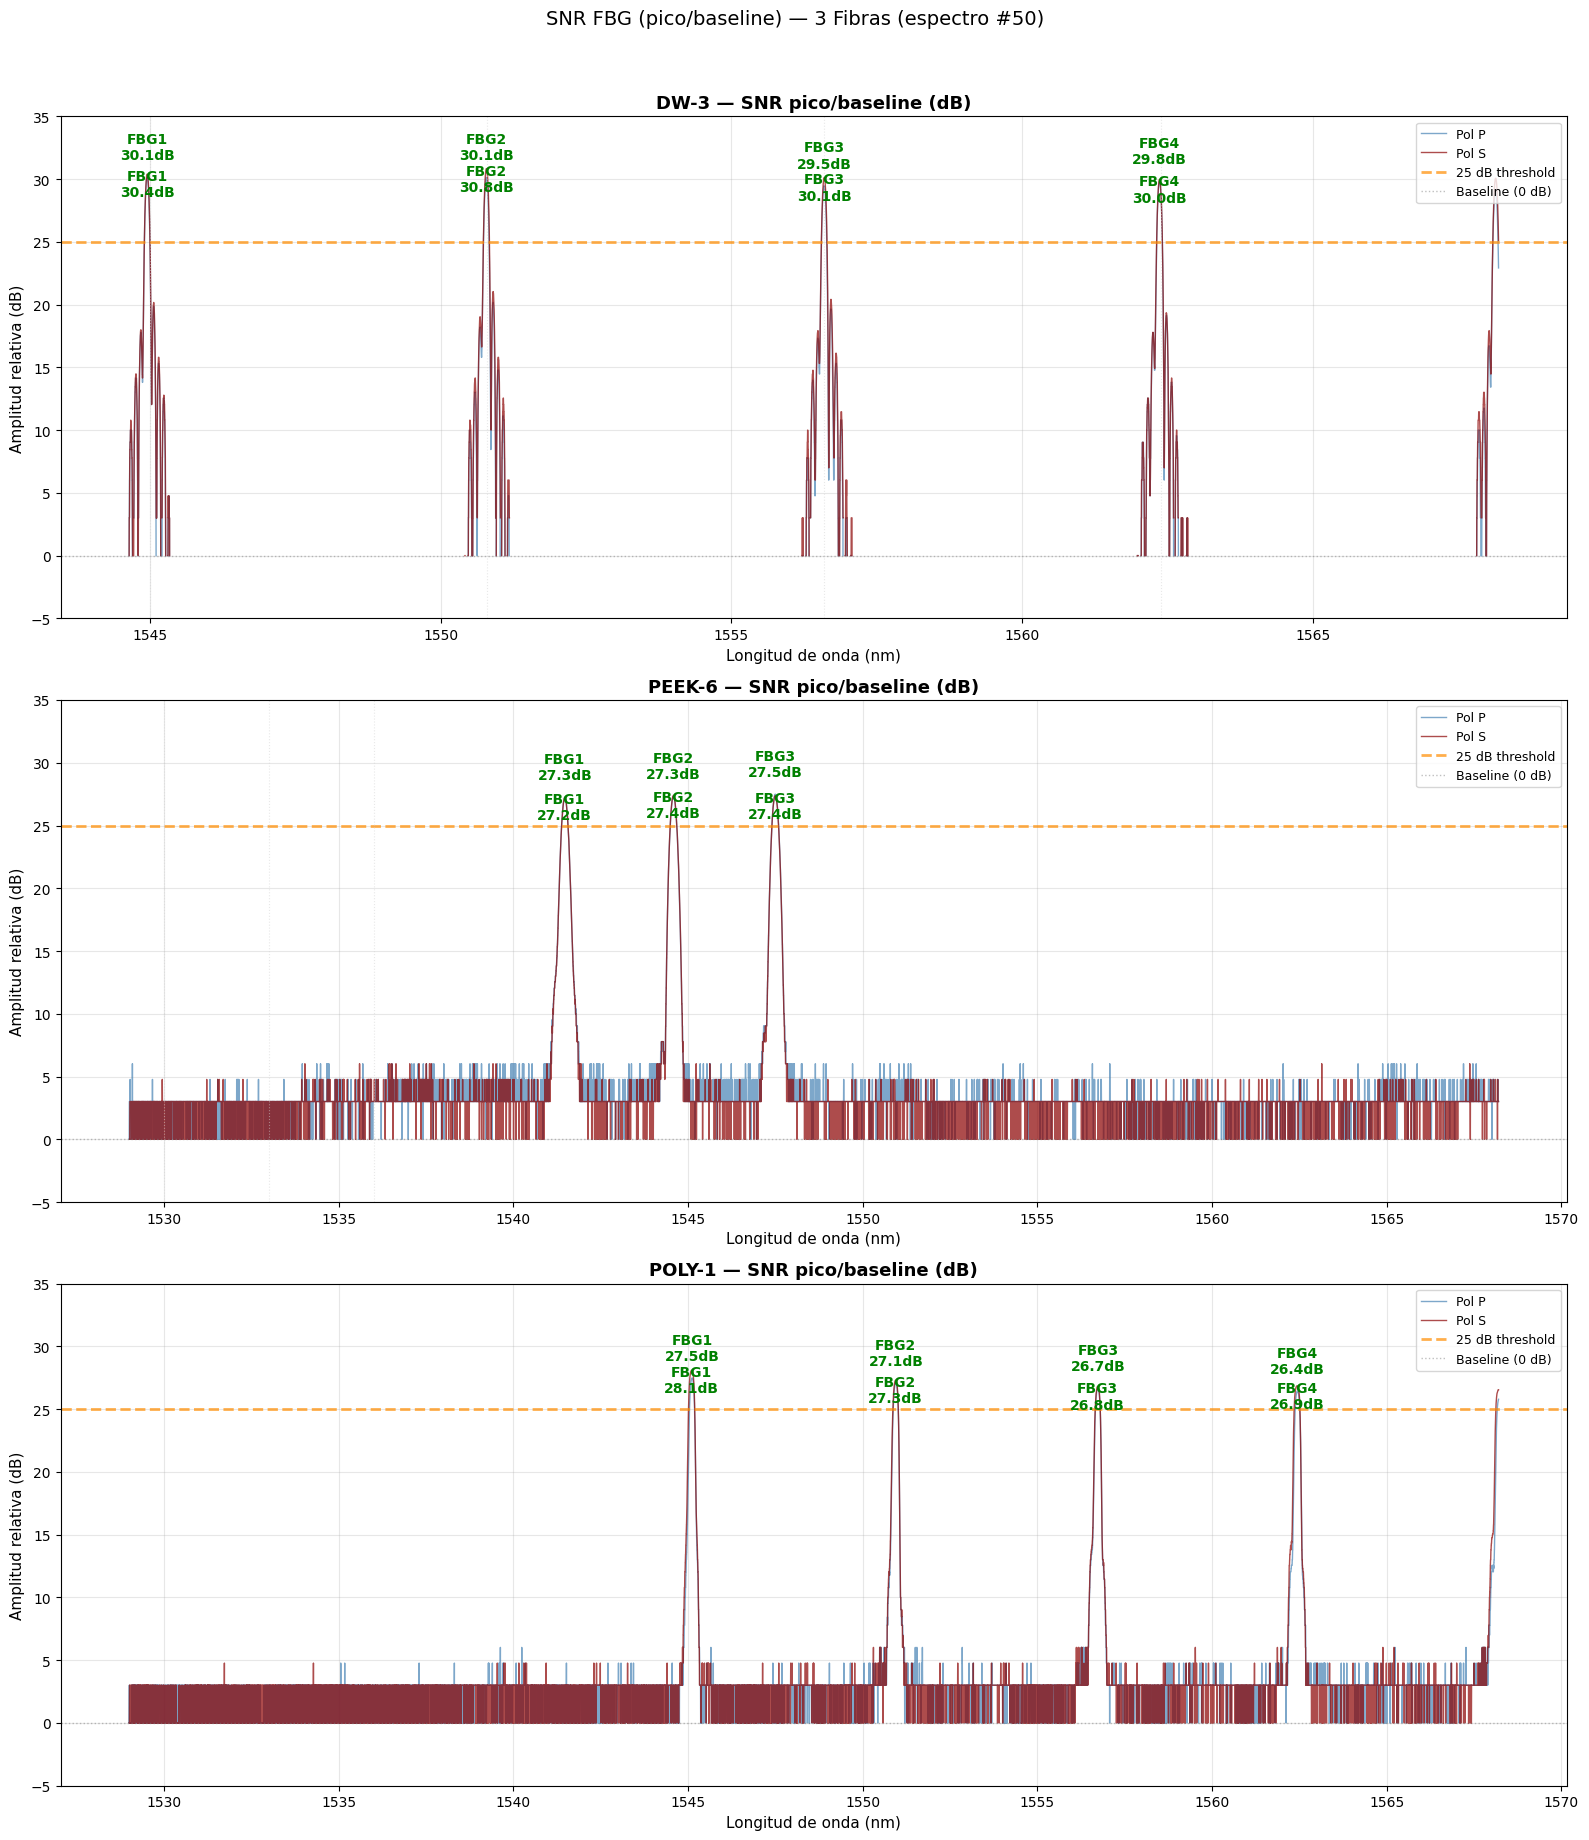

✅ Gráficos de SNR con eje λ generados
   ⚠️ SNR = 10·log₁₀(pico/baseline_local), NO reflectividad absoluta


In [16]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Plot v2: Espectros en dB con eje de longitud de onda
    # ══════════════════════════════════════════════════════════════════════

    n_channels_plot = min(n_chan, 3)
    fig, axes = plt.subplots(n_channels_plot, 1, figsize=(16, 6 * n_channels_plot))
    if n_channels_plot == 1:
        axes = [axes]

    wavelength_axis = LAMBDA_START_NM + np.arange(n_puntos) * dlam_nm_per_pt

    for i, fiber_name in enumerate(['DW-3', 'PEEK-6', 'POLY-1'][:n_channels_plot]):
        if fiber_name not in quality_results:
            continue
        ax = axes[i]
        ch = list(channel_names.values()).index(fiber_name)

        for pol_idx, pol_name in enumerate(pol_labels):
            signal = spectrum_wav[idx_espectro, pol_idx, ch, :]
            bl_glob = global_baseline(signal)

            with np.errstate(divide="ignore", invalid="ignore"):
                signal_db = np.where(signal > 0,
                                     10.0 * np.log10(signal / bl_glob), np.nan)

            color = 'steelblue' if pol_idx == 0 else 'darkred'
            ax.plot(wavelength_axis, signal_db, color=color,
                    linewidth=1.0, alpha=0.7, label=pol_name)

            # Anotar picos válidos
            peaks = fbg_analysis_results[fiber_name][pol_name]
            valid = [p for p in peaks
                     if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]
            for j, peak in enumerate(valid, 1):
                key = (j, pol_name)
                if key not in quality_results[fiber_name]:
                    continue
                r = quality_results[fiber_name][key]
                lam = r['lambda_nm']
                snr = r['snr_db']
                if not np.isnan(snr):
                    y_db = signal_db[r['peak_idx']]
                    txt_col = "green" if snr >= SNR_THRESH_DB else "red"
                    y_off = 1.2 if pol_idx == 0 else -2.0
                    ax.text(lam, y_db + y_off,
                            f"FBG{j}\n{snr:.1f}dB",
                            ha="center", va="bottom", fontsize=10,
                            color=txt_col, fontweight="bold")

        # Threshold y baseline
        ax.axhline(SNR_THRESH_DB, color='darkorange', linestyle='--',
                   linewidth=2, alpha=0.7, label=f'{SNR_THRESH_DB:.0f} dB threshold')
        ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5,
                   label='Baseline (0 dB)')

        # Marcar longitudes de onda de diseño
        for wl in DESIGN_WAVELENGTHS.get(fiber_name, []):
            ax.axvline(wl, color='lightgray', linestyle=':', linewidth=0.8, alpha=0.5)

        ax.set_title(f'{fiber_name} — SNR pico/baseline (dB)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Longitud de onda (nm)', fontsize=11)
        ax.set_ylabel('Amplitud relativa (dB)', fontsize=11)
        ax.set_ylim(-5, SNR_THRESH_DB + 10)
        ax.tick_params(labelsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc='upper right')

    plt.suptitle(f'SNR FBG (pico/baseline) — 3 Fibras (espectro #{idx_espectro})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print("✅ Gráficos de SNR con eje λ generados")
    print("   ⚠️ SNR = 10·log₁₀(pico/baseline_local), NO reflectividad absoluta")

## 7️⃣ Tablas Resumen: Calidad por Sensor + Cross-Polarización

Tres tablas:
1. **Métricas por sensor/polarización**: λ_B, FWHM, BW@20dB, SF, Amp, SNR, SLSR, d_SL, SAR, L
2. **Cross-polarización**: birrefringencia (Δλ P−S), PDL
3. **Promedios por fibra**: resumen rápido de calidad

In [17]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Tabla resumen v2: por sensor + cross-pol + spacing
    # ══════════════════════════════════════════════════════════════════════

    # ── 1) Tabla detallada por sensor/polarización ────────────────────
    rows = []
    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        for pol_name in pol_labels:
            peaks = fbg_analysis_results.get(fiber_name, {}).get(pol_name, [])
            valid = [p for p in peaks
                     if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

            # Calcular spacing entre picos consecutivos
            lambdas = []
            for i in range(1, len(valid) + 1):
                key = (i, pol_name)
                if key in quality_results[fiber_name]:
                    lambdas.append(quality_results[fiber_name][key]['lambda_nm'])
                else:
                    lambdas.append(np.nan)

            for i in range(1, len(valid) + 1):
                key = (i, pol_name)
                if key not in quality_results[fiber_name]:
                    continue
                r = quality_results[fiber_name][key]

                # Spacing al pico anterior
                spacing_nm = np.nan
                if i > 1 and not np.isnan(lambdas[i - 1]) and not np.isnan(lambdas[i - 2]):
                    spacing_nm = lambdas[i - 1] - lambdas[i - 2]

                rows.append({
                    'Fibra': fiber_name,
                    'FBG': i,
                    'Pol': pol_name.split()[-1],
                    'peak_idx': r['peak_idx'],
                    'lambda_B_nm': round(r['lambda_nm'], 3),
                    'spacing_nm': round(spacing_nm, 3) if not np.isnan(spacing_nm) else '',
                    'FWHM_pm': round(r.get('bw_3db_pm', np.nan), 1) if not np.isnan(r.get('bw_3db_pm', np.nan)) else '',
                    'BW20_pm': round(r.get('bw_20db_pm', np.nan), 1) if not np.isnan(r.get('bw_20db_pm', np.nan)) else '',
                    'SF': round(r.get('shape_factor', np.nan), 2) if not np.isnan(r.get('shape_factor', np.nan)) else '',
                    'Amp_cts': round(r['peak_amp'], 0),
                    'SNR_dB': round(r['snr_db'], 1) if not np.isnan(r['snr_db']) else '',
                    'SLSR_dB': round(r['slsr_db'], 1) if not np.isnan(r['slsr_db']) else '',
                    'SLSR_ratio': round(r.get('slsr_ratio', np.nan), 1) if not np.isnan(r.get('slsr_ratio', np.nan)) else '',
                    'd_SL_nm': round(r.get('sidelobe_dist_nm', np.nan), 2) if not np.isnan(r.get('sidelobe_dist_nm', np.nan)) else '',
                    'SAR_pct': round(r.get('sar_pct', np.nan), 1) if not np.isnan(r.get('sar_pct', np.nan)) else '',
                    'SAR90_pct': round(r.get('sar_90_pct', np.nan), 1) if not np.isnan(r.get('sar_90_pct', np.nan)) else '',
                    'SAR50_pct': round(r.get('sar_50_pct', np.nan), 1) if not np.isnan(r.get('sar_50_pct', np.nan)) else '',
                    'L_mm': round(r['fbg_length_mm'], 2) if not np.isnan(r['fbg_length_mm']) else '',
                })

    df_sensor = pd.DataFrame(rows)

    # Display-friendly version
    print("=" * 160)
    print("📋 TABLA 1: MÉTRICAS POR SENSOR Y POLARIZACIÓN")
    print("=" * 160)
    cols_show = ['Fibra', 'FBG', 'Pol', 'lambda_B_nm', 'spacing_nm', 'FWHM_pm',
                 'BW20_pm', 'SF', 'Amp_cts', 'SNR_dB', 'SLSR_dB', 'd_SL_nm',
                 'SAR_pct', 'SAR90_pct', 'SAR50_pct', 'L_mm']
    print(df_sensor[cols_show].to_string(index=False))
    print("=" * 160)

    # ── 2) Cross-polarización ─────────────────────────────────────────
    if cross_pol:
        xp_rows = []
        for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
            if fiber_name not in cross_pol:
                continue
            for sensor_num, cp in sorted(cross_pol[fiber_name].items()):
                xp_rows.append({
                    'Fibra': fiber_name, 'FBG': sensor_num,
                    'lambda_mean_nm': round(cp['lambda_mean'], 3),
                    'birefringence_pm': round(cp['birefringence_pm'], 1),
                    'Amp_P': round(cp['amp_P'], 0),
                    'Amp_S': round(cp['amp_S'], 0),
                    'PDL_dB': round(cp['pdl_db'], 2) if not np.isnan(cp['pdl_db']) else '',
                })
        df_xpol = pd.DataFrame(xp_rows)
        print(f"\n{'='*90}")
        print("📋 TABLA 2: CROSS-POLARIZACIÓN (P vs S)")
        print("=" * 90)
        print(df_xpol.to_string(index=False))
        print("=" * 90)

    # ── 3) Promedios por fibra ────────────────────────────────────────
    avg_rows = []
    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        vals = {'fwhm': [], 'bw20': [], 'sf': [], 'snr': [], 'slsr': [],
                'd_sl': [], 'sar': [], 'sar_90': [], 'sar_50': [],
                'l_fbg': [], 'amp': []}
        for key, r in quality_results[fiber_name].items():
            for attr, dkey in [('fwhm', 'bw_3db_pm'), ('bw20', 'bw_20db_pm'),
                               ('sf', 'shape_factor'), ('snr', 'snr_db'),
                               ('slsr', 'slsr_db'), ('d_sl', 'sidelobe_dist_nm'),
                               ('sar', 'sar_pct'), ('sar_90', 'sar_90_pct'),
                               ('sar_50', 'sar_50_pct'),
                               ('l_fbg', 'fbg_length_mm'), ('amp', 'peak_amp')]:
                v = r.get(dkey, np.nan)
                if not np.isnan(v):
                    vals[attr].append(v)

        def m(lst, fmt):
            return fmt.format(np.mean(lst)) if lst else 'N/A'
        def s(lst, fmt):
            return fmt.format(np.std(lst)) if len(lst) > 1 else '–'

        avg_rows.append({
            'Fibra': fiber_name,
            'N_sens': DESIGN_N_SENSORS[fiber_name],
            'FWHM (pm)': f"{m(vals['fwhm'],'{:.0f}')} ± {s(vals['fwhm'],'{:.0f}')}",
            'BW@20 (pm)': f"{m(vals['bw20'],'{:.0f}')} ± {s(vals['bw20'],'{:.0f}')}",
            'SF': m(vals['sf'], '{:.2f}'),
            'SNR (dB)': f"{m(vals['snr'],'{:.1f}')} ± {s(vals['snr'],'{:.1f}')}",
            'SLSR (dB)': f"{m(vals['slsr'],'{:.1f}')} ± {s(vals['slsr'],'{:.1f}')}",
            'SAR (%)': m(vals['sar'], '{:.1f}'),
            'SAR@90 (%)': m(vals['sar_90'], '{:.1f}'),
            'SAR@50 (%)': m(vals['sar_50'], '{:.1f}'),
        })

    df_avg = pd.DataFrame(avg_rows)
    print(f"\n{'='*120}")
    print("📋 TABLA 3: PROMEDIOS POR FIBRA (ambas polarizaciones)")
    print("=" * 120)
    print(df_avg.to_string(index=False))
    print("=" * 120)

    print("\n📐 CRITERIOS DE CALIDAD:")
    print(f"   • SNR > {SNR_THRESH_DB:.0f} dB | SLSR > {SLSR_THRESH_DB:.0f} dB | SAR < {SAR_THRESH_PCT:.0f}%")
    print(f"   • IL total < {IL_TOTAL_THRESH_DB:.1f} dB")

    # Guardar df_sensor para CSV
    df_summary = df_sensor

elif data_spectrum is not None:
    print("⚠️  Ejecuta primero las celdas de análisis de calidad")

📋 TABLA 1: MÉTRICAS POR SENSOR Y POLARIZACIÓN
 Fibra  FBG Pol  lambda_B_nm spacing_nm  FWHM_pm  BW20_pm   SF  Amp_cts  SNR_dB  SLSR_dB  d_SL_nm  SAR_pct  SAR90_pct  SAR50_pct  L_mm
  DW-3    1   P     1544.952                76.5    288.7 3.77   1030.0    30.1     10.4     0.12      0.2        1.0        0.2 22.50
  DW-3    2   P     1550.786      5.834     78.0    220.7 2.83   1030.0    30.1     10.0     0.12      0.8        3.5        0.8 22.23
  DW-3    3   P     1556.598      5.812     76.9    219.1 2.85    887.0    29.5      9.8     0.12      1.0        0.6        1.0 22.72
  DW-3    4   P     1562.367      5.769     80.1    227.4 2.84    962.0    29.8     10.7     0.12      0.4        1.9        0.4 22.01
  DW-3    1   S     1544.952                77.2    289.6 3.75   1095.0    30.4     10.4     0.12      2.0        5.0        2.0 22.30
  DW-3    2   S     1550.788      5.836     79.9    221.9 2.78   1212.0    30.8      9.9     0.12      0.8        2.2        0.8 21.74
  DW-3   

### 7.1 Comparación Pol P vs Pol S por sensor

Para cada fibra, se superponen los espectros de Pol P y Pol S alrededor de cada sensor FBG.
Se anotan la birrefringencia (Δλ) y la diferencia de amplitud (PDL).
Esto permite evaluar si el efecto de la polarización es significativo para cada grating.

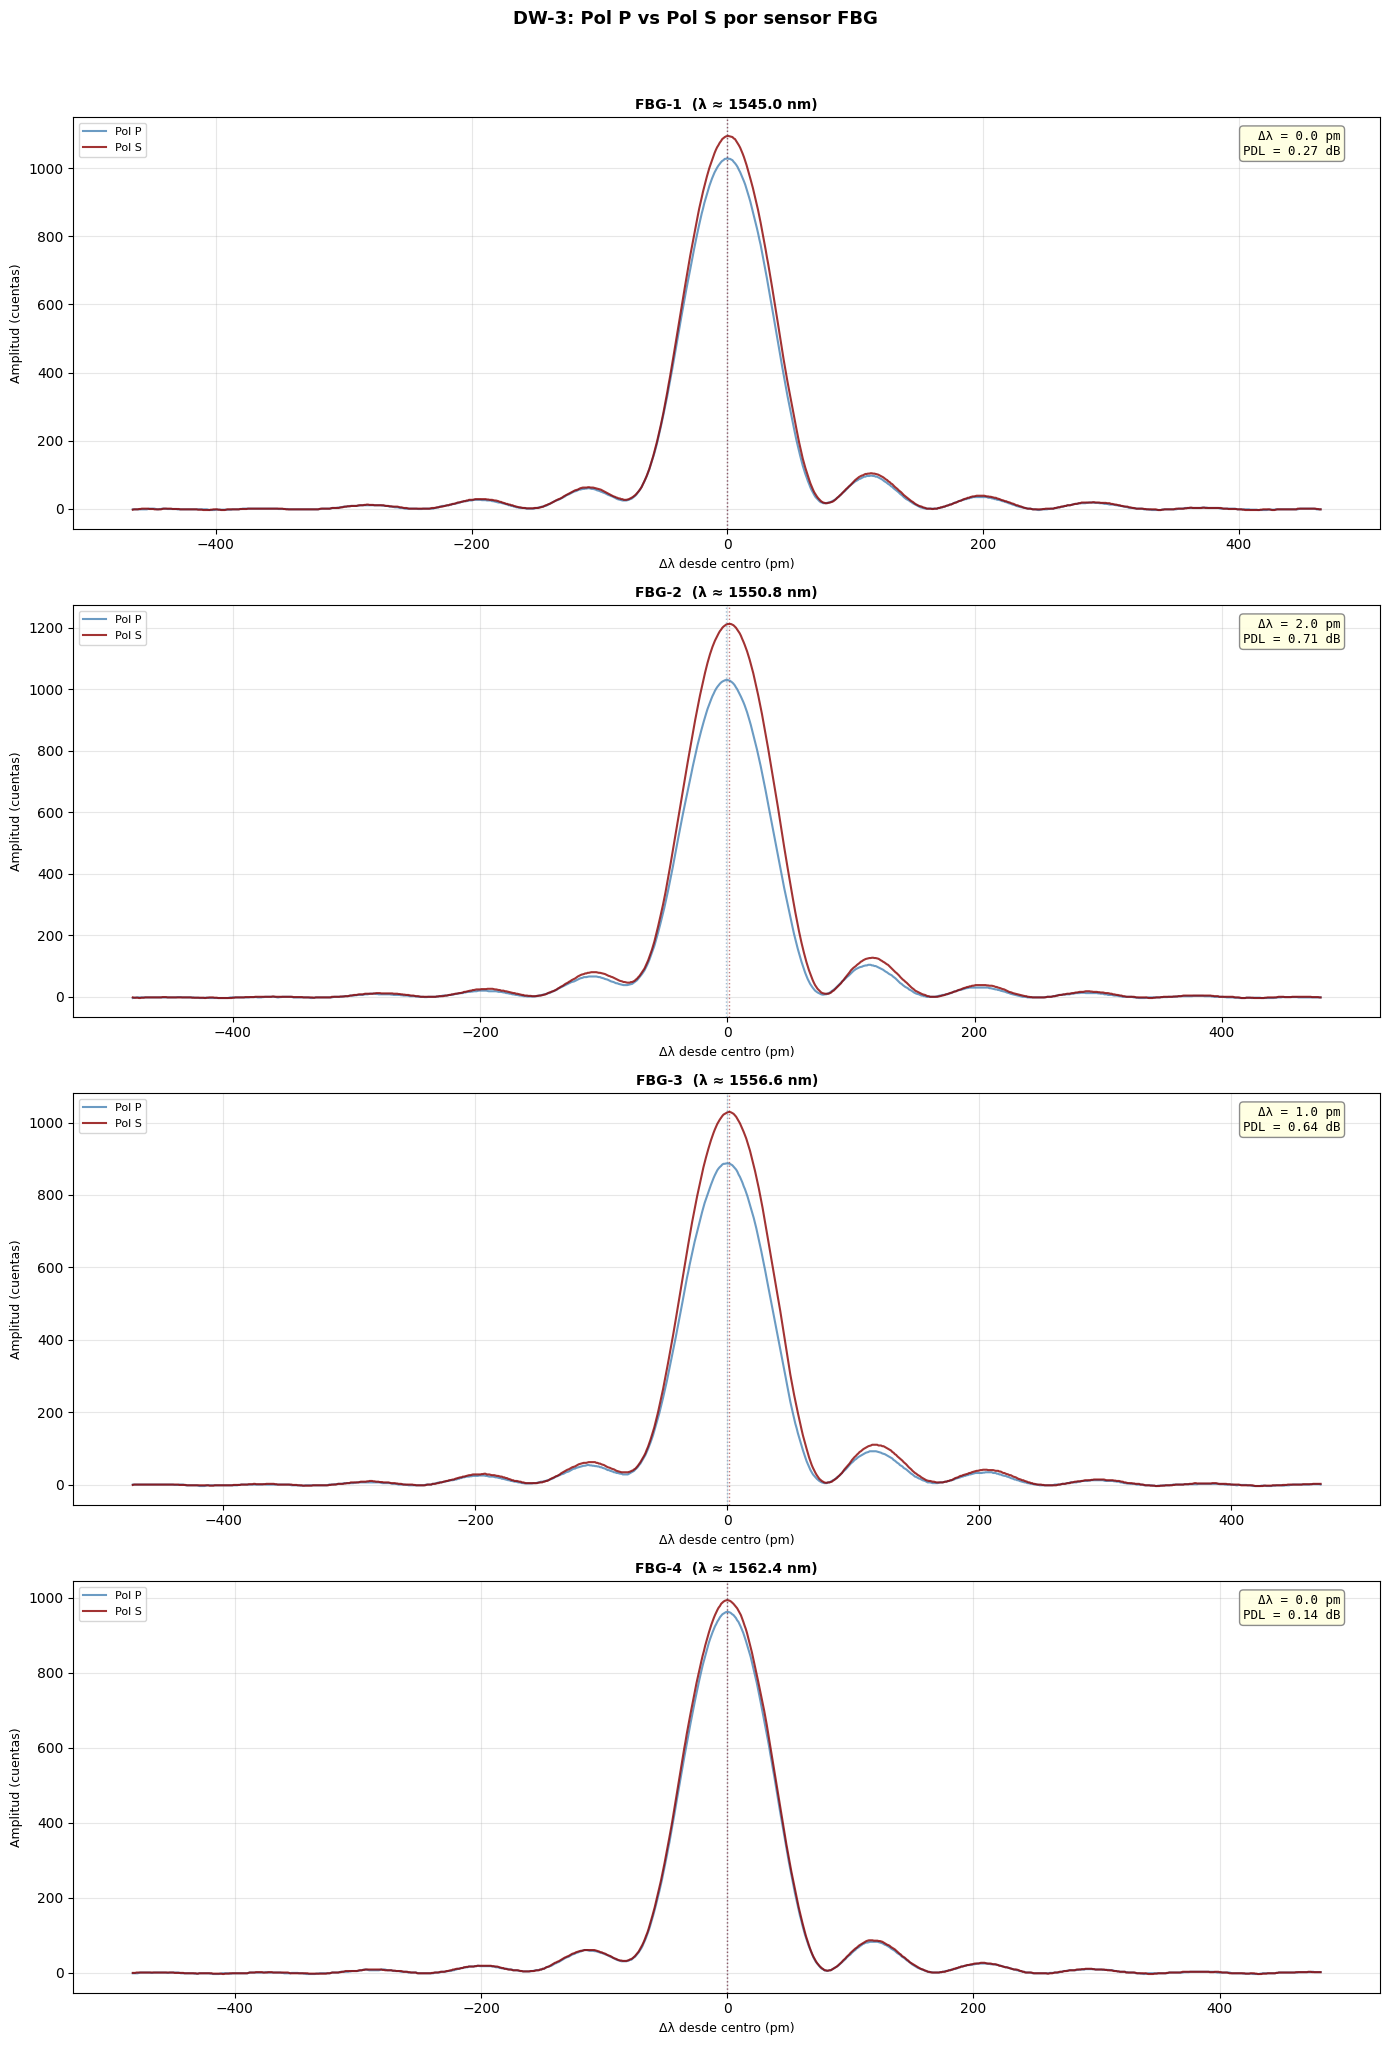

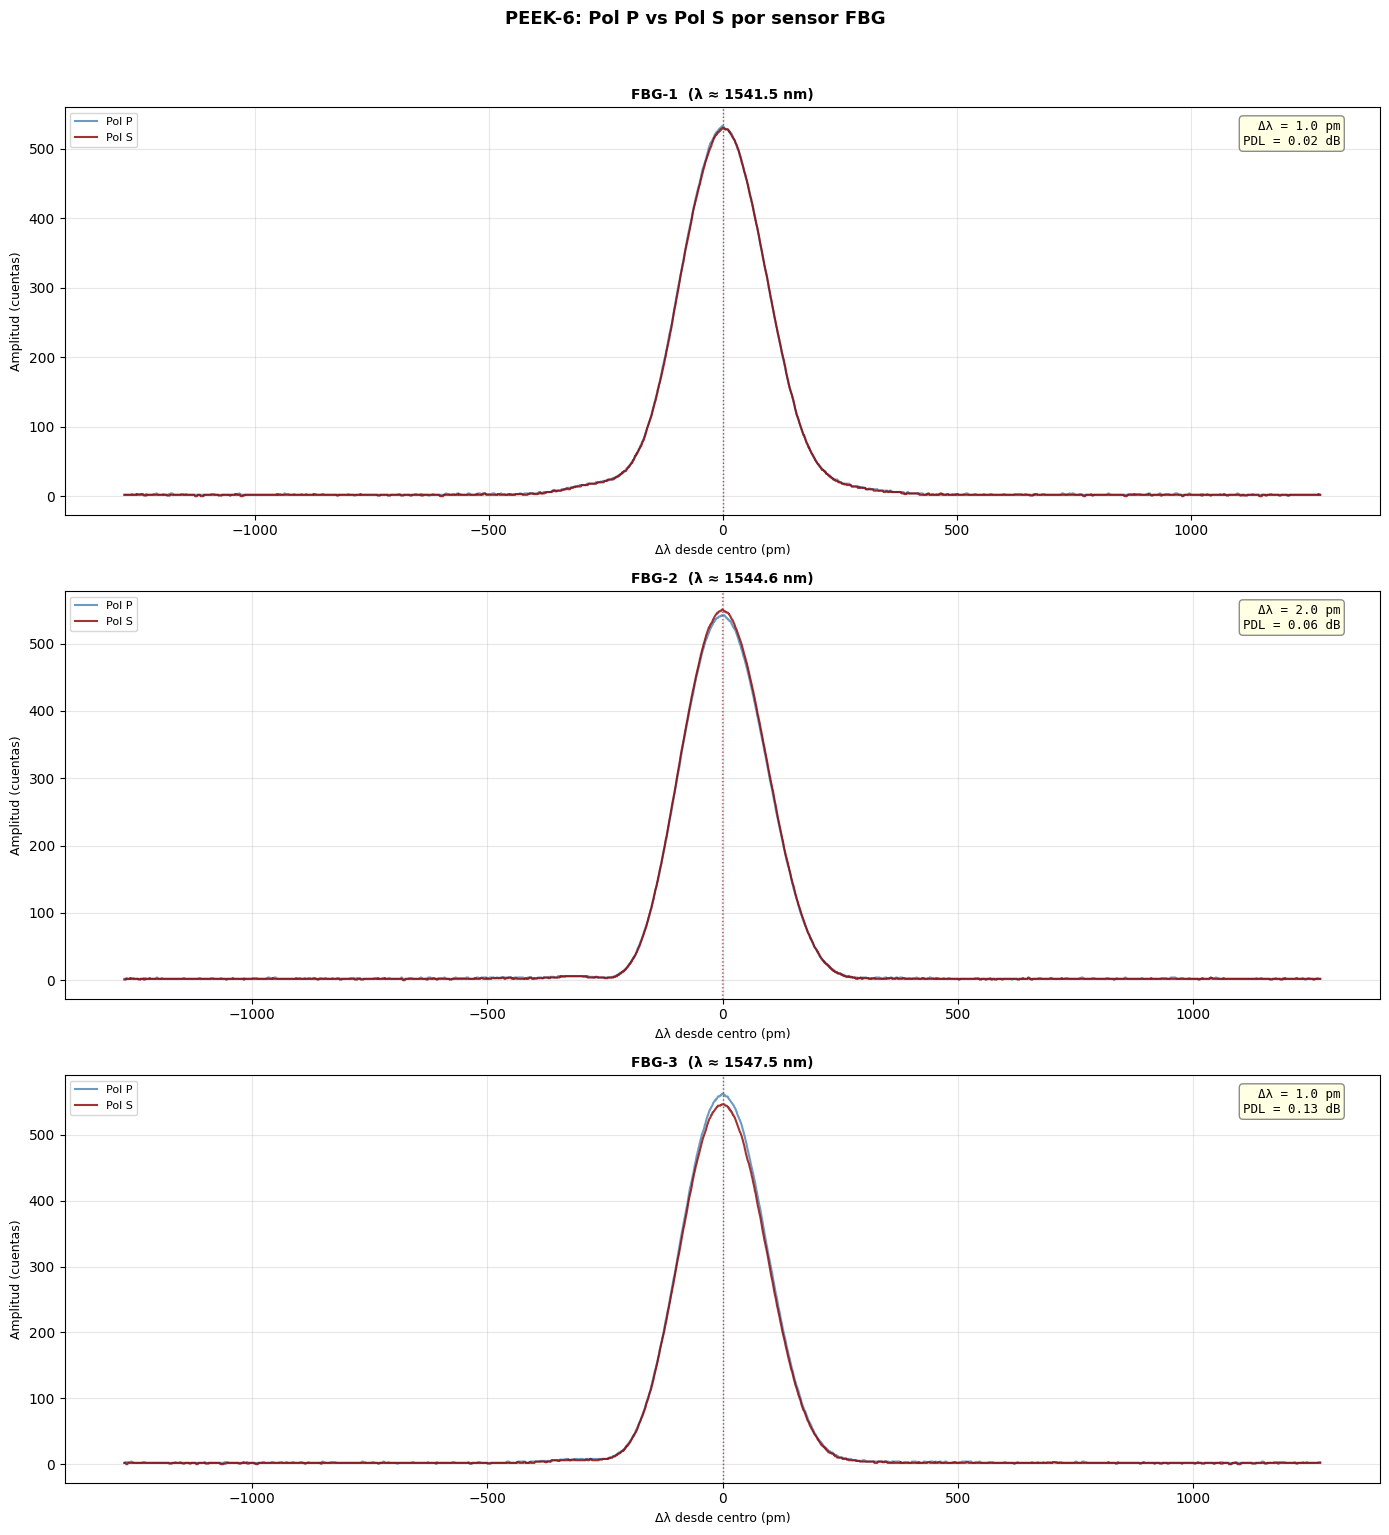

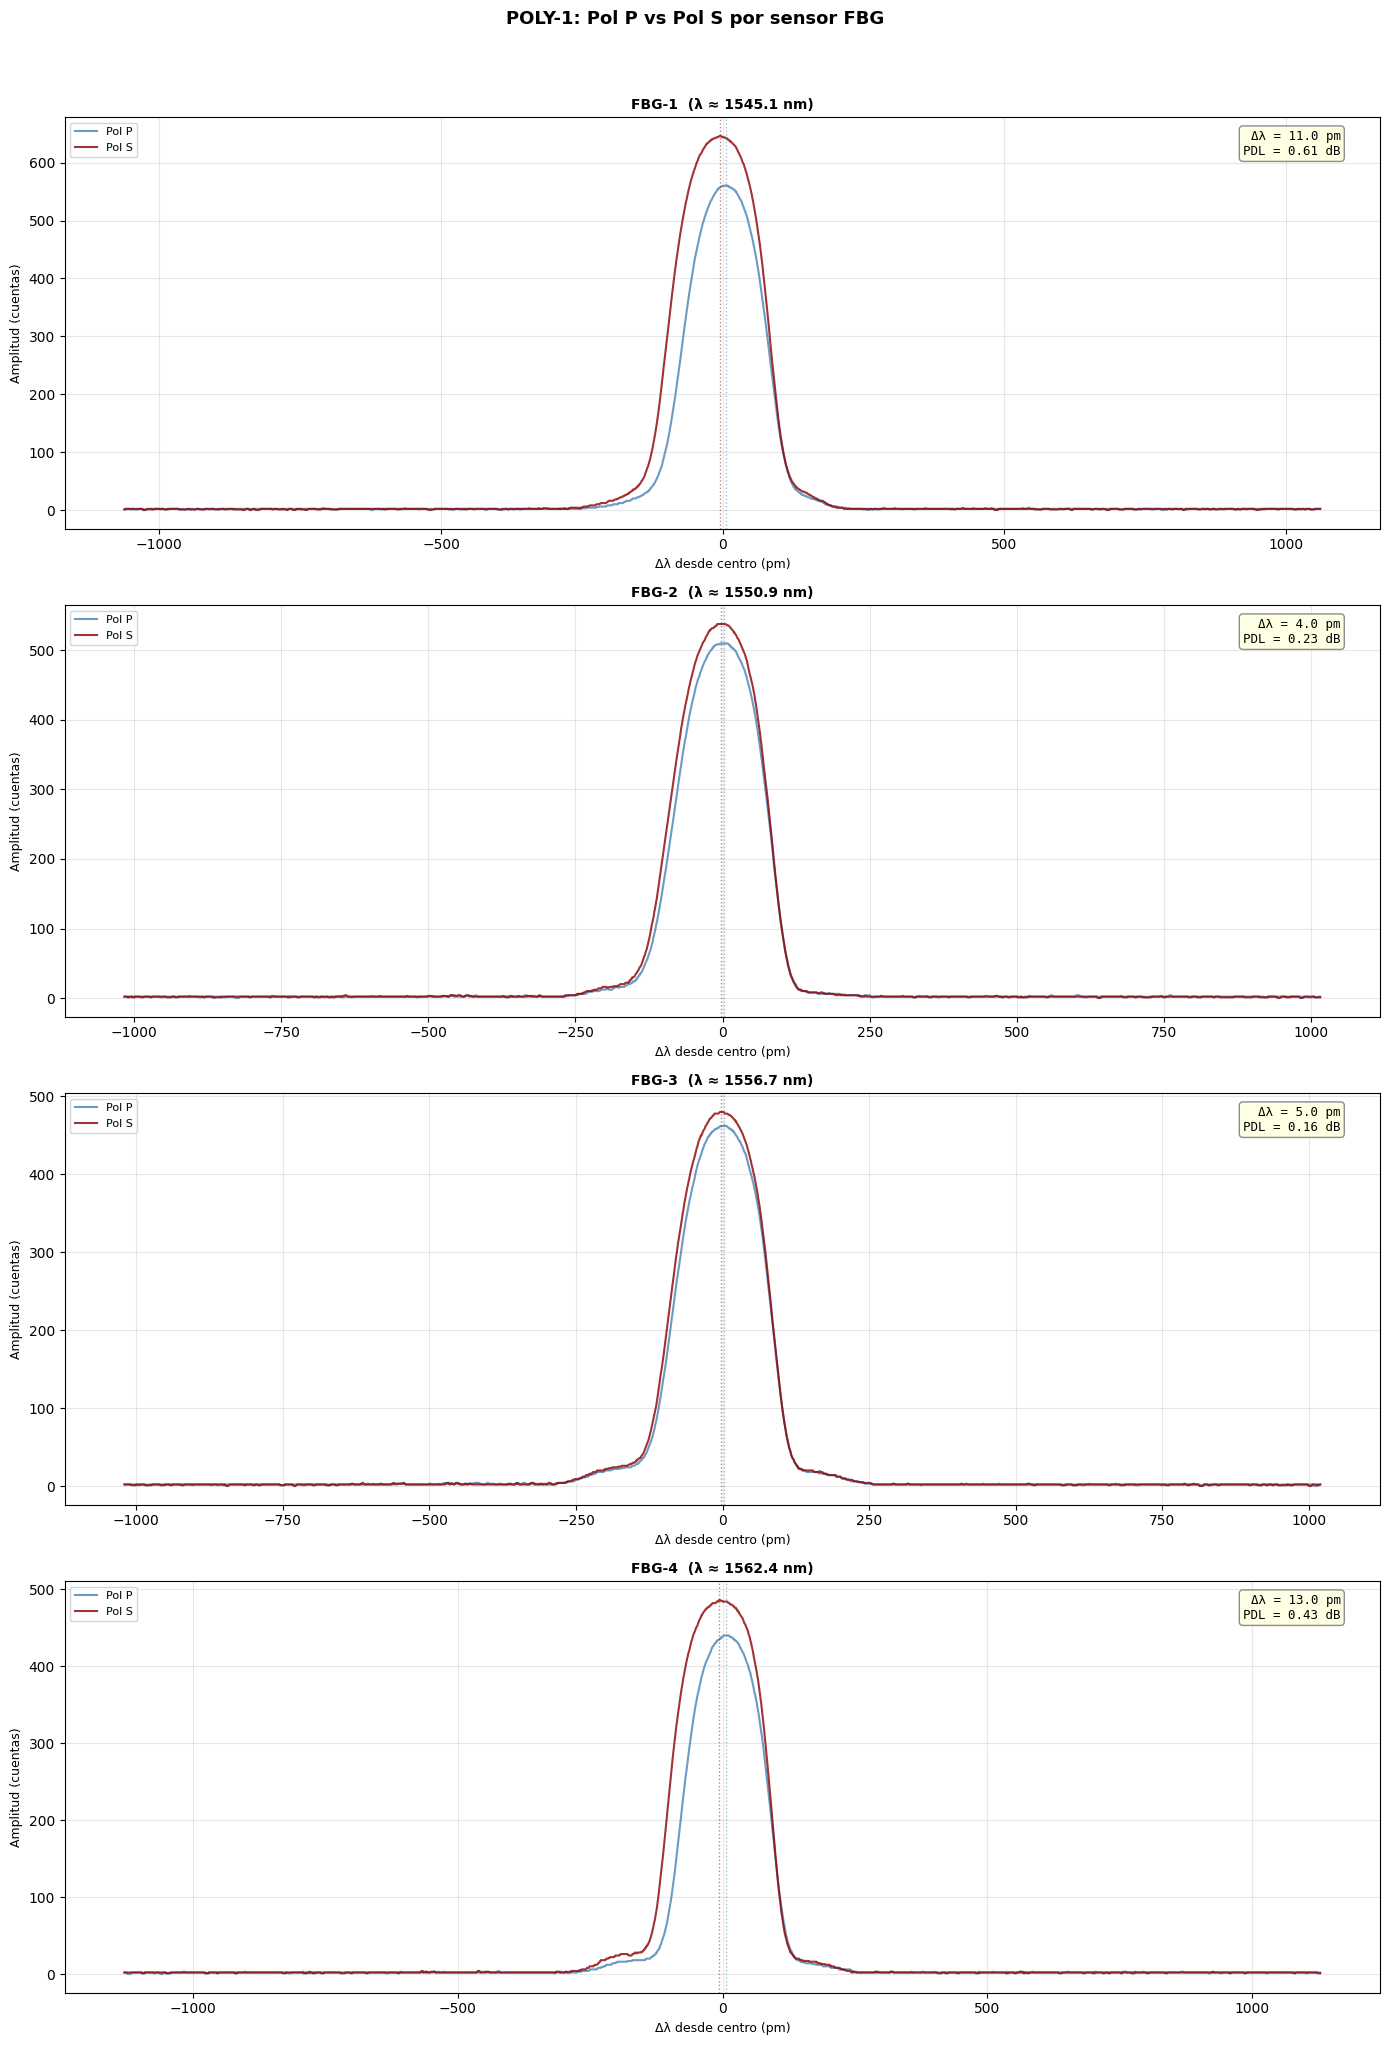

✅ Comparación P vs S completada
   • Δλ: birrefringencia entre polarizaciones
   • PDL: diferencia de amplitud (Polarization Dependent Loss)


In [18]:
if data_spectrum is not None and 'quality_results' in locals() and 'cross_pol' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Comparación Pol P vs Pol S: un subplot por sensor FBG
    # ══════════════════════════════════════════════════════════════════════

    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in cross_pol or not cross_pol[fiber_name]:
            continue

        ch = list(channel_names.values()).index(fiber_name)
        n_sensors = len(cross_pol[fiber_name])

        fig, axes = plt.subplots(n_sensors, 1, figsize=(14, 5 * n_sensors))
        if n_sensors == 1:
            axes = [axes]

        sig_p = spectrum_wav[idx_espectro, 0, ch, :]
        sig_s = spectrum_wav[idx_espectro, 1, ch, :]

        for s_idx in range(n_sensors):
            sensor_num = s_idx + 1
            ax = axes[s_idx]
            cp = cross_pol[fiber_name].get(sensor_num)
            if cp is None:
                continue

            # Buscar picos de Pol P y Pol S para este sensor
            peaks_P = fbg_analysis_results[fiber_name].get('Pol P', [])
            peaks_S = fbg_analysis_results[fiber_name].get('Pol S', [])
            valid_P = [p for p in peaks_P
                       if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]
            valid_S = [p for p in peaks_S
                       if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

            if s_idx >= len(valid_P) or s_idx >= len(valid_S):
                continue

            pk_P = valid_P[s_idx]
            pk_S = valid_S[s_idx]
            center_idx = int((pk_P['peak_idx'] + pk_S['peak_idx']) / 2)

            # Ventana de zoom: 6× FWHM máximo
            zoom = int(max(pk_P['fwhm'], pk_S['fwhm']) * 6)
            x0 = max(0, center_idx - zoom)
            x1 = min(n_puntos, center_idx + zoom)

            # Eje en longitud de onda relativa al centro (pm)
            lam_center = idx_to_wavelength(center_idx)
            x_pm = (np.arange(x0, x1) - center_idx) * dlam_nm_per_pt * 1e3

            ax.plot(x_pm, sig_p[x0:x1], color='steelblue', linewidth=1.5,
                    alpha=0.8, label='Pol P')
            ax.plot(x_pm, sig_s[x0:x1], color='darkred', linewidth=1.5,
                    alpha=0.8, label='Pol S')

            # Marcar picos
            for pk, col, lbl in [(pk_P, 'steelblue', 'P'), (pk_S, 'darkred', 'S')]:
                lam_pk = idx_to_wavelength(pk['peak_idx'])
                x_pk_pm = (pk['peak_idx'] - center_idx) * dlam_nm_per_pt * 1e3
                ax.axvline(x_pk_pm, color=col, linestyle=':', linewidth=1, alpha=0.5)

            # Anotaciones
            biref = cp['birefringence_pm']
            pdl = cp['pdl_db']
            info = f"Δλ = {biref:.1f} pm\nPDL = {pdl:.2f} dB" if not np.isnan(pdl) else f"Δλ = {biref:.1f} pm"
            ax.text(0.97, 0.97, info, transform=ax.transAxes,
                    fontsize=9, va='top', ha='right',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                              alpha=0.9, edgecolor='gray'),
                    fontfamily='monospace')

            ax.set_title(f'FBG-{sensor_num}  (λ ≈ {lam_center:.1f} nm)',
                         fontsize=10, fontweight='bold')
            ax.set_xlabel('Δλ desde centro (pm)', fontsize=9)
            ax.set_ylabel('Amplitud (cuentas)', fontsize=9)
            ax.legend(fontsize=8, loc='upper left')
            ax.grid(True, alpha=0.3)

        plt.suptitle(f'{fiber_name}: Pol P vs Pol S por sensor FBG',
                     fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    print("✅ Comparación P vs S completada")
    print("   • Δλ: birrefringencia entre polarizaciones")
    print("   • PDL: diferencia de amplitud (Polarization Dependent Loss)")

### 7.2 Comparación entre sensores: Métricas de calidad

Barras agrupadas comparando FWHM, SNR, SLSR y SAR para cada sensor de cada fibra,
con Pol P y Pol S lado a lado. Permite identificar rápidamente sensores con calidad
inferior o variabilidad excesiva dentro de una misma fibra.

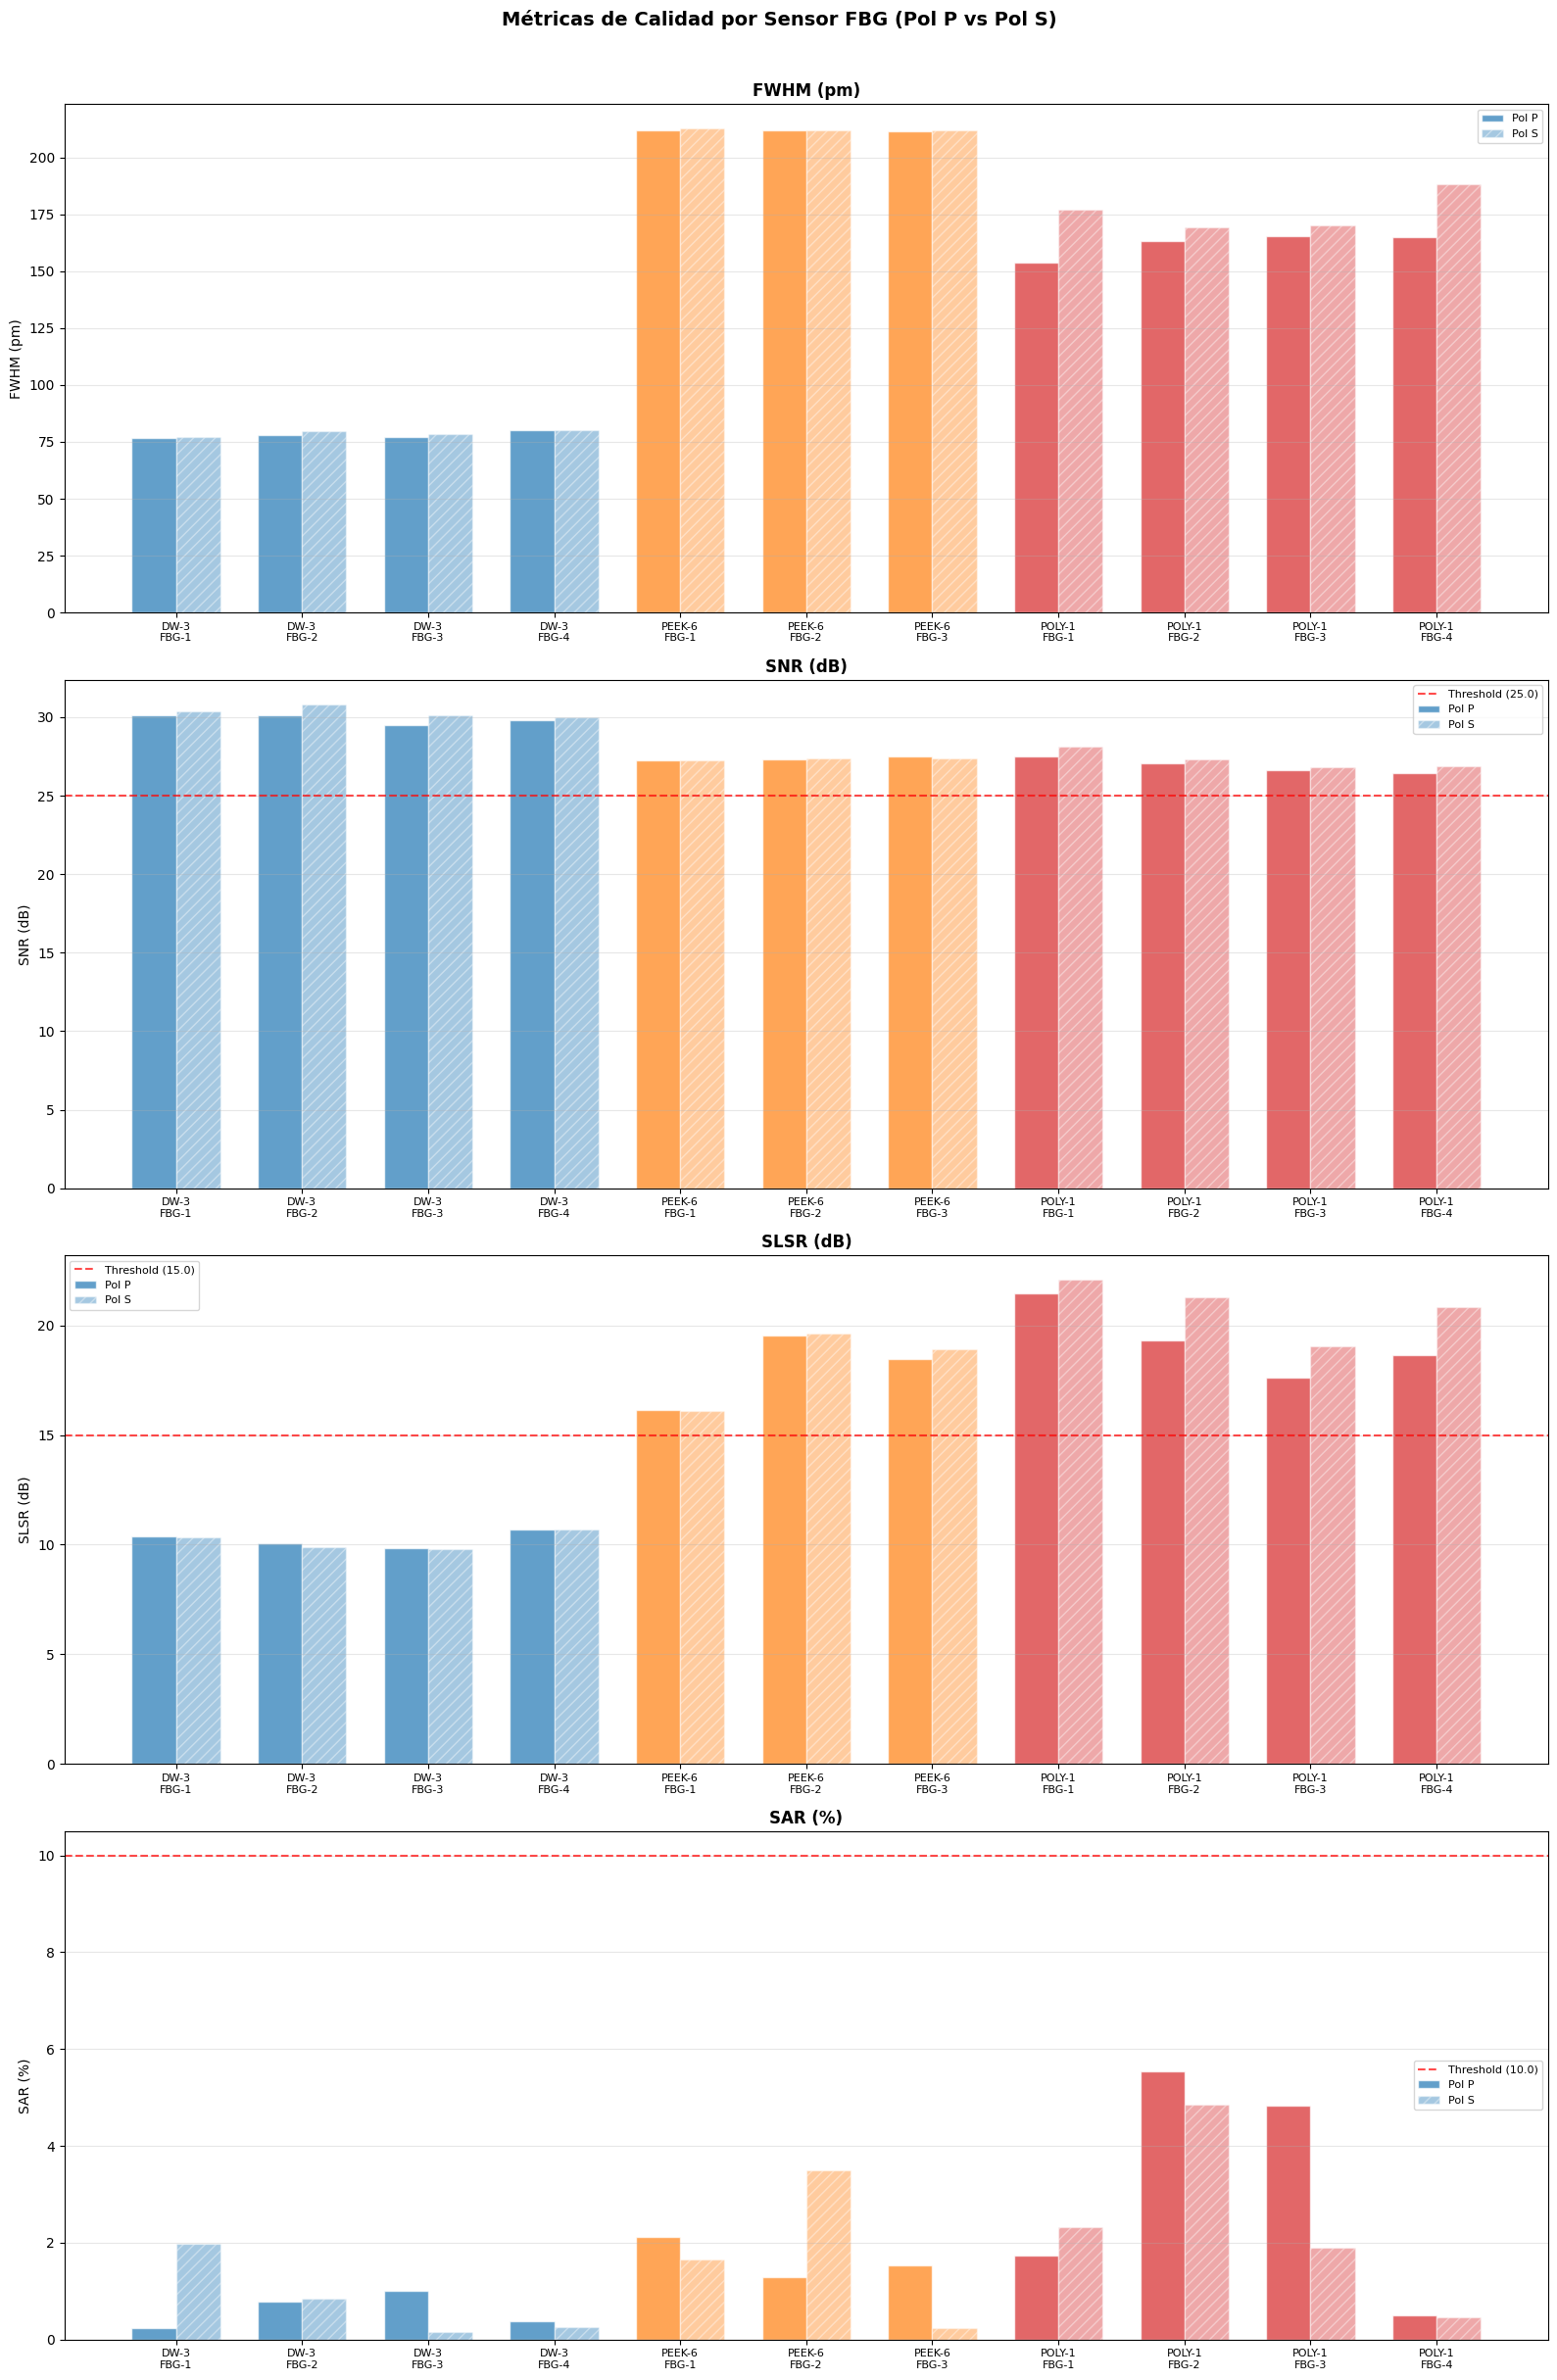

✅ Barras comparativas inter-sensor generadas
   Barras sólidas = Pol P | Barras rayadas = Pol S
   Línea roja = threshold de calidad


In [19]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Barras comparativas: métricas de calidad por sensor (P y S)
    # ══════════════════════════════════════════════════════════════════════

    metrics_to_plot = [
        ('bw_3db_pm',  'FWHM (pm)',  None, None),
        ('snr_db',   'SNR (dB)',   SNR_THRESH_DB, 'min'),
        ('slsr_db',  'SLSR (dB)',  SLSR_THRESH_DB, 'min'),
        ('sar_pct',  'SAR (%)',    SAR_THRESH_PCT, 'max'),
    ]

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}

    fig, axes = plt.subplots(4, 1, figsize=(16, 24))
    axes = axes.flatten()

    for ax_idx, (mkey, mlabel, thresh, thresh_type) in enumerate(metrics_to_plot):
        ax = axes[ax_idx]

        # Recoger datos: etiquetas, valores P, valores S
        labels = []
        vals_p = []
        vals_s = []
        fiber_colors = []

        for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
            if fiber_name not in quality_results:
                continue
            n_design = DESIGN_N_SENSORS[fiber_name]
            for s in range(1, n_design + 1):
                labels.append(f"{fiber_name}\nFBG-{s}")
                fiber_colors.append(colors_fiber[fiber_name])

                rp = quality_results[fiber_name].get((s, 'Pol P'), {})
                rs = quality_results[fiber_name].get((s, 'Pol S'), {})
                vp = rp.get(mkey, np.nan)
                vs = rs.get(mkey, np.nan)
                vals_p.append(vp if not np.isnan(vp) else 0)
                vals_s.append(vs if not np.isnan(vs) else 0)

        x = np.arange(len(labels))
        w = 0.35

        bars_p = ax.bar(x - w/2, vals_p, w, label='Pol P',
                        color=[c for c in fiber_colors], alpha=0.7, edgecolor='white')
        bars_s = ax.bar(x + w/2, vals_s, w, label='Pol S',
                        color=[c for c in fiber_colors], alpha=0.4, edgecolor='white',
                        hatch='///')

        # Threshold line
        if thresh is not None:
            ax.axhline(thresh, color='red', linestyle='--', linewidth=1.5,
                       alpha=0.7, label=f'Threshold ({thresh})')

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel(mlabel, fontsize=10)
        ax.set_title(mlabel, fontsize=12, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)

    plt.suptitle('Métricas de Calidad por Sensor FBG (Pol P vs Pol S)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print("✅ Barras comparativas inter-sensor generadas")
    print("   Barras sólidas = Pol P | Barras rayadas = Pol S")
    print("   Línea roja = threshold de calidad")

## 8️⃣ Visualización Comparativa: Picos Superpuestos

Superpone el primer pico de cada fibra (media P+S) con eje X en pm (Δλ desde centro).
Los recuadros laterales muestran todas las métricas v2 incluyendo BW@20dB y Shape Factor.

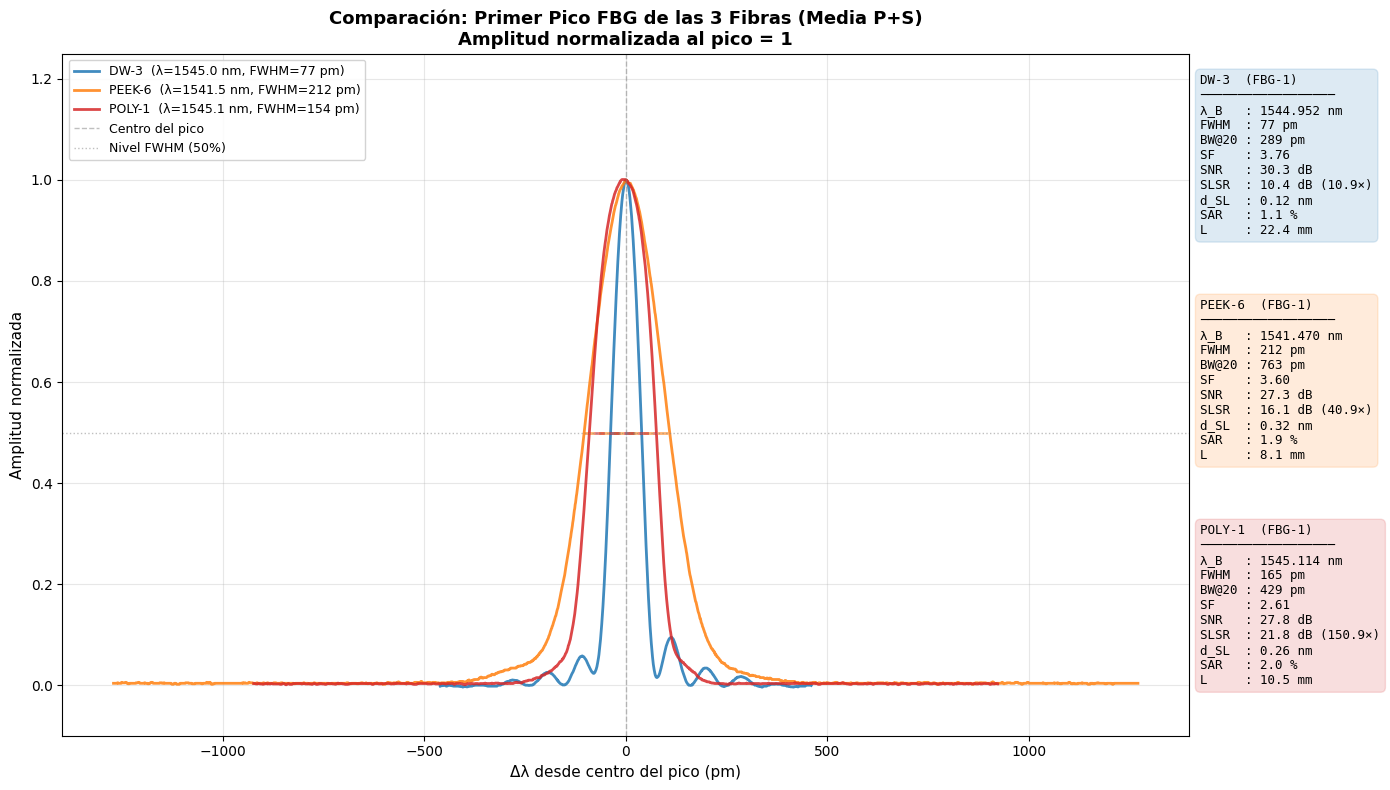

✅ Comparación normalizada con métricas v2 completada
   Resolución: 1.00 pm/pt | Eje X en pm


In [20]:
if data_spectrum is not None and 'quality_results' in locals():
    fig, ax = plt.subplots(figsize=(14, 8))

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}
    box_y_positions = {'DW-3': 0.97, 'PEEK-6': 0.64, 'POLY-1': 0.31}

    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in fbg_analysis_results or fiber_name not in quality_results:
            continue

        peaks_p = fbg_analysis_results[fiber_name]['Pol P']
        valid_p = [p for p in peaks_p
                   if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]
        if len(valid_p) == 0:
            continue

        peak = valid_p[0]  # Primer sensor válido
        ch = list(channel_names.values()).index(fiber_name)
        sig_p = spectrum_wav[idx_espectro, 0, ch, :]
        sig_s = spectrum_wav[idx_espectro, 1, ch, :]
        signal = (sig_p + sig_s) / 2.0

        peak_idx = peak['peak_idx']
        zoom = int(peak['fwhm'] * 6)
        x0 = max(0, peak_idx - zoom)
        x1 = min(n_puntos, peak_idx + zoom)

        # Eje en Δλ (pm) respecto al centro
        x_pm = (np.arange(x0, x1) - peak_idx) * dlam_nm_per_pt * 1e3
        y_norm = signal[x0:x1] / signal[peak_idx]

        color = colors_fiber[fiber_name]
        fwhm_pm = peak['fwhm'] * dlam_nm_per_pt * 1e3
        lam_b = idx_to_wavelength(peak_idx)

        ax.plot(x_pm, y_norm, color=color, linewidth=2, alpha=0.85,
                label=f"{fiber_name}  (λ={lam_b:.1f} nm, FWHM={fwhm_pm:.0f} pm)")

        # FWHM line
        l_ip_pm = (peak['left_ip'] - peak_idx) * dlam_nm_per_pt * 1e3
        r_ip_pm = (peak['right_ip'] - peak_idx) * dlam_nm_per_pt * 1e3
        ax.hlines(0.5, l_ip_pm, r_ip_pm, color=color, linestyle='--',
                  linewidth=2, alpha=0.6)

        # Métricas promedio P+S
        mp = quality_results[fiber_name].get((1, 'Pol P'), {})
        ms = quality_results[fiber_name].get((1, 'Pol S'), {})

        def avg(key):
            vals = [m.get(key, np.nan) for m in [mp, ms]]
            vals = [v for v in vals if not np.isnan(v)]
            return np.mean(vals) if vals else np.nan

        snr     = avg('snr_db')
        slsr    = avg('slsr_db')
        slsr_r  = avg('slsr_ratio')
        d_sl    = avg('sidelobe_dist_nm')
        sar     = avg('sar_pct')
        l_fbg   = avg('fbg_length_mm')
        bw20    = avg('bw_20db_pm')
        sf      = avg('shape_factor')

        def fmt(v, fs):
            return fs.format(v) if not (isinstance(v, float) and np.isnan(v)) else "N/A"

        info = (
            f"{fiber_name}  (FBG-1)\n"
            f"──────────────────\n"
            f"λ_B   : {lam_b:.3f} nm\n"
            f"FWHM  : {fmt(avg('bw_3db_pm'),'{:.0f}')} pm\n"
            f"BW@20 : {fmt(bw20,'{:.0f}')} pm\n"
            f"SF    : {fmt(sf,'{:.2f}')}\n"
            f"SNR   : {fmt(snr,'{:.1f}')} dB\n"
            f"SLSR  : {fmt(slsr,'{:.1f}')} dB ({fmt(slsr_r,'{:.1f}')}×)\n"
            f"d_SL  : {fmt(d_sl,'{:.2f}')} nm\n"
            f"SAR   : {fmt(sar,'{:.1f}')} %\n"
            f"L     : {fmt(l_fbg,'{:.1f}')} mm"
        )

        ax.text(1.01, box_y_positions[fiber_name], info,
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color,
                          alpha=0.15, edgecolor=color),
                color='black', fontfamily='monospace')

    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5,
               label='Centro del pico')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5,
               label='Nivel FWHM (50%)')

    ax.set_xlabel('Δλ desde centro del pico (pm)', fontsize=11)
    ax.set_ylabel('Amplitud normalizada', fontsize=11)
    ax.set_ylim(-0.1, 1.25)
    ax.set_title('Comparación: Primer Pico FBG de las 3 Fibras (Media P+S)\n'
                 'Amplitud normalizada al pico = 1', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left', framealpha=0.85)

    plt.tight_layout()
    plt.show()

    print("✅ Comparación normalizada con métricas v2 completada")
    print(f"   Resolución: {dlam_nm_per_pt*1e3:.2f} pm/pt | Eje X en pm")

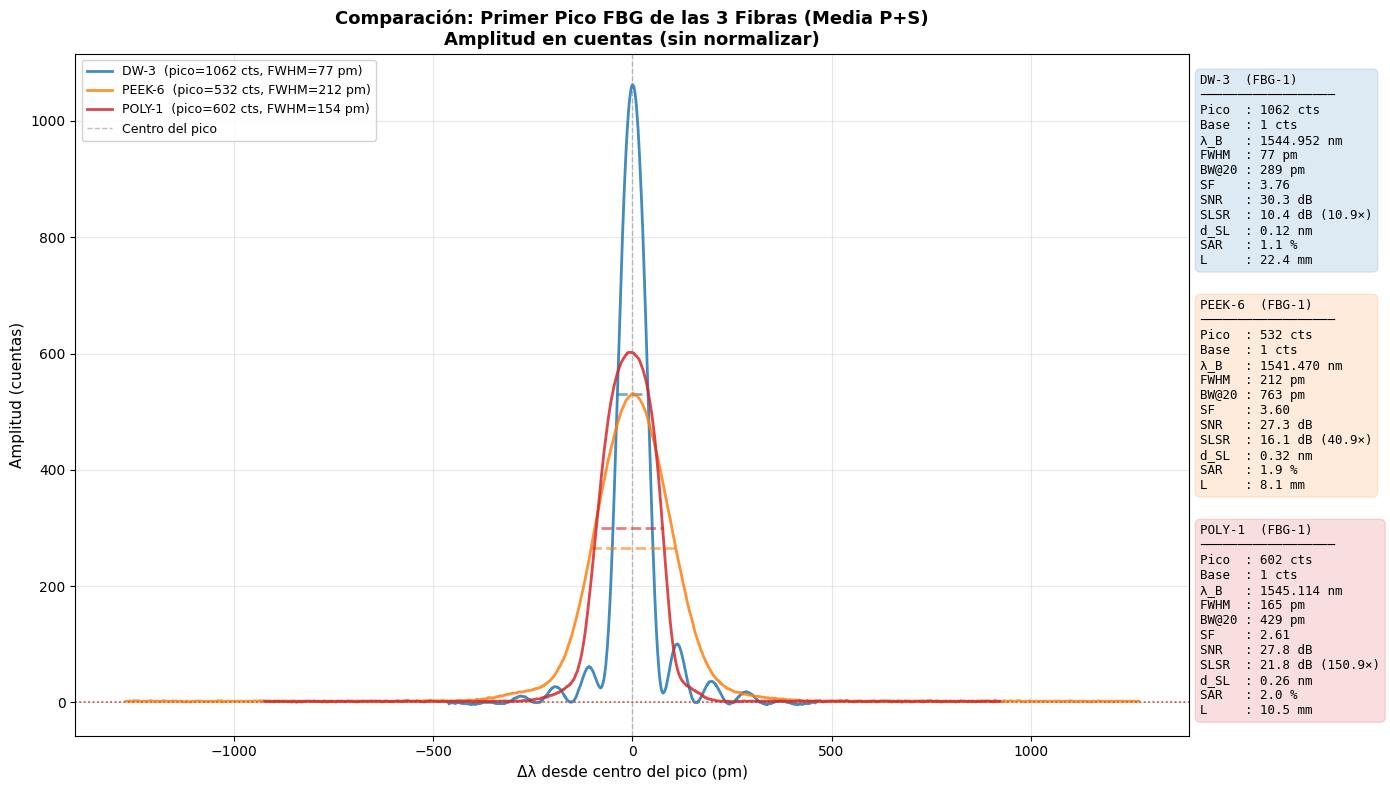

✅ Comparación en cuentas con métricas v2 completada
   Resolución: 1.00 pm/pt | Eje X en pm


In [21]:
if data_spectrum is not None and 'quality_results' in locals():
    fig, ax = plt.subplots(figsize=(14, 8))

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}
    box_y_positions = {'DW-3': 0.97, 'PEEK-6': 0.64, 'POLY-1': 0.31}

    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in fbg_analysis_results or fiber_name not in quality_results:
            continue

        peaks_p = fbg_analysis_results[fiber_name]['Pol P']
        valid_p = [p for p in peaks_p
                   if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]
        if len(valid_p) == 0:
            continue

        peak = valid_p[0]
        ch = list(channel_names.values()).index(fiber_name)
        sig_p = spectrum_wav[idx_espectro, 0, ch, :]
        sig_s = spectrum_wav[idx_espectro, 1, ch, :]
        signal = (sig_p + sig_s) / 2.0

        peak_idx = peak['peak_idx']
        zoom = int(peak['fwhm'] * 6)
        x0 = max(0, peak_idx - zoom)
        x1 = min(n_puntos, peak_idx + zoom)

        # Eje en Δλ (pm)
        x_pm = (np.arange(x0, x1) - peak_idx) * dlam_nm_per_pt * 1e3
        y_counts = signal[x0:x1]

        color = colors_fiber[fiber_name]
        fwhm_pm = peak['fwhm'] * dlam_nm_per_pt * 1e3
        peak_amp = signal[peak_idx]
        lam_b = idx_to_wavelength(peak_idx)

        ax.plot(x_pm, y_counts, color=color, linewidth=2, alpha=0.85,
                label=f"{fiber_name}  (pico={peak_amp:.0f} cts, FWHM={fwhm_pm:.0f} pm)")

        # FWHM line
        half_amp = peak_amp / 2.0
        l_ip_pm = (peak['left_ip'] - peak_idx) * dlam_nm_per_pt * 1e3
        r_ip_pm = (peak['right_ip'] - peak_idx) * dlam_nm_per_pt * 1e3
        ax.hlines(half_amp, l_ip_pm, r_ip_pm, color=color, linestyle='--',
                  linewidth=2, alpha=0.6)

        # Métricas promedio P+S
        mp = quality_results[fiber_name].get((1, 'Pol P'), {})
        ms = quality_results[fiber_name].get((1, 'Pol S'), {})

        def avg(key):
            vals = [m.get(key, np.nan) for m in [mp, ms]]
            vals = [v for v in vals if not np.isnan(v)]
            return np.mean(vals) if vals else np.nan

        bl      = avg('baseline_loc')
        snr     = avg('snr_db')
        slsr    = avg('slsr_db')
        slsr_r  = avg('slsr_ratio')
        d_sl    = avg('sidelobe_dist_nm')
        sar     = avg('sar_pct')
        l_fbg   = avg('fbg_length_mm')
        bw20    = avg('bw_20db_pm')
        sf      = avg('shape_factor')

        # Baseline line
        if not np.isnan(bl):
            ax.axhline(bl, color=color, linestyle=':', linewidth=1.2, alpha=0.5)

        def fmt(v, fs):
            return fs.format(v) if not (isinstance(v, float) and np.isnan(v)) else "N/A"

        info = (
            f"{fiber_name}  (FBG-1)\n"
            f"──────────────────\n"
            f"Pico  : {peak_amp:.0f} cts\n"
            f"Base  : {fmt(bl,'{:.0f}')} cts\n"
            f"λ_B   : {lam_b:.3f} nm\n"
            f"FWHM  : {fmt(avg('bw_3db_pm'),'{:.0f}')} pm\n"
            f"BW@20 : {fmt(bw20,'{:.0f}')} pm\n"
            f"SF    : {fmt(sf,'{:.2f}')}\n"
            f"SNR   : {fmt(snr,'{:.1f}')} dB\n"
            f"SLSR  : {fmt(slsr,'{:.1f}')} dB ({fmt(slsr_r,'{:.1f}')}×)\n"
            f"d_SL  : {fmt(d_sl,'{:.2f}')} nm\n"
            f"SAR   : {fmt(sar,'{:.1f}')} %\n"
            f"L     : {fmt(l_fbg,'{:.1f}')} mm"
        )

        ax.text(1.01, box_y_positions[fiber_name], info,
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color,
                          alpha=0.15, edgecolor=color),
                color='black', fontfamily='monospace')

    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5,
               label='Centro del pico')

    ax.set_xlabel('Δλ desde centro del pico (pm)', fontsize=11)
    ax.set_ylabel('Amplitud (cuentas)', fontsize=11)
    ax.set_title('Comparación: Primer Pico FBG de las 3 Fibras (Media P+S)\n'
                 'Amplitud en cuentas (sin normalizar)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left', framealpha=0.85)

    plt.tight_layout()
    plt.show()

    print("✅ Comparación en cuentas con métricas v2 completada")
    print(f"   Resolución: {dlam_nm_per_pt*1e3:.2f} pm/pt | Eje X en pm")

## 9️⃣ Insertion Loss Acumulativa del Array FBG

En un array FBG en serie, la luz debe **atravesar** cada grating intermedio **dos veces** (ida y vuelta) para llegar a los sensores más lejanos. Cada FBG refleja una fracción $R_i$, así que la potencia que alcanza el FBG-$j$ es:

$$P_{\text{reflejada},j} = P_0 \cdot R_j \cdot \prod_{i<j}(1-R_i)^2$$

Como no conocemos $R_i$ individualmente (ver nota sobre reflectividad absoluta en §6), estimamos la **insertion loss acumulativa** comparando las amplitudes de pico sucesivas:

$$\text{IL}_k = -10 \cdot \log_{10}\!\left(\frac{\text{Amp}_k}{\text{Amp}_1}\right) \div 2$$

Se divide por 2 porque la pérdida acumulada se reparte entre ida y vuelta. **Criterio: IL total < 1.5 dB**.

⚠️ Esta estimación es **indirecta**: asume reflectividades similares entre FBGs. Si un FBG tiene $R$ diferente, su amplitud cambia sin que haya más pérdida real. Una medida directa requeriría fuente broadband + powermeter en transmisión.

/tmp/vgarciap/ipykernel_2558287/1203674564.py:111: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/afs/cern.ch/user/v/vgarciap/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


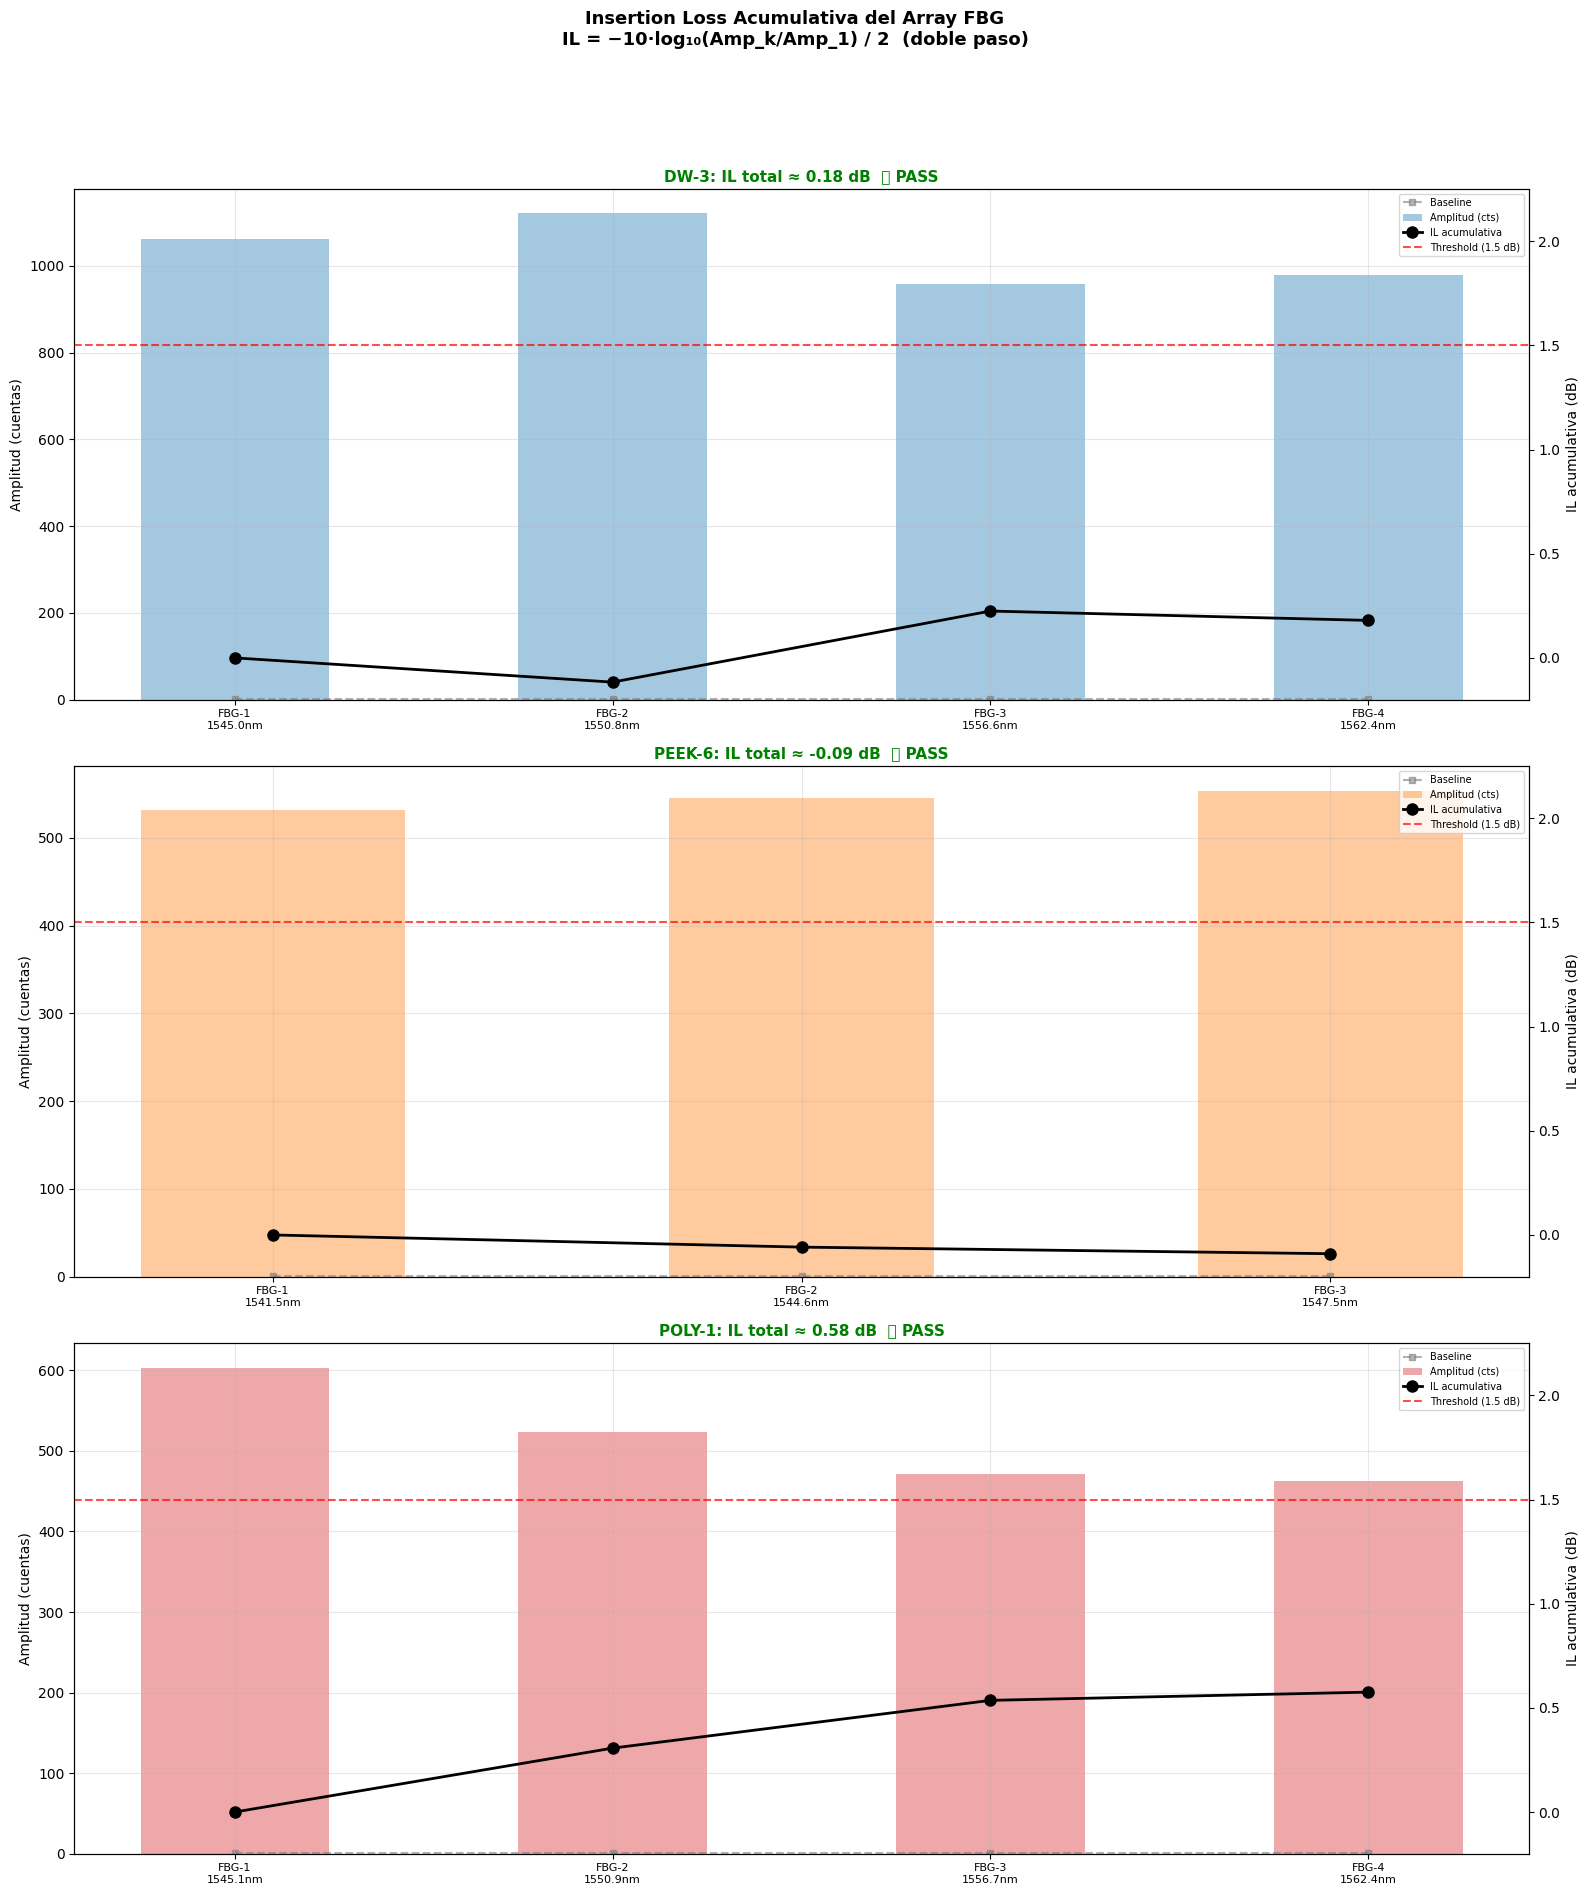

📊 INSERTION LOSS ACUMULATIVA POR FIBRA:
Fibra      N_sens      Amp_1    Amp_N   IL_total     Criterio
────────────────────────────────────────────────────────────
DW-3       4            1062      978      0.180   ✅ < 1.5 dB
PEEK-6     3             532      554     -0.090   ✅ < 1.5 dB
POLY-1     4             604      463      0.575   ✅ < 1.5 dB

⚠️  NOTA: Esta es una estimación INDIRECTA de la IL.
   Asume gratings similares; variaciones de R entre FBGs afectan la estimación.
   Una medida directa requeriría fuente broadband + powermeter en transmisión.


In [22]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Insertion Loss acumulativa — estimación desde amplitudes reflejadas
    # ══════════════════════════════════════════════════════════════════════

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}
    il_results = {}

    fig, axes = plt.subplots(3, 1, figsize=(16, 18))

    for fi, fiber_name in enumerate(['DW-3', 'PEEK-6', 'POLY-1']):
        if fiber_name not in quality_results:
            continue

        ax = axes[fi]
        ch = list(channel_names.values()).index(fiber_name)

        # Recoger amplitudes media P+S por sensor, ordenadas por λ
        sensor_data = []
        n_sens_max = max(k[0] for k in quality_results[fiber_name].keys())
        for s in range(1, n_sens_max + 1):
            rp = quality_results[fiber_name].get((s, 'Pol P'), {})
            rs = quality_results[fiber_name].get((s, 'Pol S'), {})
            amp_p = rp.get('peak_amp', np.nan)
            amp_s = rs.get('peak_amp', np.nan)
            lam = rp.get('lambda_nm', rs.get('lambda_nm', np.nan))
            bl_p = rp.get('baseline_loc', np.nan)
            bl_s = rs.get('baseline_loc', np.nan)
            vals = [v for v in [amp_p, amp_s] if not np.isnan(v)]
            bls = [v for v in [bl_p, bl_s] if not np.isnan(v)]
            if vals:
                sensor_data.append({
                    'sensor': s, 'lambda_nm': lam,
                    'amp_mean': np.mean(vals),
                    'bl_mean': np.mean(bls) if bls else np.nan,
                    'amp_p': amp_p, 'amp_s': amp_s
                })

        if len(sensor_data) < 2:
            ax.text(0.5, 0.5, 'Insuficientes sensores', transform=ax.transAxes,
                    ha='center', va='center')
            continue

        sensor_data.sort(key=lambda x: x['lambda_nm'])
        sensors = [d['sensor'] for d in sensor_data]
        amps = [d['amp_mean'] for d in sensor_data]
        bls = [d['bl_mean'] for d in sensor_data]
        lambdas = [d['lambda_nm'] for d in sensor_data]

        # IL acumulativa relativa al primer sensor
        amp0 = amps[0]
        il_cumulative = [0.0]  # FBG-1 → 0 dB
        for k in range(1, len(amps)):
            if amps[k] > 0 and amp0 > 0:
                # IL = -10·log10(Amp_k / Amp_1) / 2  (doble paso)
                il = -10.0 * np.log10(amps[k] / amp0) / 2.0
                il_cumulative.append(il)
            else:
                il_cumulative.append(np.nan)

        il_total = il_cumulative[-1] if not np.isnan(il_cumulative[-1]) else np.nan
        pass_il = (not np.isnan(il_total)) and (il_total < IL_TOTAL_THRESH_DB)

        il_results[fiber_name] = {
            'sensors': sensors, 'lambdas': lambdas,
            'amplitudes': amps, 'baselines': bls,
            'il_cumulative': il_cumulative, 'il_total': il_total,
            'pass_il': pass_il,
        }

        # ── Plot ──
        x = np.arange(len(sensors))
        lbls = [f'FBG-{s}\n{l:.1f}nm' for s, l in zip(sensors, lambdas)]

        color = colors_fiber[fiber_name]

        # Barras de amplitud
        ax2 = ax.twinx()
        ax.bar(x, amps, 0.5, color=color, alpha=0.4, label='Amplitud (cts)')

        # Línea de IL acumulativa
        ax2.plot(x, il_cumulative, 'ko-', linewidth=2, markersize=8, label='IL acumulativa')
        ax2.axhline(IL_TOTAL_THRESH_DB, color='red', linestyle='--', linewidth=1.5,
                    alpha=0.7, label=f'Threshold ({IL_TOTAL_THRESH_DB} dB)')
        ax2.set_ylabel('IL acumulativa (dB)', fontsize=10)
        ax2.set_ylim(-0.2, max(IL_TOTAL_THRESH_DB * 1.5, max(c for c in il_cumulative if not np.isnan(c)) * 1.3 + 0.1) if any(not np.isnan(c) for c in il_cumulative) else 3.0)

        # Baselines (si hay tendencia)
        if all(not np.isnan(b) for b in bls):
            ax.plot(x, bls, 's--', color='gray', markersize=5, alpha=0.6, label='Baseline')

        ax.set_xticks(x)
        ax.set_xticklabels(lbls, fontsize=8)
        ax.set_ylabel('Amplitud (cuentas)', fontsize=10)

        result_str = f"✅ PASS" if pass_il else f"❌ FAIL"
        il_str = f"{il_total:.2f}" if not np.isnan(il_total) else "N/A"
        ax.set_title(f'{fiber_name}: IL total ≈ {il_str} dB  {result_str}',
                     fontsize=11, fontweight='bold',
                     color='green' if pass_il else 'red')

        # Combinar leyendas
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Insertion Loss Acumulativa del Array FBG\n'
                 'IL = −10·log₁₀(Amp_k/Amp_1) / 2  (doble paso)',
                 fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    # Resumen numérico
    print("📊 INSERTION LOSS ACUMULATIVA POR FIBRA:")
    print(f"{'Fibra':<10} {'N_sens':<8} {'Amp_1':>8} {'Amp_N':>8} {'IL_total':>10} {'Criterio':>12}")
    print("─" * 60)
    for fn in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fn not in il_results:
            continue
        r = il_results[fn]
        a1 = r['amplitudes'][0]
        aN = r['amplitudes'][-1]
        il = r['il_total']
        ok = "✅ < 1.5 dB" if r['pass_il'] else "❌ > 1.5 dB"
        il_s = f"{il:.3f}" if not np.isnan(il) else "N/A"
        print(f"{fn:<10} {len(r['sensors']):<8} {a1:>8.0f} {aN:>8.0f} {il_s:>10} {ok:>12}")

    print(f"\n⚠️  NOTA: Esta es una estimación INDIRECTA de la IL.")
    print(f"   Asume gratings similares; variaciones de R entre FBGs afectan la estimación.")
    print(f"   Una medida directa requeriría fuente broadband + powermeter en transmisión.")

## 🔟 Resumen QC: Tabla Pass/Fail por sensor

Tabla con fondo verde (PASS) o rojo (FAIL) para todas las métricas:
- **SNR > 25 dB** | **SLSR > 15 dB** | **SAR < 10%** | **SF < 5.0** | **IL < 1.5 dB** | **FWHM < 100 pm** | **L > 10 mm**

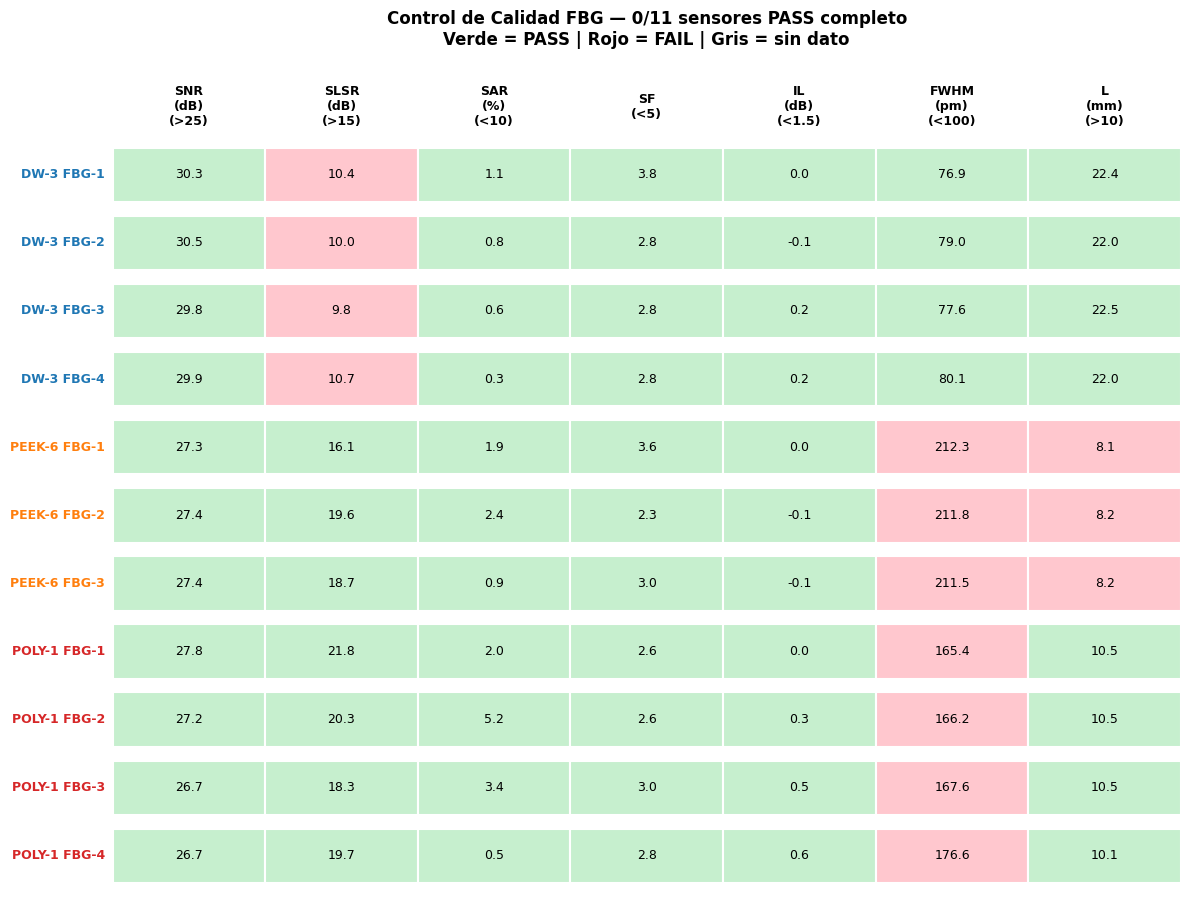

  DW-3: ❌ FBG-1: slsr=10.4; FBG-2: slsr=10.0; FBG-3: slsr=9.8; FBG-4: slsr=10.7
  PEEK-6: ❌ FBG-1: fwhm=212.3; FBG-1: L_mm=8.1; FBG-2: fwhm=211.8; FBG-2: L_mm=8.2; FBG-3: fwhm=211.5; FBG-3: L_mm=8.2
  POLY-1: ❌ FBG-1: fwhm=165.4; FBG-2: fwhm=166.2; FBG-3: fwhm=167.6; FBG-4: fwhm=176.6


In [23]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # QC Resumen: tabla visual con colores pass/fail
    # ══════════════════════════════════════════════════════════════════════

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}

    # Recoger datos (media P+S por sensor)
    qc_data = []
    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        n_max = max(k[0] for k in quality_results[fiber_name].keys())
        for s in range(1, n_max + 1):
            rp = quality_results[fiber_name].get((s, 'Pol P'), {})
            rs = quality_results[fiber_name].get((s, 'Pol S'), {})
            def avg_m(key):
                vs = [m.get(key, np.nan) for m in [rp, rs]]
                vs = [v for v in vs if not np.isnan(v)]
                return np.mean(vs) if vs else np.nan
            # IL
            il_val = np.nan
            if fiber_name in il_results:
                s_idx = s - 1
                if s_idx < len(il_results[fiber_name]['il_cumulative']):
                    il_val = il_results[fiber_name]['il_cumulative'][s_idx]
            qc_data.append({
                'fiber': fiber_name, 'sensor': s,
                'label': f"{fiber_name} FBG-{s}",
                'snr': avg_m('snr_db'), 'slsr': avg_m('slsr_db'),
                'sar': avg_m('sar_pct'), 'fwhm': avg_m('bw_3db_pm'),
                'sf': avg_m('shape_factor'), 'il': il_val,
                'L_mm': avg_m('fbg_length_mm'),
            })

    # Criterios: (key, label, threshold, type 'min'/'max')
    criteria = [
        ('snr',  'SNR\n(dB)',   SNR_THRESH_DB,      'min'),
        ('slsr', 'SLSR\n(dB)',  SLSR_THRESH_DB,      'min'),
        ('sar',  'SAR\n(%)',    SAR_THRESH_PCT,       'max'),
        ('sf',   'SF',          5.0,                  'max'),
        ('il',   'IL\n(dB)',    IL_TOTAL_THRESH_DB,   'max'),
        ('fwhm', 'FWHM\n(pm)', FWHM_THRESH_PM,       'max'),
        ('L_mm', 'L\n(mm)',    L_THRESH_MM,            'min'),
    ]
    info_cols = []  # Todas las métricas ahora tienen criterio pass/fail

    n_rows = len(qc_data)
    n_crit = len(criteria)
    n_info = len(info_cols)
    n_cols = n_crit + n_info

    fig, ax = plt.subplots(figsize=(12, 0.6 * n_rows + 2.5))
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows + 1)
    ax.axis('off')

    # Header row
    for j, (_, lbl, thr, tt) in enumerate(criteria):
        sign = '>' if tt == 'min' else '<'
        ax.text(j + 0.5, n_rows + 0.5, f"{lbl}\n({sign}{thr:g})",
                ha='center', va='center', fontsize=9, fontweight='bold')
    for j, (_, lbl) in enumerate(info_cols):
        ax.text(n_crit + j + 0.5, n_rows + 0.5, lbl,
                ha='center', va='center', fontsize=9, fontweight='bold')

    # Data rows
    for i, d in enumerate(qc_data):
        y = n_rows - i - 0.5
        # Row label
        ax.text(-0.05, y, d['label'], ha='right', va='center', fontsize=9, fontweight='bold',
                color=colors_fiber[d['fiber']])

        for j, (key, _, thr, tt) in enumerate(criteria):
            v = d[key]
            if isinstance(v, float) and np.isnan(v):
                color = '#dddddd'; txt = '—'
            elif (tt == 'min' and v >= thr) or (tt == 'max' and v <= thr):
                color = '#c6efce'; txt = f'{v:.1f}'  # green
            else:
                color = '#ffc7ce'; txt = f'{v:.1f}'  # red
            rect = plt.Rectangle((j, y - 0.4), 1, 0.8, facecolor=color,
                                  edgecolor='white', linewidth=1.5)
            ax.add_patch(rect)
            ax.text(j + 0.5, y, txt, ha='center', va='center', fontsize=9)

        for j, (key, _) in enumerate(info_cols):
            v = d[key]
            txt = f'{v:.0f}' if key == 'fwhm' else (f'{v:.1f}' if not np.isnan(v) else '—')
            rect = plt.Rectangle((n_crit + j, y - 0.4), 1, 0.8,
                                  facecolor='#f0f0f0', edgecolor='white', linewidth=1.5)
            ax.add_patch(rect)
            ax.text(n_crit + j + 0.5, y, txt, ha='center', va='center', fontsize=9)

    # Count pass/fail totals
    n_total = len(qc_data)
    n_all_pass = sum(1 for d in qc_data if all(
        (isinstance(d[k], float) and np.isnan(d[k])) or
        (tt == 'min' and d[k] >= thr) or (tt == 'max' and d[k] <= thr)
        for k, _, thr, tt in criteria))

    ax.set_title(f'Control de Calidad FBG — {n_all_pass}/{n_total} sensores PASS completo\n'
                 f'Verde = PASS | Rojo = FAIL | Gris = sin dato',
                 fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    # Text summary
    for fn in ['DW-3', 'PEEK-6', 'POLY-1']:
        fd = [d for d in qc_data if d['fiber'] == fn]
        if not fd:
            continue
        fails = []
        for d in fd:
            for k, _, thr, tt in criteria:
                v = d[k]
                if isinstance(v, float) and np.isnan(v):
                    continue
                if (tt == 'min' and v < thr) or (tt == 'max' and v > thr):
                    fails.append(f"FBG-{d['sensor']}: {k}={v:.1f}")
        if fails:
            print(f"  {fn}: ❌ {'; '.join(fails)}")
        else:
            print(f"  {fn}: ✅ Todos PASS")

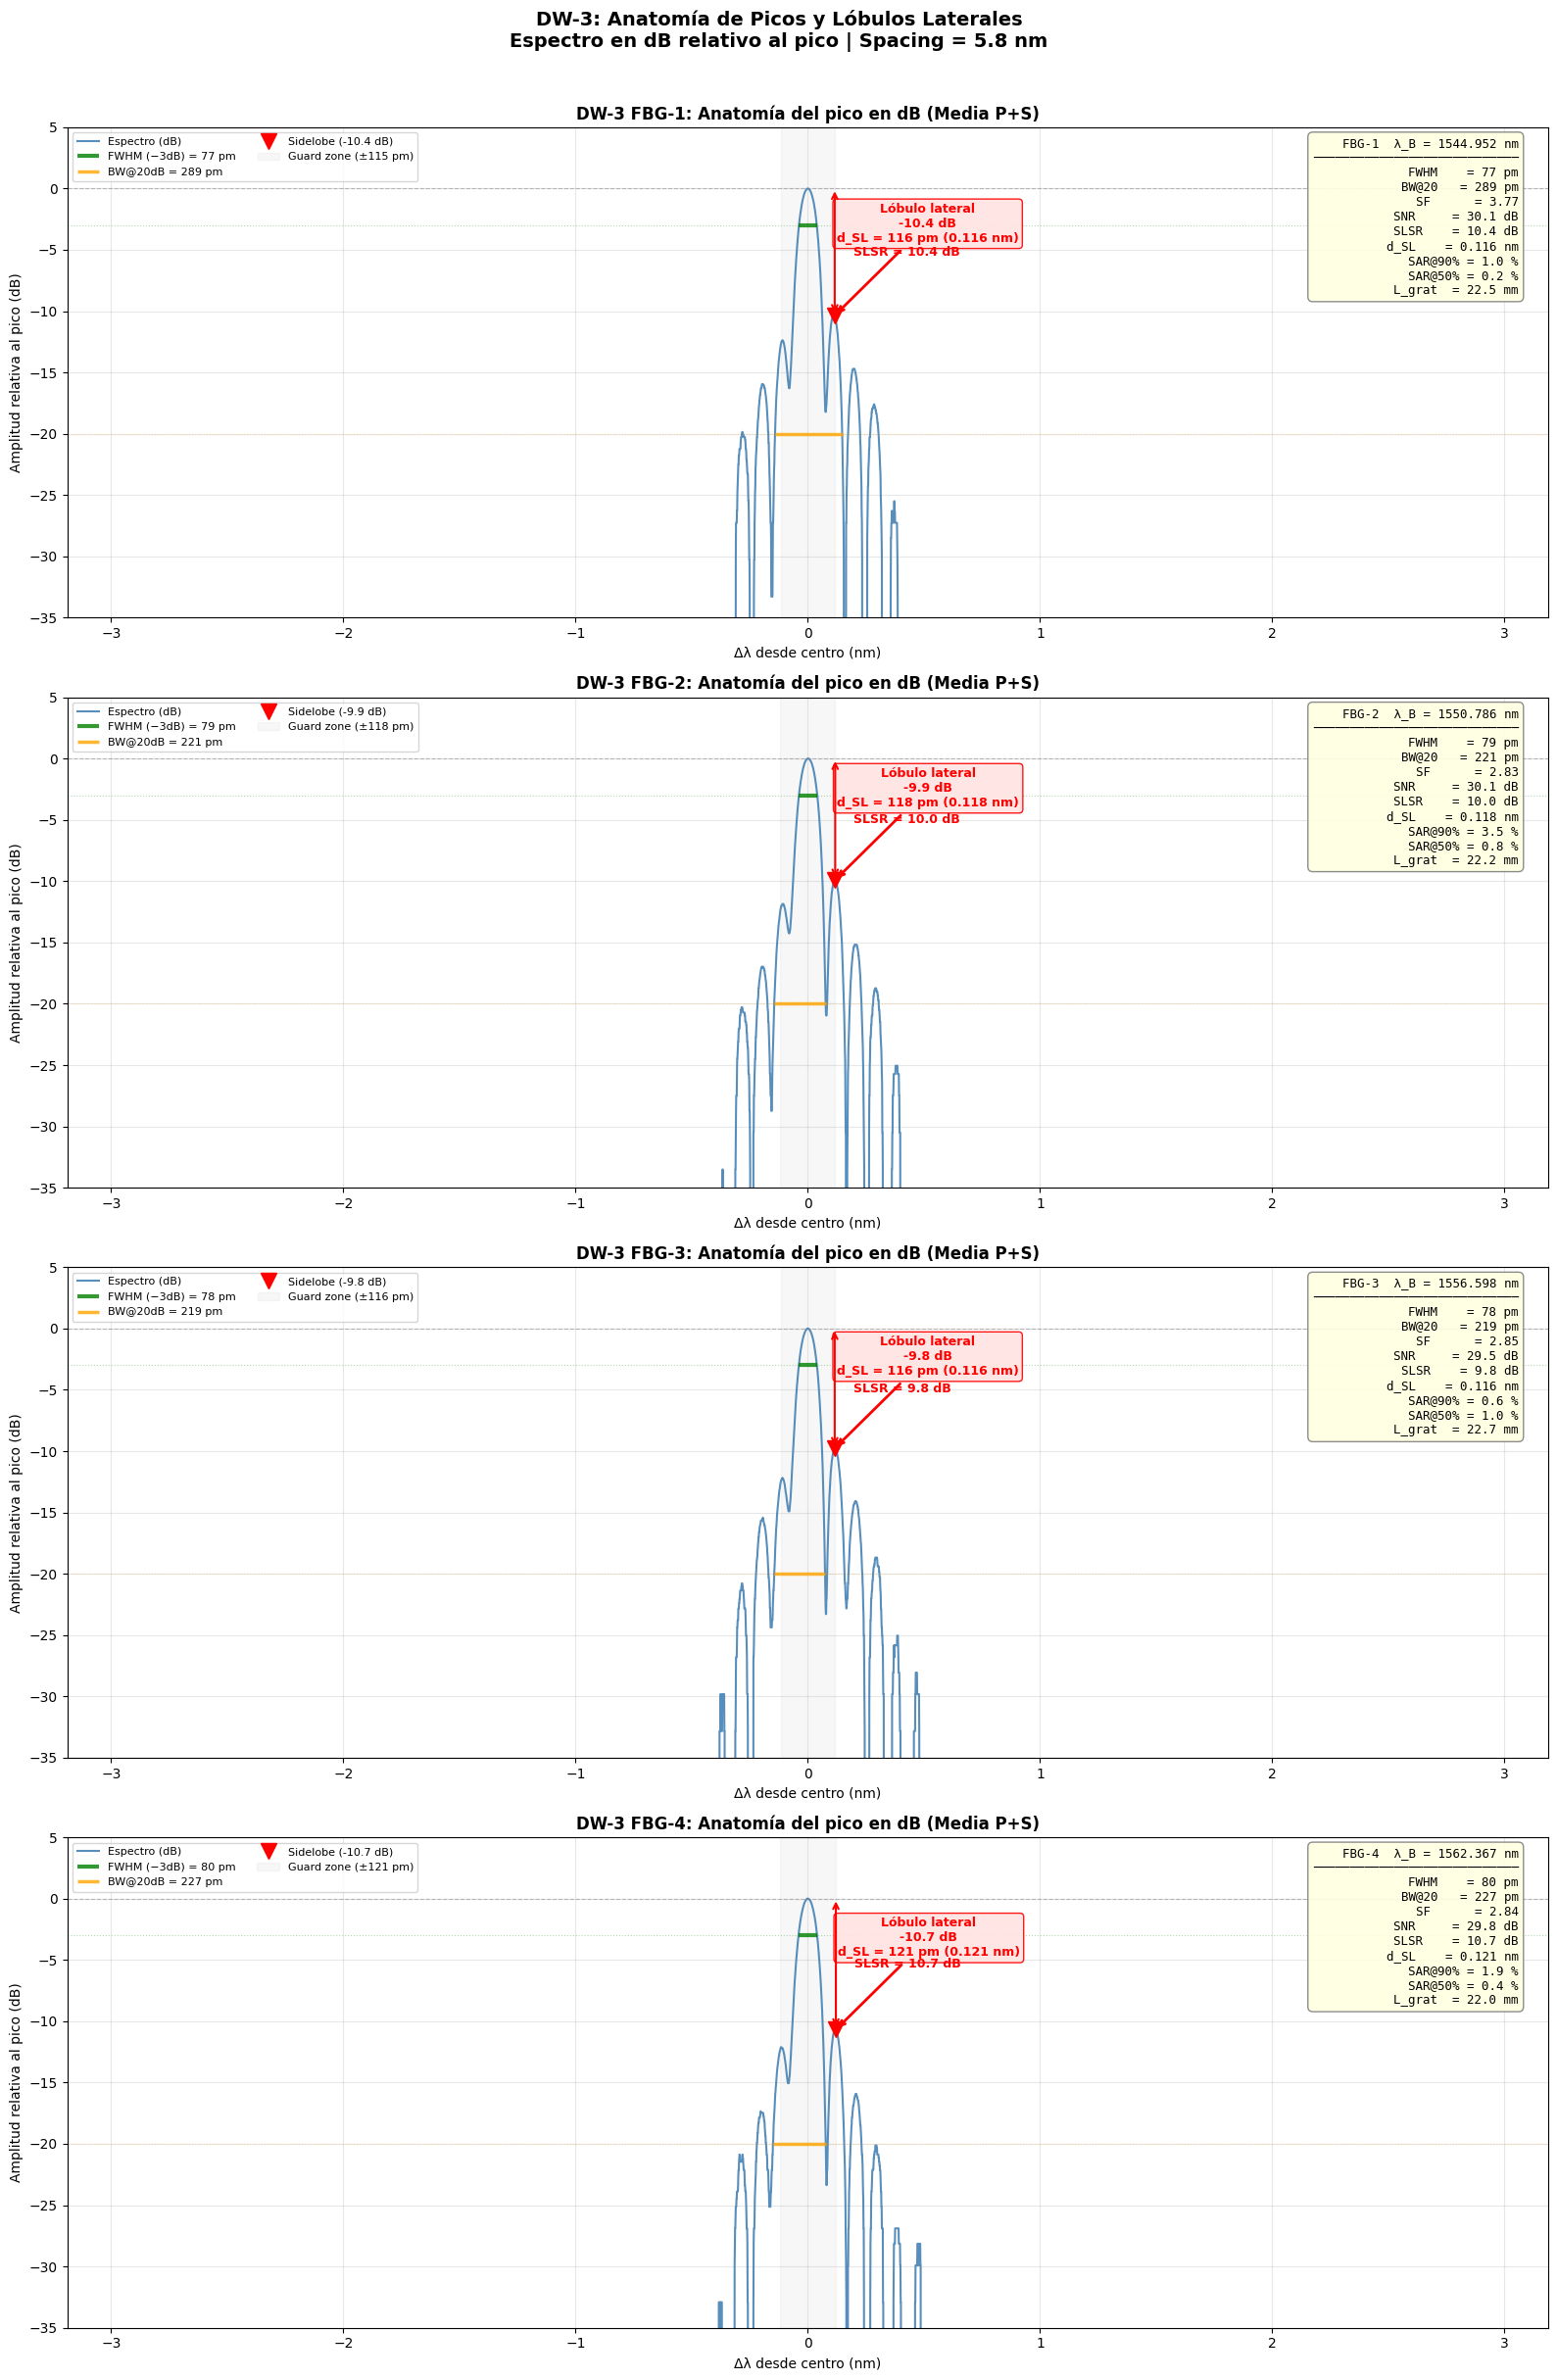


📊 DW-3: Análisis detallado de lóbulos laterales
   Ventana de búsqueda: inner guard = 1.5×FWHM, outer = spacing/2 = 2.9 nm
   Para FBG uniforme (no apodizado): SLSR teórico ≈ 13.3 dB, d_SL ≈ 1.39×FWHM
   Línea verde = FWHM (−3 dB) | Línea naranja = BW@20 (−20 dB)
   Triángulo rojo = posición del lóbulo lateral máximo detectado
   Zona gris = guard zone excluida de la búsqueda de lóbulos


In [24]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # 🔍 DW-3: Anatomía de Picos y Lóbulos Laterales
    # Plot detallado en dB: FWHM, BW@20, sidelobes, SLSR, d_SL anotados
    # ══════════════════════════════════════════════════════════════════════

    fiber_name = 'DW-3'
    if fiber_name not in quality_results:
        print(f"⚠️ {fiber_name} no encontrada")
    else:
        ch = list(channel_names.values()).index(fiber_name)
        n_sensors = DESIGN_N_SENSORS[fiber_name]

        fig, axes = plt.subplots(n_sensors, 1, figsize=(16, 6 * n_sensors))
        if n_sensors == 1:
            axes = [axes]

        sig_p = spectrum_wav[idx_espectro, 0, ch, :]
        sig_s = spectrum_wav[idx_espectro, 1, ch, :]
        signal = (sig_p + sig_s) / 2.0

        peaks_p = fbg_analysis_results[fiber_name].get('Pol P', [])
        valid = [p for p in peaks_p
                 if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

        spacing_nm = DESIGN_SPACING[fiber_name]

        for s_idx, peak in enumerate(valid):
            ax = axes[s_idx]
            pidx = peak['peak_idx']
            fwhm_pts = peak['fwhm']
            fwhm_nm = fwhm_pts * dlam_nm_per_pt
            lam_b = idx_to_wavelength(pidx)

            # Ventana amplia: hasta spacing/2
            half_win_nm = min(spacing_nm / 2.0, 4.0)
            half_win_pts = int(half_win_nm / dlam_nm_per_pt)

            x0 = max(0, pidx - half_win_pts)
            x1 = min(n_puntos, pidx + half_win_pts)

            # Signal in dB relative to peak
            seg = signal[x0:x1].copy()
            peak_val = signal[pidx]
            with np.errstate(divide='ignore', invalid='ignore'):
                seg_db = np.where(seg > 0, 10 * np.log10(seg / peak_val), -60)

            x_nm = (np.arange(x0, x1) - pidx) * dlam_nm_per_pt

            ax.plot(x_nm, seg_db, 'steelblue', linewidth=1.5, alpha=0.9, label='Espectro (dB)')

            # Mark FWHM level (-3 dB)
            bw3, l3, r3 = compute_bandwidth_pm(signal, pidx, 3.0)
            if not np.isnan(bw3):
                l3_nm = (l3 - pidx) * dlam_nm_per_pt
                r3_nm = (r3 - pidx) * dlam_nm_per_pt
                ax.hlines(-3, l3_nm, r3_nm, color='green', linewidth=3, alpha=0.8,
                         label=f'FWHM (−3dB) = {bw3:.0f} pm')
                ax.axhline(-3, color='green', linestyle=':', linewidth=0.8, alpha=0.3)

            # Mark BW@20 level (-20 dB)
            bw20, l20, r20 = compute_bandwidth_pm(signal, pidx, 20.0)
            if not np.isnan(bw20):
                l20_nm = (l20 - pidx) * dlam_nm_per_pt
                r20_nm = (r20 - pidx) * dlam_nm_per_pt
                ax.hlines(-20, l20_nm, r20_nm, color='orange', linewidth=2.5, alpha=0.8,
                         label=f'BW@20dB = {bw20:.0f} pm')
                ax.axhline(-20, color='orange', linestyle=':', linewidth=0.8, alpha=0.3)

            # SLSR info from quality_results
            r_q = quality_results[fiber_name].get((s_idx+1, 'Pol P'), {})
            slsr_db = r_q.get('slsr_db', np.nan)
            d_sl_nm = r_q.get('sidelobe_dist_nm', np.nan)
            sar_90 = r_q.get('sar_90_pct', np.nan)
            sar_50 = r_q.get('sar_50_pct', np.nan)

            if not np.isnan(slsr_db) and not np.isnan(d_sl_nm):
                # Find sidelobe position (recompute for plot)
                inner_nm = max(1.5 * fwhm_nm, 0.1)
                inner_pts = int(inner_nm / dlam_nm_per_pt)
                outer_pts = int(half_win_nm / dlam_nm_per_pt)

                ls = max(0, pidx - outer_pts)
                le = max(0, pidx - inner_pts)
                rs = min(n_puntos, pidx + inner_pts + 1)
                re = min(n_puntos, pidx + outer_pts + 1)

                lr = signal[ls:le] if le > ls else np.array([])
                rr = signal[rs:re] if re > rs else np.array([])

                ml = np.max(lr) if len(lr) > 0 else 0
                mr = np.max(rr) if len(rr) > 0 else 0

                if ml >= mr and len(lr) > 0:
                    sl_idx = ls + int(np.argmax(lr))
                elif len(rr) > 0:
                    sl_idx = rs + int(np.argmax(rr))
                else:
                    sl_idx = None

                if sl_idx is not None:
                    sl_x_nm = (sl_idx - pidx) * dlam_nm_per_pt
                    sl_y_db = 10 * np.log10(signal[sl_idx] / peak_val) if signal[sl_idx] > 0 else -60

                    # Annotate sidelobe with arrow
                    ax.annotate(
                        f'Lóbulo lateral\n{sl_y_db:.1f} dB\n'
                        f'd_SL = {abs(sl_x_nm)*1e3:.0f} pm ({abs(sl_x_nm):.3f} nm)',
                        xy=(sl_x_nm, sl_y_db),
                        xytext=(sl_x_nm + (0.4 if sl_x_nm >= 0 else -0.4), sl_y_db + 6),
                        arrowprops=dict(arrowstyle='->', color='red', lw=2),
                        fontsize=9, color='red', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose',
                                 alpha=0.9, edgecolor='red'),
                        ha='center')

                    ax.plot(sl_x_nm, sl_y_db, 'rv', markersize=12, zorder=10,
                           label=f'Sidelobe ({sl_y_db:.1f} dB)')

                    # SLSR vertical arrow
                    ax.annotate('', xy=(sl_x_nm, 0), xytext=(sl_x_nm, sl_y_db),
                               arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
                    ax.text(sl_x_nm + 0.08, sl_y_db/2,
                           f'SLSR = {slsr_db:.1f} dB',
                           fontsize=9, color='red', ha='left', va='center',
                           fontweight='bold')

            # Inner guard zone shading
            inner_nm_val = max(1.5 * fwhm_nm, 0.1)
            ax.axvspan(-inner_nm_val, inner_nm_val, alpha=0.06, color='gray',
                      label=f'Guard zone (±{inner_nm_val*1e3:.0f} pm)')

            # Info box with all parameters
            snr = r_q.get('snr_db', np.nan)
            sar = r_q.get('sar_pct', np.nan)
            sf = r_q.get('shape_factor', np.nan)
            l_mm = r_q.get('fbg_length_mm', np.nan)

            def fv(v, fs):
                return fs.format(v) if not (isinstance(v, float) and np.isnan(v)) else 'N/A'

            info = (
                f"FBG-{s_idx+1}  λ_B = {lam_b:.3f} nm\n"
                f"{'─'*28}\n"
                f"FWHM    = {fv(bw3, '{:.0f}')} pm\n"
                f"BW@20   = {fv(bw20, '{:.0f}')} pm\n"
                f"SF      = {fv(sf, '{:.2f}')}\n"
                f"SNR     = {fv(snr, '{:.1f}')} dB\n"
                f"SLSR    = {fv(slsr_db, '{:.1f}')} dB\n"
                f"d_SL    = {fv(d_sl_nm, '{:.3f}')} nm\n"
                f"SAR@90% = {fv(sar_90, '{:.1f}')} %\n"
                f"SAR@50% = {fv(sar_50, '{:.1f}')} %\n"
                f"L_grat  = {fv(l_mm, '{:.1f}')} mm"
            )

            ax.text(0.98, 0.98, info, transform=ax.transAxes,
                   fontsize=9, va='top', ha='right',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                            alpha=0.9, edgecolor='gray'),
                   fontfamily='monospace')

            ax.set_title(f'{fiber_name} FBG-{s_idx+1}: Anatomía del pico en dB (Media P+S)',
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Δλ desde centro (nm)', fontsize=10)
            ax.set_ylabel('Amplitud relativa al pico (dB)', fontsize=10)
            ax.set_ylim(-35, 5)
            ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5, linestyle='--')
            ax.legend(fontsize=8, loc='upper left', ncol=2)
            ax.grid(True, alpha=0.3)

        plt.suptitle(f'{fiber_name}: Anatomía de Picos y Lóbulos Laterales\n'
                     f'Espectro en dB relativo al pico | Spacing = {spacing_nm} nm',
                     fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

        print(f"\n📊 {fiber_name}: Análisis detallado de lóbulos laterales")
        print(f"   Ventana de búsqueda: inner guard = 1.5×FWHM, outer = spacing/2 = {spacing_nm/2:.1f} nm")
        print(f"   Para FBG uniforme (no apodizado): SLSR teórico ≈ 13.3 dB, d_SL ≈ 1.39×FWHM")
        print(f"   Línea verde = FWHM (−3 dB) | Línea naranja = BW@20 (−20 dB)")
        print(f"   Triángulo rojo = posición del lóbulo lateral máximo detectado")
        print(f"   Zona gris = guard zone excluida de la búsqueda de lóbulos")

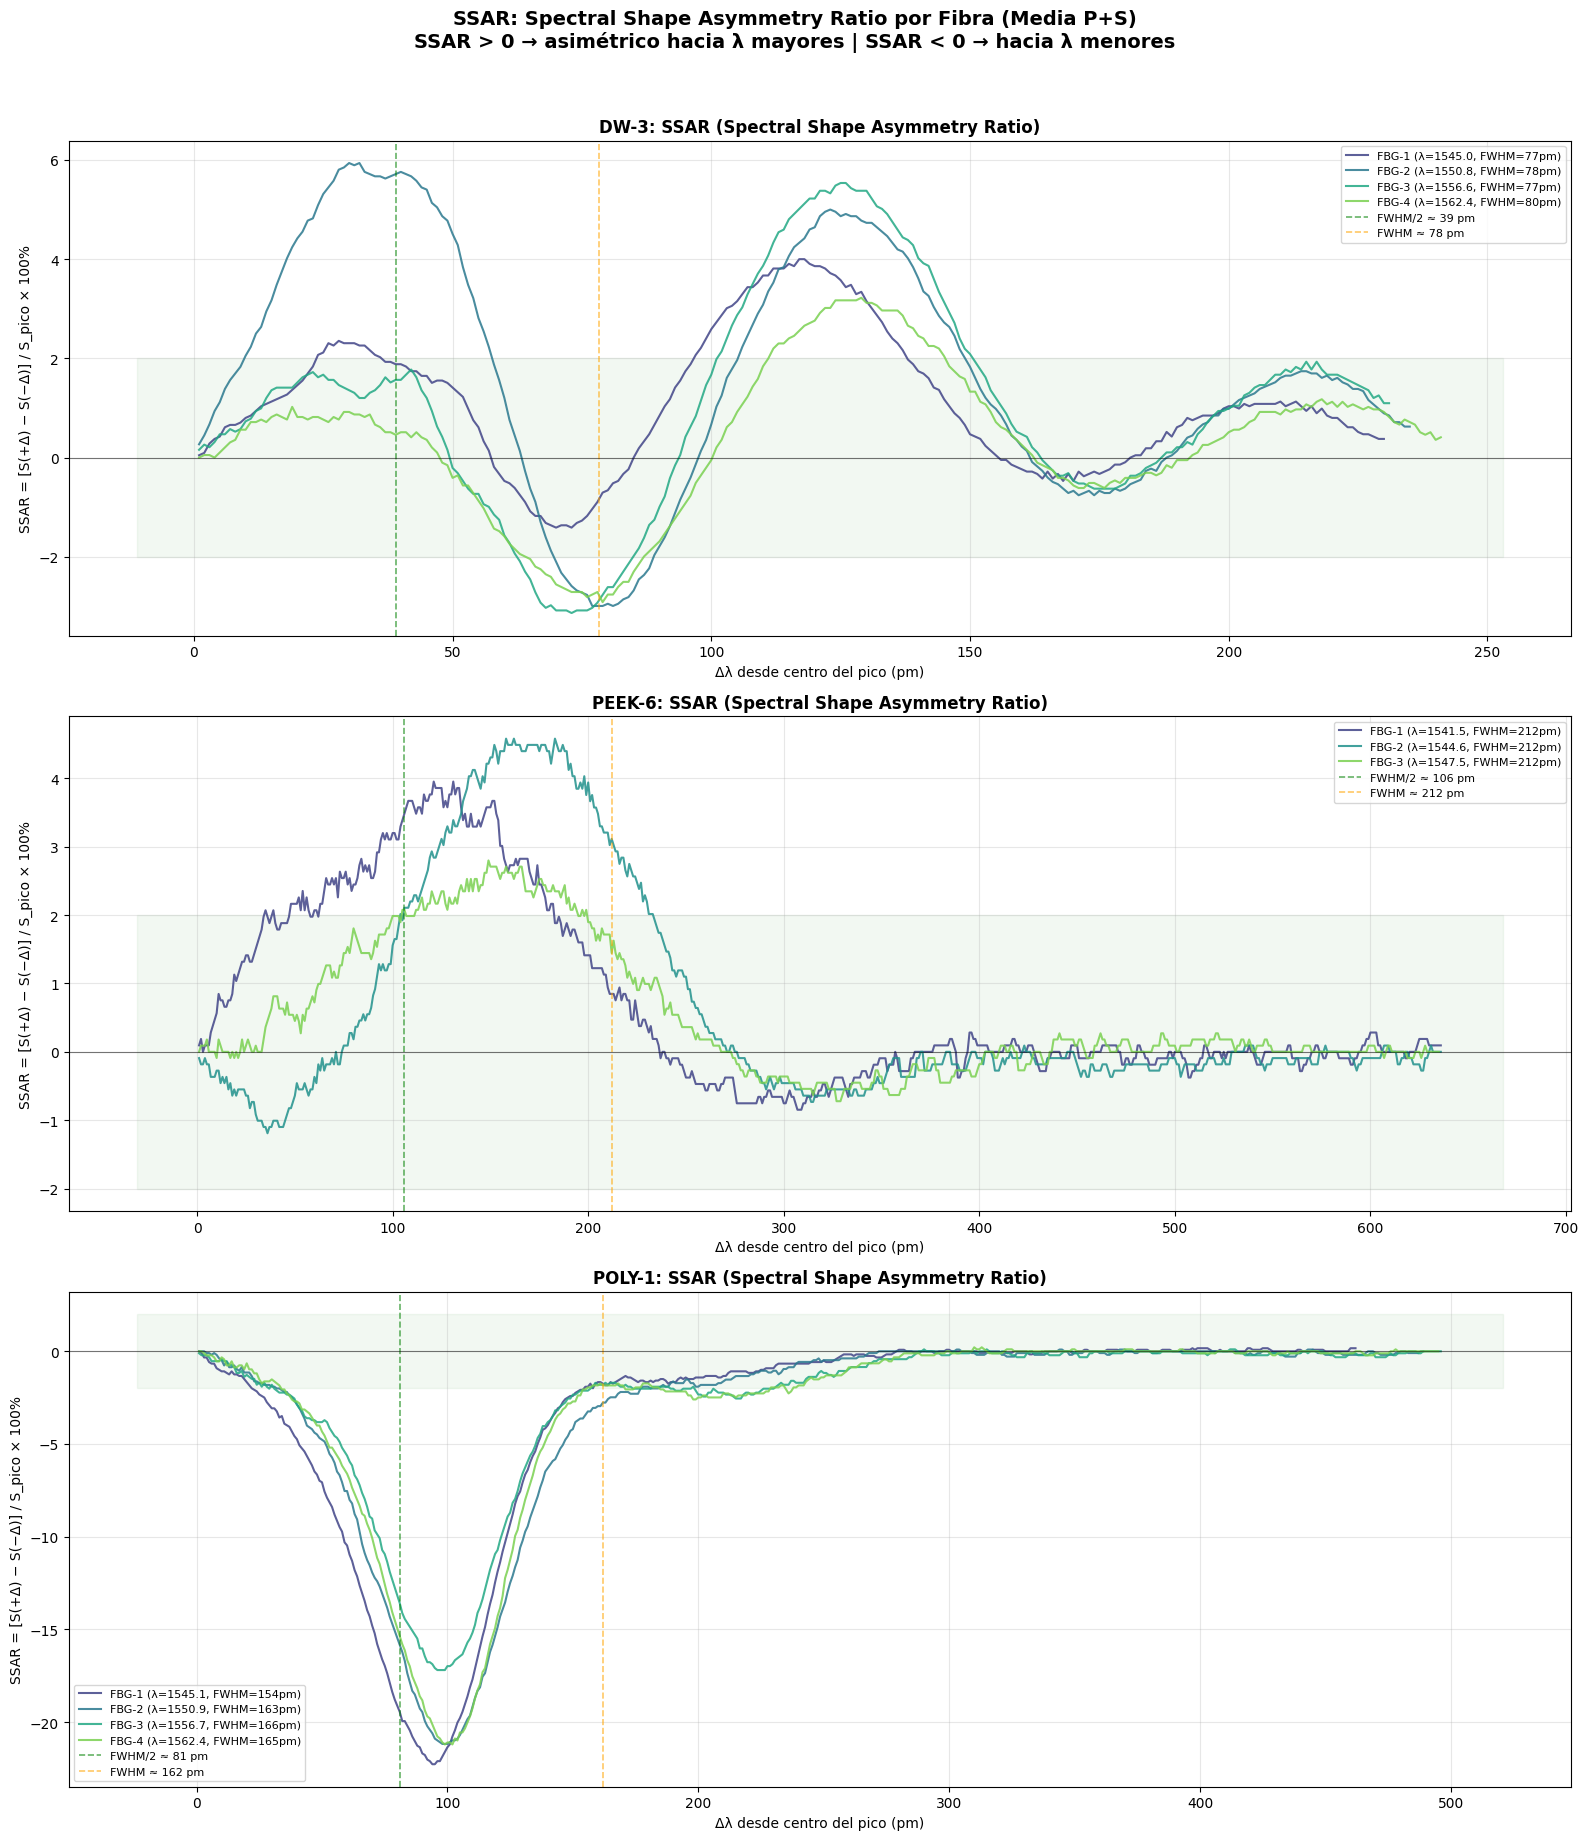

📊 SSAR — Spectral Shape Asymmetry Ratio
   SSAR(Δλ) = [S(λ_B + Δλ) − S(λ_B − Δλ)] / S(λ_B) × 100%
   → SSAR = 0% en todo Δλ → pico perfectamente simétrico
   → SSAR positivo → señal más fuerte a la derecha (λ mayores)
   → Oscilaciones en SSAR → lóbulos laterales asimétricos
   → SSAR monótono → gradiente de strain o chirp unidireccional


In [25]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # SSAR: Spectral Shape Asymmetry Ratio
    # SSAR(Δλ) = [S(λ_B + Δλ) - S(λ_B - Δλ)] / S(λ_B) × 100%
    # ══════════════════════════════════════════════════════════════════════

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}

    fig, axes = plt.subplots(3, 1, figsize=(16, 18))

    for fi, fiber_name in enumerate(['DW-3', 'PEEK-6', 'POLY-1']):
        if fiber_name not in quality_results:
            continue

        ax = axes[fi]
        ch = list(channel_names.values()).index(fiber_name)
        sig_p = spectrum_wav[idx_espectro, 0, ch, :]
        sig_s = spectrum_wav[idx_espectro, 1, ch, :]
        signal = (sig_p + sig_s) / 2.0

        peaks = fbg_analysis_results[fiber_name].get('Pol P', [])
        valid = [p for p in peaks
                 if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

        sensor_colors = plt.cm.viridis(np.linspace(0.2, 0.8, max(len(valid), 1)))

        for s_idx, peak in enumerate(valid):
            pidx = peak['peak_idx']
            fwhm_pts = peak['fwhm']
            peak_val = signal[pidx]
            lam_b = idx_to_wavelength(pidx)
            fwhm_pm = fwhm_pts * dlam_nm_per_pt * 1e3

            # SSAR up to 3× FWHM
            max_delta = int(fwhm_pts * 3)
            deltas = np.arange(1, max_delta + 1)
            ssar_vals = []
            delta_pm = []

            for d in deltas:
                i_right = pidx + d
                i_left = pidx - d
                if 0 <= i_left < n_puntos and 0 <= i_right < n_puntos and peak_val > 0:
                    ssar = (signal[i_right] - signal[i_left]) / peak_val * 100
                    ssar_vals.append(ssar)
                    delta_pm.append(d * dlam_nm_per_pt * 1e3)
                else:
                    break

            if delta_pm:
                ax.plot(delta_pm, ssar_vals, color=sensor_colors[s_idx],
                       linewidth=1.5, alpha=0.85,
                       label=f'FBG-{s_idx+1} (λ={lam_b:.1f}, FWHM={fwhm_pm:.0f}pm)')

        # Mark FWHM/2 and FWHM positions
        if valid:
            avg_fwhm_pm = np.mean([p['fwhm'] * dlam_nm_per_pt * 1e3 for p in valid])
            ax.axvline(avg_fwhm_pm / 2, color='green', linestyle='--', linewidth=1.2,
                      alpha=0.6, label=f'FWHM/2 ≈ {avg_fwhm_pm/2:.0f} pm')
            ax.axvline(avg_fwhm_pm, color='orange', linestyle='--', linewidth=1.2,
                      alpha=0.6, label=f'FWHM ≈ {avg_fwhm_pm:.0f} pm')

        ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
        ax.fill_between(ax.get_xlim() if ax.get_xlim()[1] > 0 else [0, 500],
                        -2, 2, alpha=0.05, color='green')
        ax.set_title(f'{fiber_name}: SSAR (Spectral Shape Asymmetry Ratio)',
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Δλ desde centro del pico (pm)', fontsize=10)
        ax.set_ylabel('SSAR = [S(+Δ) − S(−Δ)] / S_pico × 100%', fontsize=10)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)

    plt.suptitle('SSAR: Spectral Shape Asymmetry Ratio por Fibra (Media P+S)\n'
                 'SSAR > 0 → asimétrico hacia λ mayores | SSAR < 0 → hacia λ menores',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print("📊 SSAR — Spectral Shape Asymmetry Ratio")
    print("   SSAR(Δλ) = [S(λ_B + Δλ) − S(λ_B − Δλ)] / S(λ_B) × 100%")
    print("   → SSAR = 0% en todo Δλ → pico perfectamente simétrico")
    print("   → SSAR positivo → señal más fuerte a la derecha (λ mayores)")
    print("   → Oscilaciones en SSAR → lóbulos laterales asimétricos")
    print("   → SSAR monótono → gradiente de strain o chirp unidireccional")

## 1️⃣1️⃣ Análisis de Picos Anchos: POLY-1 vs DW-3

### ¿Por qué POLY-1 tiene picos tan anchos?

POLY-1 (recubierta de poliamida) muestra FWHM significativamente mayor que DW-3 (ormocer-T).
Posibles causas:

1. **Grating más corto** → L_FBG menor → FWHM mayor (relación inversa $\Delta\lambda \propto 1/L$)
2. **Gradiente de strain** del coating de poliamida → ensanchamiento por chirp no intencionado
3. **Variación térmica** a lo largo del grating (efecto del coating grueso)
4. **Calidad de escritura** — el proceso de inscripción puede ser menos uniforme en poliamida

### Comparación directa
- DW-3 y POLY-1 tienen el mismo spacing de diseño (~5.8 nm)
- Superponemos los picos de ambas fibras normalizados para comparar la forma
- Analizamos el Shape Factor (SF = BW@20dB/FWHM) para distinguir chirp de grating corto

**Interpretación del Shape Factor:**
- SF ≈ 2.8–3.0 → perfil Gaussiano (grating apodizado o corto)
- SF ≈ 4.5–4.7 → perfil sinc² (grating uniforme largo)
- SF > 5.0 → indica chirp significativo o estructura irregular
- SF < 2.5 → pico flat-top (grating fuertemente apodizado)

### Nota sobre POLY-1
Se han definido 4 sensores visibles en el rango del interrogador (1529–1568 nm).
Existe un 5º sensor fuera de rango a temperatura ambiente — no se analiza aquí.

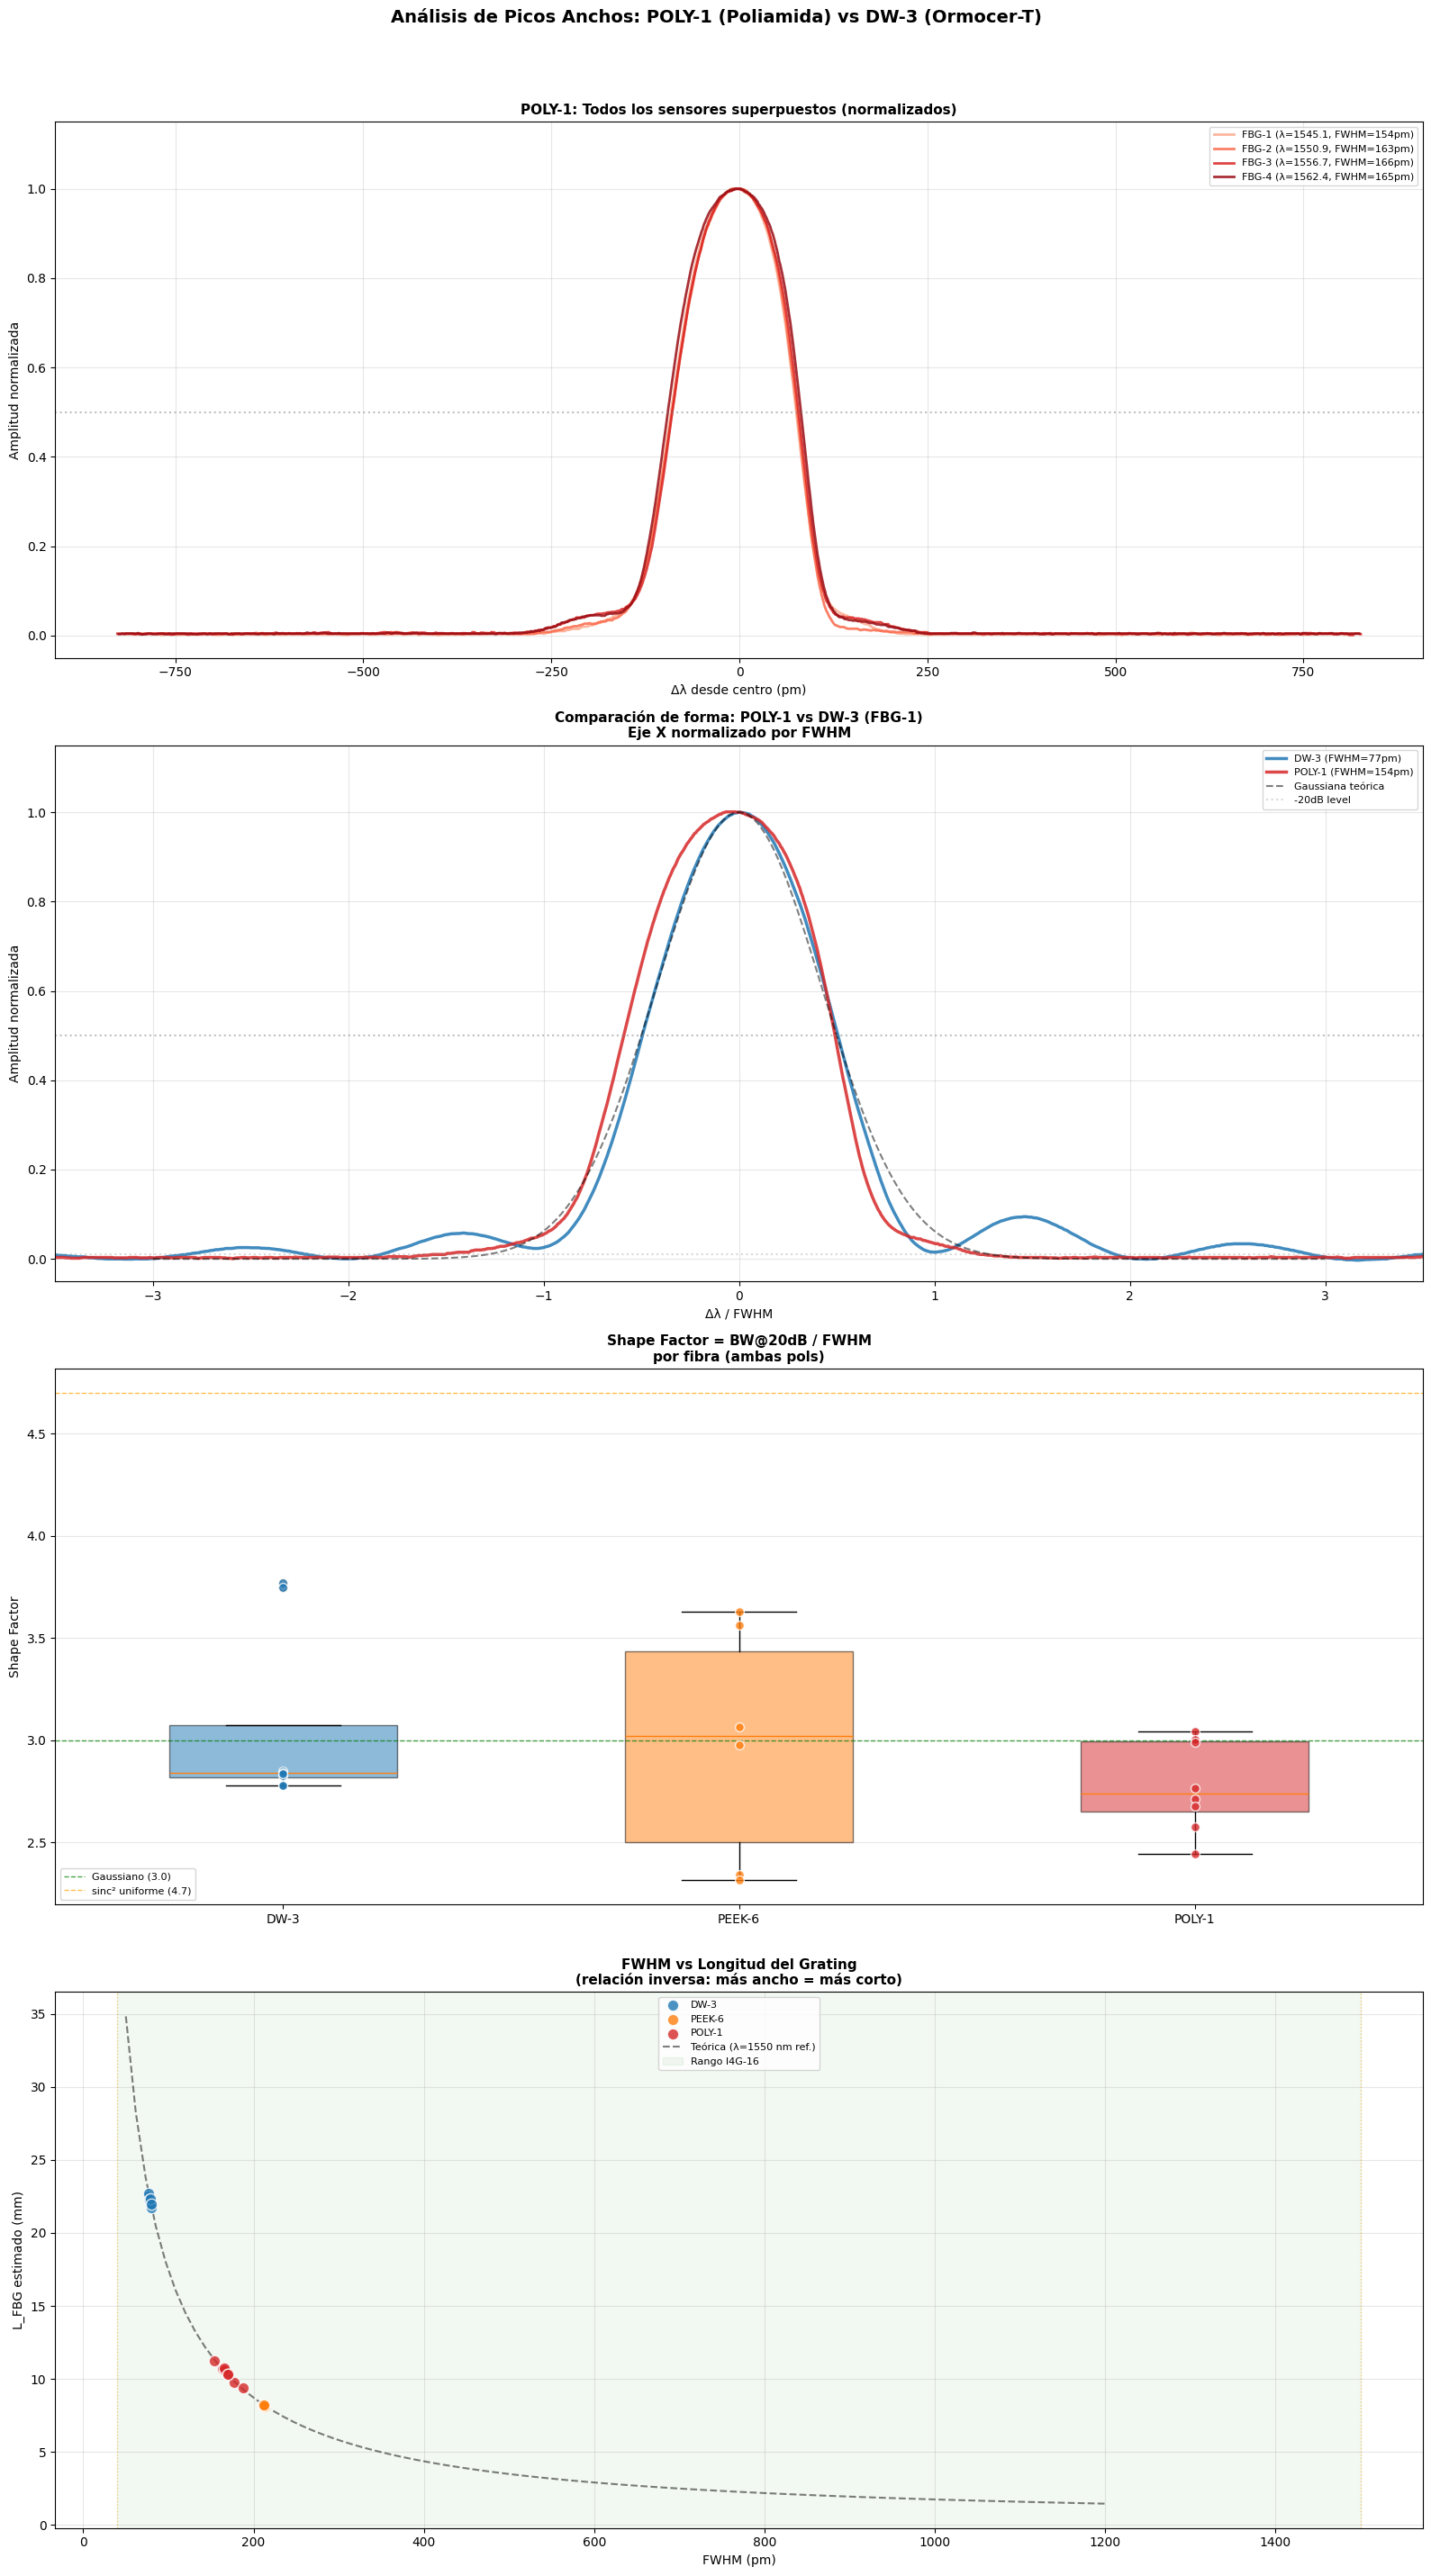

📊 DIAGNÓSTICO: ¿Por qué los picos de POLY-1 son más anchos?

  DW-3:
    FWHM medio: 78 ± 1 pm
    SF medio:   3.05 ± 0.41
    L_FBG medio: 22.23 ± 0.29 mm
  POLY-1:
    FWHM medio: 169 ± 9 pm
    SF medio:   2.78 ± 0.20
    L_FBG medio: 10.38 ± 0.54 mm

  🔎 SF(POLY-1) = 2.78 vs SF(DW-3) = 3.05
     → POLY-1 tiene perfil cercano a Gaussiano → probable grating CORTO
     → El ensanchamiento es por longitud reducida, NO por chirp

  💡 CAUSAS PROBABLES del ensanchamiento en POLY-1:
     1. Grating más corto (L estimado menor → FWHM mayor)
     2. El coating de poliamida puede inducir strain no uniforme
     3. A T_amb, posible compresión del coating sobre el grating
     4. El 5º sensor fuera de rango sugiere diseño con λ altas → posible
        tensión residual del coating que desplace los picos


In [26]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Análisis de picos anchos: POLY-1 vs DW-3
    # ══════════════════════════════════════════════════════════════════════

    fig = plt.figure(figsize=(16, 28))

    # ── Panel 1: Todos los sensores de POLY-1 superpuestos ────────────
    ax1 = fig.add_subplot(4, 1, 1)

    ch_poly = list(channel_names.values()).index('POLY-1')
    sig_poly_p = spectrum_wav[idx_espectro, 0, ch_poly, :]
    sig_poly_s = spectrum_wav[idx_espectro, 1, ch_poly, :]
    sig_poly = (sig_poly_p + sig_poly_s) / 2.0

    peaks_poly = fbg_analysis_results.get('POLY-1', {}).get('Pol P', [])
    valid_poly = [p for p in peaks_poly
                  if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

    poly_colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(valid_poly)))

    for i, peak in enumerate(valid_poly):
        pidx = peak['peak_idx']
        fwhm = peak['fwhm']
        lam_b = idx_to_wavelength(pidx)
        zoom = int(fwhm * 5)
        x0 = max(0, pidx - zoom)
        x1 = min(n_puntos, pidx + zoom)

        x_pm = (np.arange(x0, x1) - pidx) * dlam_nm_per_pt * 1e3
        y_norm = sig_poly[x0:x1] / sig_poly[pidx]

        fwhm_pm = fwhm * dlam_nm_per_pt * 1e3
        ax1.plot(x_pm, y_norm, color=poly_colors[i], linewidth=2, alpha=0.85,
                 label=f'FBG-{i+1} (λ={lam_b:.1f}, FWHM={fwhm_pm:.0f}pm)')

    ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax1.set_title('POLY-1: Todos los sensores superpuestos (normalizados)',
                  fontsize=11, fontweight='bold')
    ax1.set_xlabel('Δλ desde centro (pm)', fontsize=10)
    ax1.set_ylabel('Amplitud normalizada', fontsize=10)
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-0.05, 1.15)

    # ── Panel 2: POLY-1 FBG-1 vs DW-3 FBG-1 (forma del pico) ────────
    ax2 = fig.add_subplot(4, 1, 2)

    ch_dw = list(channel_names.values()).index('DW-3')
    sig_dw = (spectrum_wav[idx_espectro, 0, ch_dw, :] +
              spectrum_wav[idx_espectro, 1, ch_dw, :]) / 2.0

    peaks_dw = fbg_analysis_results.get('DW-3', {}).get('Pol P', [])
    valid_dw = [p for p in peaks_dw
                if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

    for fiber_name, signal, valid_peaks, color in [
        ('DW-3', sig_dw, valid_dw, 'tab:blue'),
        ('POLY-1', sig_poly, valid_poly, 'tab:red')
    ]:
        if len(valid_peaks) == 0:
            continue
        peak = valid_peaks[0]
        pidx = peak['peak_idx']
        fwhm = peak['fwhm']
        fwhm_pm = fwhm * dlam_nm_per_pt * 1e3
        zoom = int(fwhm * 5)
        x0 = max(0, pidx - zoom)
        x1 = min(n_puntos, pidx + zoom)

        # Eje normalizado por FWHM (x en unidades de FWHM)
        x_fwhm = (np.arange(x0, x1) - pidx) / fwhm
        y_norm = signal[x0:x1] / signal[pidx]

        ax2.plot(x_fwhm, y_norm, color=color, linewidth=2.5, alpha=0.85,
                 label=f'{fiber_name} (FWHM={fwhm_pm:.0f}pm)')

    # Referencia Gaussiana teórica
    x_gauss = np.linspace(-3, 3, 500)
    y_gauss = np.exp(-4 * np.log(2) * x_gauss**2)
    ax2.plot(x_gauss, y_gauss, 'k--', linewidth=1.5, alpha=0.5, label='Gaussiana teórica')

    ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax2.axhline(0.01, color='gray', linestyle=':', alpha=0.3, label='-20dB level')
    ax2.set_title('Comparación de forma: POLY-1 vs DW-3 (FBG-1)\nEje X normalizado por FWHM',
                  fontsize=11, fontweight='bold')
    ax2.set_xlabel('Δλ / FWHM', fontsize=10)
    ax2.set_ylabel('Amplitud normalizada', fontsize=10)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.05, 1.15)
    ax2.set_xlim(-3.5, 3.5)

    # ── Panel 3: Shape Factor comparison ──────────────────────────────
    ax3 = fig.add_subplot(4, 1, 3)

    sf_data = {}
    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        sfs = []
        for key, r in quality_results[fiber_name].items():
            sf_val = r.get('shape_factor', np.nan)
            if not np.isnan(sf_val):
                sfs.append(sf_val)
        if sfs:
            sf_data[fiber_name] = sfs

    if sf_data:
        positions = []
        box_data = []
        box_colors = []
        for i, (fn, sfs) in enumerate(sf_data.items()):
            positions.append(i)
            box_data.append(sfs)
            box_colors.append(colors_fiber[fn])

        bp = ax3.boxplot(box_data, positions=positions, widths=0.5, patch_artist=True)
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)

        # Scatter individual points
        for i, (fn, sfs) in enumerate(sf_data.items()):
            ax3.scatter([i] * len(sfs), sfs, color=colors_fiber[fn],
                       s=50, zorder=5, alpha=0.8, edgecolor='white')

        # Reference lines
        ax3.axhline(3.0, color='green', linestyle='--', linewidth=1, alpha=0.7,
                    label='Gaussiano (3.0)')
        ax3.axhline(4.7, color='orange', linestyle='--', linewidth=1, alpha=0.7,
                    label='sinc² uniforme (4.7)')

        ax3.set_xticks(positions)
        ax3.set_xticklabels(list(sf_data.keys()), fontsize=10)
        ax3.set_title('Shape Factor = BW@20dB / FWHM\npor fibra (ambas pols)',
                      fontsize=11, fontweight='bold')
        ax3.set_ylabel('Shape Factor', fontsize=10)
        ax3.legend(fontsize=8)
        ax3.grid(True, axis='y', alpha=0.3)

    # ── Panel 4: FWHM vs Grating Length ───────────────────────────────
    ax4 = fig.add_subplot(4, 1, 4)

    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        fwhms = []
        lengths = []
        for key, r in quality_results[fiber_name].items():
            fw = r.get('bw_3db_pm', np.nan)
            ll = r.get('fbg_length_mm', np.nan)
            if not np.isnan(fw) and not np.isnan(ll):
                fwhms.append(fw)
                lengths.append(ll)
        if fwhms:
            ax4.scatter(fwhms, lengths, color=colors_fiber[fiber_name],
                       s=80, alpha=0.8, edgecolor='white', label=fiber_name, zorder=5)

    # Theoretical curve: L = (n_eff * lambda^2) / (2 * FWHM_nm * 1e6)
    # Nota: curva teórica usa lambda=1550 nm como referencia;
    # los puntos individuales usan la lambda_B real de cada sensor
    fwhm_theory = np.linspace(50, 1200, 100)
    L_theory = (1.45 * 1550**2) / (2 * fwhm_theory * 1e-3 * 1e6)
    ax4.plot(fwhm_theory, L_theory, 'k--', linewidth=1.5, alpha=0.5,
             label='Teórica (λ=1550 nm ref.)')

    # I4G-16 FWHM range
    ax4.axvline(40, color='orange', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axvline(1500, color='orange', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axvspan(40, 1500, alpha=0.05, color='green', label='Rango I4G-16')

    ax4.set_title('FWHM vs Longitud del Grating\n(relación inversa: más ancho = más corto)',
                  fontsize=11, fontweight='bold')
    ax4.set_xlabel('FWHM (pm)', fontsize=10)
    ax4.set_ylabel('L_FBG estimado (mm)', fontsize=10)
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Análisis de Picos Anchos: POLY-1 (Poliamida) vs DW-3 (Ormocer-T)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ── Diagnóstico textual ───────────────────────────────────────────
    print("📊 DIAGNÓSTICO: ¿Por qué los picos de POLY-1 son más anchos?")
    print()

    # Comparar métricas
    for fiber_name in ['DW-3', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        fwhms = [r['bw_3db_pm'] for r in quality_results[fiber_name].values()
                 if not np.isnan(r.get('bw_3db_pm', np.nan))]
        sfs = [r.get('shape_factor', np.nan) for r in quality_results[fiber_name].values()]
        sfs = [v for v in sfs if not np.isnan(v)]
        ls = [r['fbg_length_mm'] for r in quality_results[fiber_name].values()
              if not np.isnan(r['fbg_length_mm'])]

        print(f"  {fiber_name}:")
        print(f"    FWHM medio: {np.mean(fwhms):.0f} ± {np.std(fwhms):.0f} pm")
        print(f"    SF medio:   {np.mean(sfs):.2f} ± {np.std(sfs):.2f}" if sfs else "    SF: N/A")
        print(f"    L_FBG medio: {np.mean(ls):.2f} ± {np.std(ls):.2f} mm")

    print()
    if sf_data.get('POLY-1') and sf_data.get('DW-3'):
        sf_poly = np.mean(sf_data['POLY-1'])
        sf_dw = np.mean(sf_data['DW-3'])
        print(f"  🔎 SF(POLY-1) = {sf_poly:.2f} vs SF(DW-3) = {sf_dw:.2f}")
        if sf_poly < 3.5:
            print("     → POLY-1 tiene perfil cercano a Gaussiano → probable grating CORTO")
            print("     → El ensanchamiento es por longitud reducida, NO por chirp")
        elif sf_poly > 5.0:
            print("     → SF alto → indica CHIRP no intencionado")
            print("     → Posible gradiente de strain del coating de poliamida")
        else:
            print("     → SF intermedio → perfil entre Gaussiano y sinc²")
            print("     → Grating moderadamente largo, posible leve chirp del coating")

    print()
    print("  💡 CAUSAS PROBABLES del ensanchamiento en POLY-1:")
    print("     1. Grating más corto (L estimado menor → FWHM mayor)")
    print("     2. El coating de poliamida puede inducir strain no uniforme")
    print("     3. A T_amb, posible compresión del coating sobre el grating")

    print("     4. El 5º sensor fuera de rango sugiere diseño con λ altas → posible")
    print("        tensión residual del coating que desplace los picos")

## 9️⃣ Guardar Resultados

Exporta la tabla resumen a CSV para análisis posterior.

In [27]:
if data_spectrum is not None and 'df_summary' in locals():
    output_csv = "/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/FBG_quality_summary_20260304.csv"
    df_summary.to_csv(output_csv, index=False)
    print(f"✅ Tabla resumen guardada en: {output_csv}")
    print(f"   Columnas: {', '.join(df_summary.columns)}")
    print(f"   Filas: {len(df_summary)}")

    # También guardar cross-pol si existe
    if 'df_xpol' in locals():
        xp_csv = output_csv.replace('.csv', '_cross_pol.csv')
        df_xpol.to_csv(xp_csv, index=False)
        print(f"✅ Cross-polarización guardada en: {xp_csv}")

✅ Tabla resumen guardada en: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/FBG_quality_summary_20260304.csv
   Columnas: Fibra, FBG, Pol, peak_idx, lambda_B_nm, spacing_nm, FWHM_pm, BW20_pm, SF, Amp_cts, SNR_dB, SLSR_dB, SLSR_ratio, d_SL_nm, SAR_pct, SAR90_pct, SAR50_pct, L_mm
   Filas: 22
✅ Cross-polarización guardada en: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/FBG_quality_summary_20260304_cross_pol.csv
